# Experiments 42 - 43
### Excess Green: _Masking / PCA + BurnBlend_


### Dataset:
- **Dataset:** 3.5m | 90º
- **Sizes:** small & mid
- **Split:** 240 px
- **Tags:**  `plant-weed`
- **Train/Valid dist:** 66,6% / 33,3%

### Model:
- **Model:** `yolov8m` *(Medium)*
- **Epochs:** ~500
- **Batch:** 64
- **Freeze:** 10

### Experiments:
1. exGreen masked
1. 2 PCA + exGreen + BurnBlend
- **Reference:** Default YOLO augmentation *(w/Albumentations)*

In [1]:
# CONFIG FOLDER PATH

# Get the project root directory (replace with your actual path)
experiment_number = 1
project_root = "../" * 2

# The folder you want to navigate to (relative to the root)
target_folder = f"docs/Experimentos/8 exGreen/{experiment_number} set/runs/detect/"

### Init

In [2]:
scale: int = 500 # size for graphs (in pixels)

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

In [4]:
def update_project_root(path = ''):
    global project_root
    if not path:
        path = os.getcwd()
    folder_depth = len([i for i in path.split("/") if i != ''])
    project_root = "../" * folder_depth

In [5]:
def change_directory(target_folder):
    """
    Change the current working directory to the target folder.
    Args:
        target_folder (str): The target folder path relative to the project root.
    """ 
    global project_root
    # Construct the full path
    target_path = os.path.join(project_root, target_folder)

    # Change the current working directory
    try:
        os.chdir(target_path)
        print(f"Current working directory: {os.getcwd()}")  # Verify

        folder_depth = len([i for i in target_folder.split("/") if i != ''])
        project_root = "../" * folder_depth
        print(f"Project root updated to: {project_root}")  # Verify

    except FileNotFoundError:
        print(f"Error: Folder '{target_path}' not found. Check the path.")
    except NotADirectoryError:
        print(f"Error: '{target_path}' is not a directory.")
    except Exception as e:
        print(f"An error occurred: {e}")

In [6]:
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/8 exGreen/1 set/runs/detect
Project root updated to: ../../../../../../


In [7]:
# Reset to the root path
# os.chdir(project_root)
# print(f"Current working directory: {os.getcwd()}") #Verify

In [8]:
best_models = pd.DataFrame(
    columns=['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2', 'train_time'],
       data = None
       )

#### Functions

In [9]:
def graph_training_metrics(df: pd.DataFrame, epoch: np.int64, graph: str="tight"):
    """
    Plots training and validation metrics from a training log DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing training metrics, including columns
                           'epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                           'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
                           'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                           'metrics/mAP50-95(B)', and optionally 'lr/pg0' for the 'lr' graph.
        graph (str, optional): Type of graph to display. Options are:
            - "tight": Displays loss and metrics in a single row.
            - "full": Displays loss and metrics in two rows.
            - "lr": Displays loss, metrics, and learning rate in three rows.
            Defaults to "tight".

    Raises:
        ValueError: If the 'graph' parameter is not one of "tight", "full", or "lr".
    """
    graph = graph.lower()

    # Tight view (one row)
    if graph == "tight":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 6))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(1, 2, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

        # Graficar métricas de validación
        plt.subplot(1, 2, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X


    # Full view (two rows)
    elif graph == "full":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 12))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(2, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

        # Graficar métricas de validación
        plt.subplot(2, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X

    # Shows also Lr graph (three rows)
    elif graph == "lr":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 15))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(3, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

        # Graficar métricas de validación
        plt.subplot(3, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X

        # Gráfico de evolución del learning rate
        plt.subplot(3, 1, 3)
        plt.plot(df["epoch"], df["lr/pg0"], label="Learning Rate (pg0)", color="cadetblue", marker='.', linestyle='-')
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("Learning Rate Evolution")
        plt.grid(True)

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

    else:
        raise ValueError(f"Invalid graph parameter: '{graph}'. Must be one of 'tight', 'full', or 'lr'.")

    plt.tight_layout()
    plt.show()

In [10]:
def graph_LrLoss(df):
    """Generates a 3D plot of Learning Rate vs. Loss vs. Epoch."""

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Data
    epochs = df['epoch']
    losses = df['val/cls_loss']  # or df['train/cls_loss'], or combined as needed.
    lrs = df['lr/pg0']

    # Scatter plot
    ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis', marker='o')

    # Labels
    ax.set_xlabel('Learning Rate (lr/pg0)')
    ax.set_ylabel('Classification Loss (val/cls_loss)')
    ax.set_zlabel('Epoch')
    ax.set_title('3D Plot: Learning Rate vs. Loss vs. Epoch')

    # Color bar
    fig.colorbar(ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis'), label='Loss Value')

    plt.show()

In [11]:
def graph_LrLoss_3D(df, set: str='val'):
    """Generates an interactive 3D plot of Learning Rate vs. Loss vs. Epoch."""

    if set.lower() == 'val':
        print("Validation set")
        loss_set = 'val/cls_loss'
        title_set = 'Validation'
    elif set.lower() == 'train':
        print("Training set")
        loss_set = 'train/cls_loss'
        title_set = 'Train'
    else:
        print("Debe indicarse el set de entrenamiento: set debe ser igual 'val' o 'train'")
        return  

    fig = go.Figure(data=[go.Scatter3d(
        x=df['lr/pg0'],
        y=df[loss_set],
        z=df['epoch'],
        mode='markers',
        marker=dict(
            size=5,
            color=df[loss_set], # color based on loss value
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title='Loss Value')  # Add colorbar
        )
    )])

    fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=0),
        scene=dict(
            xaxis=dict(title='Learning Rate (lr/pg0)'),
            yaxis=dict(title=f'Classification Loss ({loss_set})'),
            zaxis=dict(title='Epoch'),
        ),
        title=f'Learning Rate vs. {title_set} Loss vs. Epoch'
    )

    fig.show()

----

# Experimentos

## Experiment 42
### *YOLOv8 Mid | exGreen masked images*
Images created by applying exGreen mask

In [12]:
folder = "train/"

In [13]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df1 = pd.read_csv(file_path)
df = df1.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
495,496,3676.77,1.31495,0.87788,1.17994,0.42951,0.32972,0.28148,0.07456,2.85499,1.59474,2.02232,0.000040,0.000040,0.000040
496,497,3683.95,1.25421,0.78826,1.14751,0.43930,0.32794,0.27890,0.07439,2.85892,1.59499,2.03044,0.000036,0.000036,0.000036
497,498,3690.87,1.21434,0.76537,1.11140,0.43709,0.32669,0.27692,0.07385,2.86392,1.59955,2.03596,0.000032,0.000032,0.000032
498,499,3698.09,1.31397,0.80350,1.17075,0.42931,0.32503,0.27524,0.07346,2.87043,1.60492,2.03819,0.000028,0.000028,0.000028
499,500,3704.97,1.31067,0.86389,1.21345,0.42797,0.32628,0.27380,0.07315,2.87260,1.60697,2.04185,0.000024,0.000024,0.000024


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [14]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 61.749 min


#### Best epoch

In [15]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
60,61,456.64,2.45698,1.89124,1.77849,0.41957,0.40722,0.35821,0.10947,2.38044,1.66311,1.55345,0.001762,0.001762,0.001762,61.7495


In [16]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 61 con mAP50 de 0.358


In [17]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [18]:
TP = 1034
FP = 945
FN = 1375
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 3354


In [19]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.308288610614192, 0.2817531305903399, 0.4099582587954681)

### Graphs

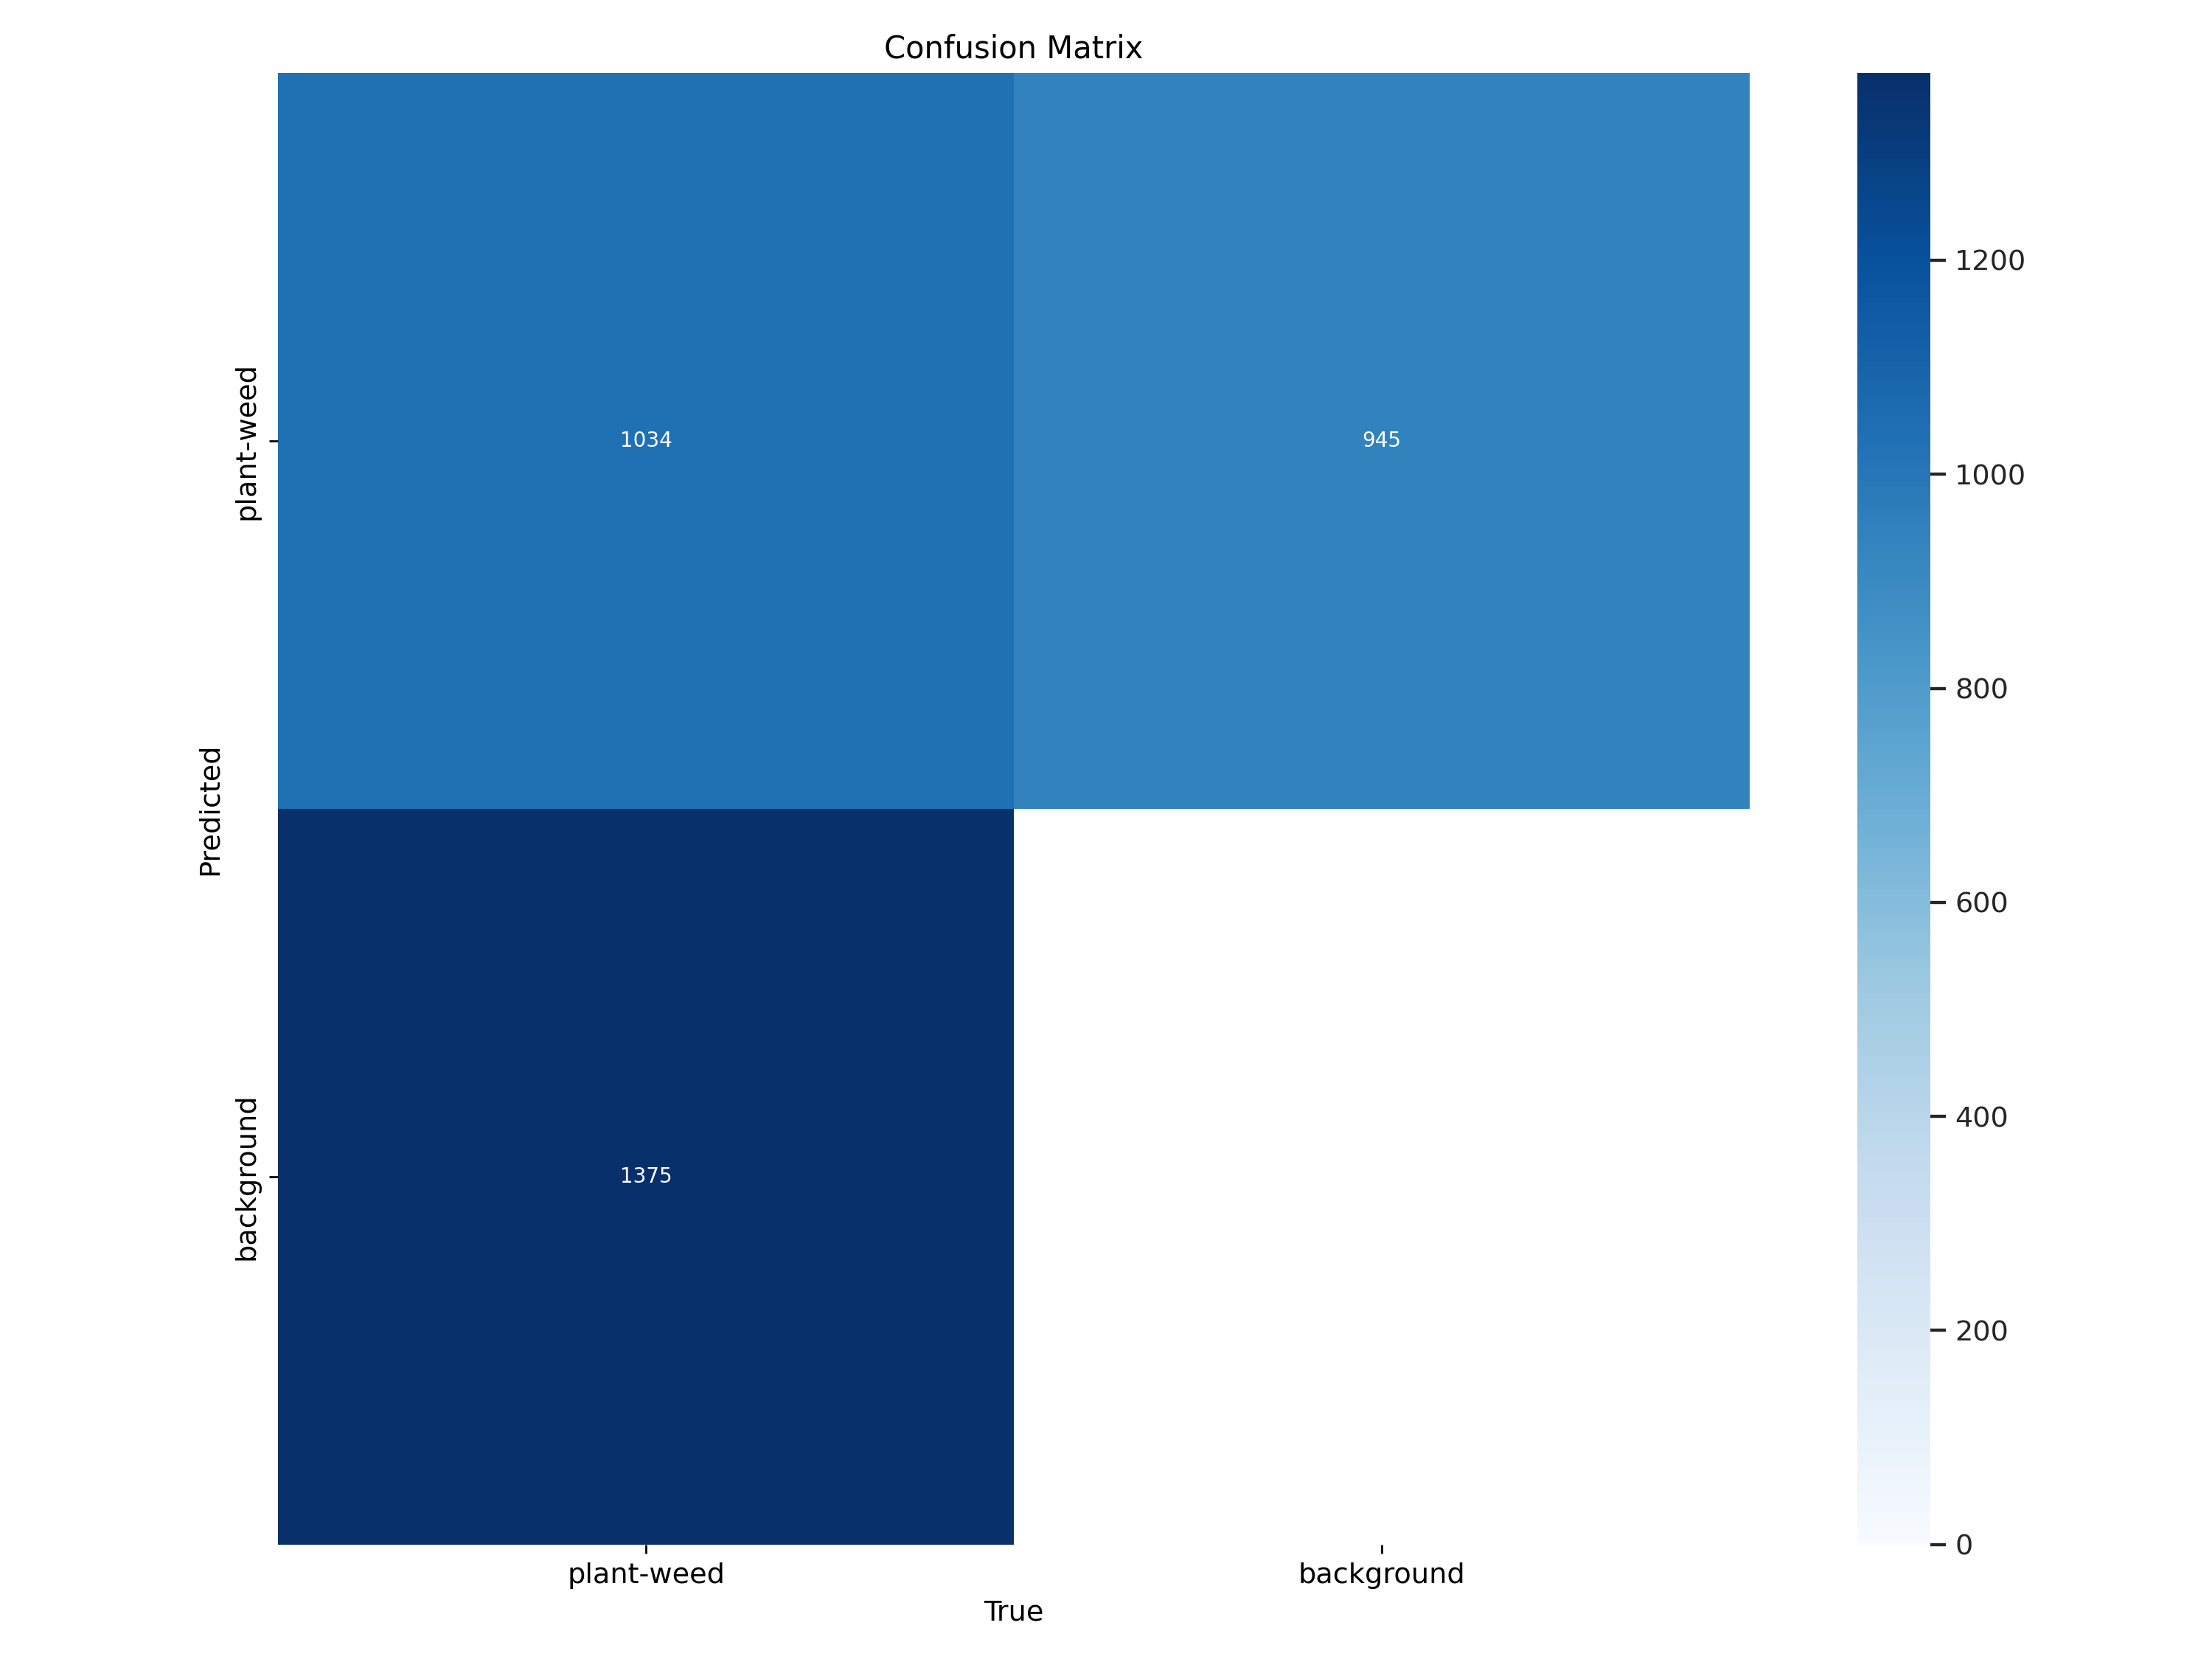

In [20]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

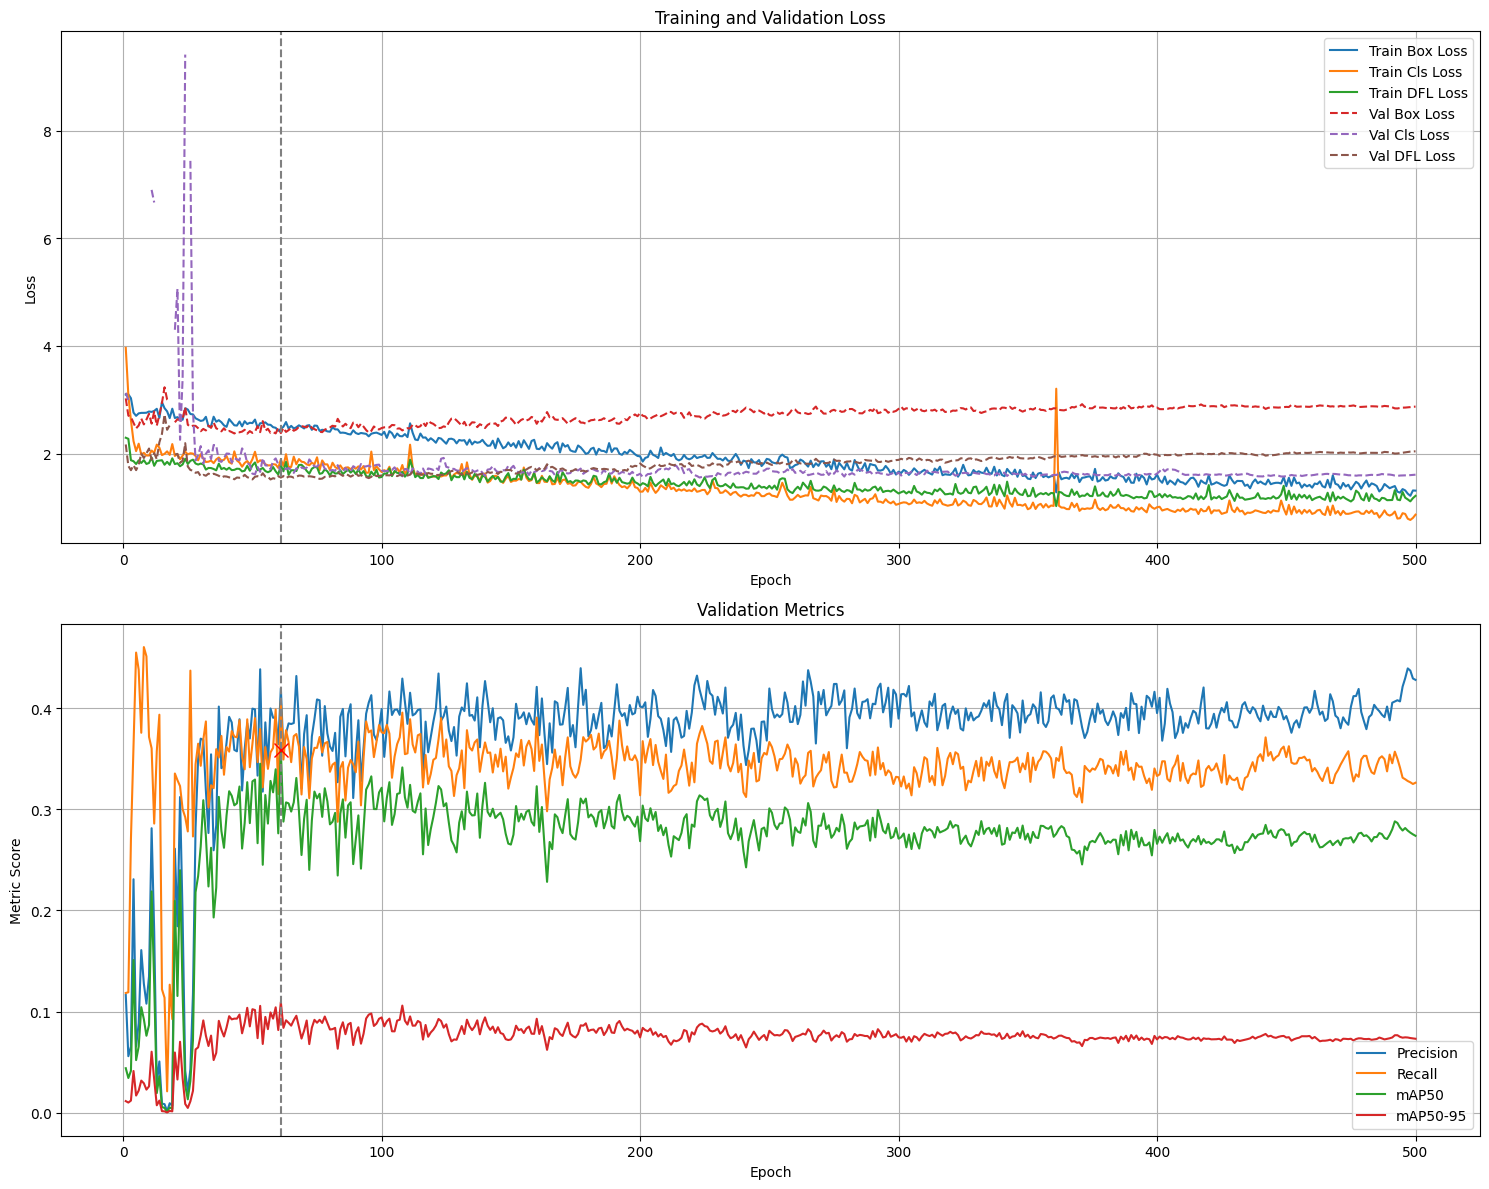

In [21]:
graph_training_metrics(df, epoch, graph="full")

In [22]:
graph_LrLoss_3D(df)

Validation set


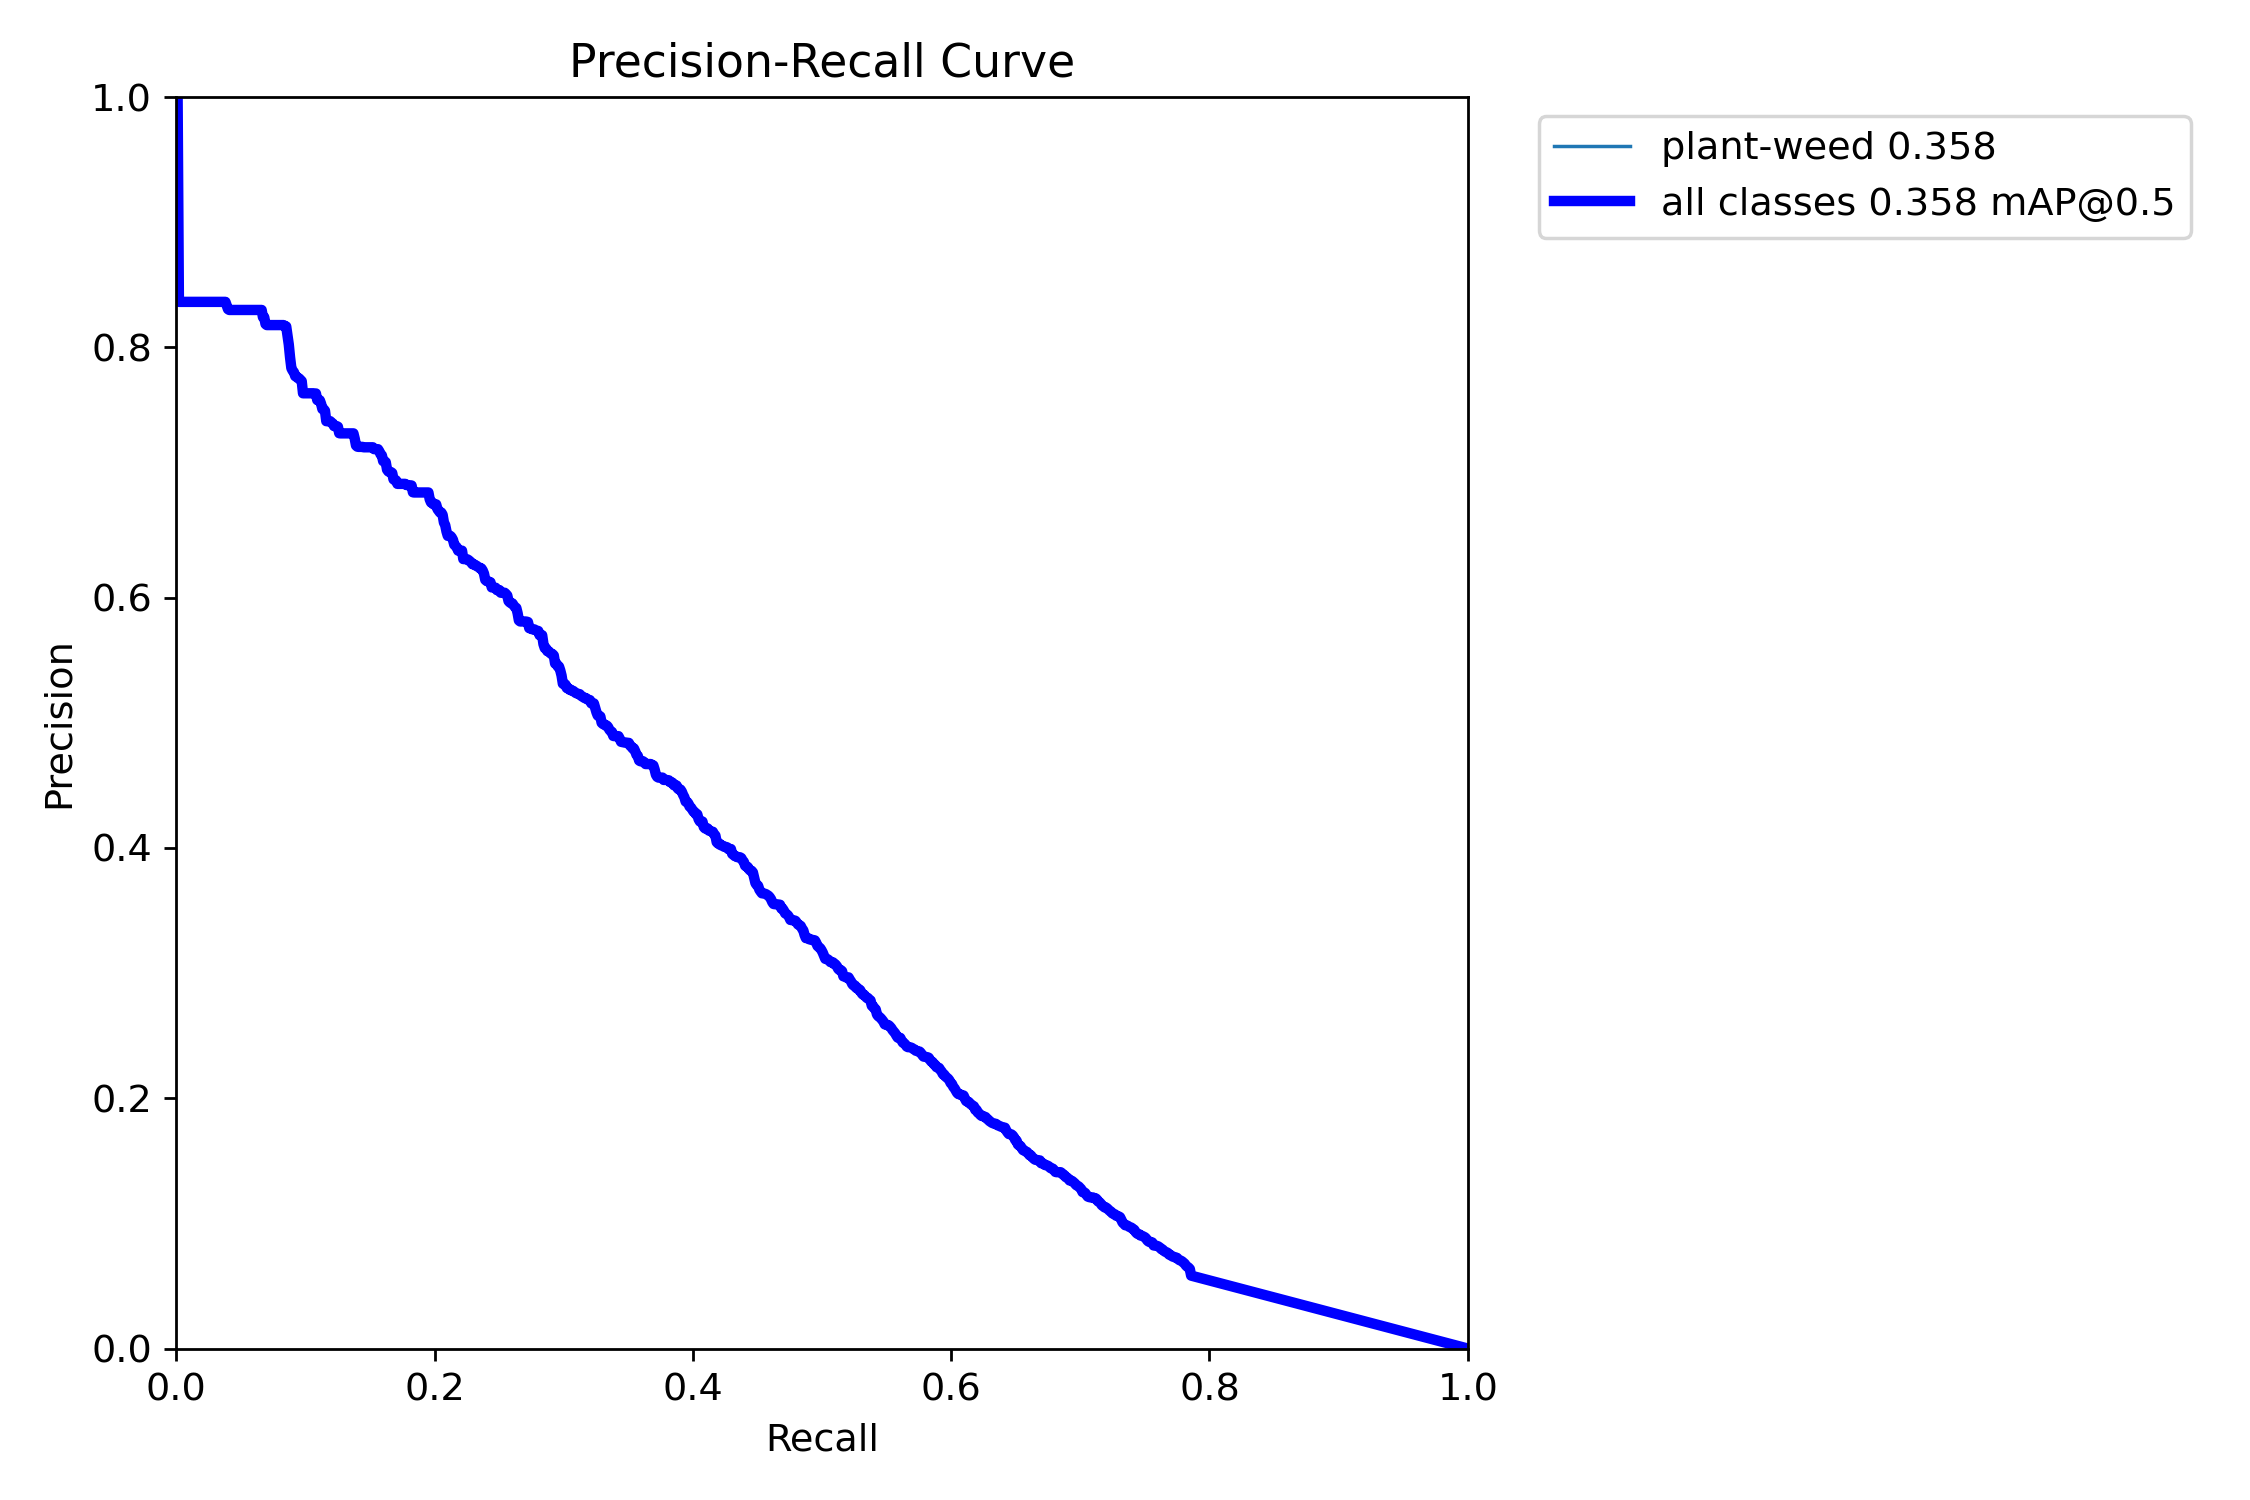

In [23]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

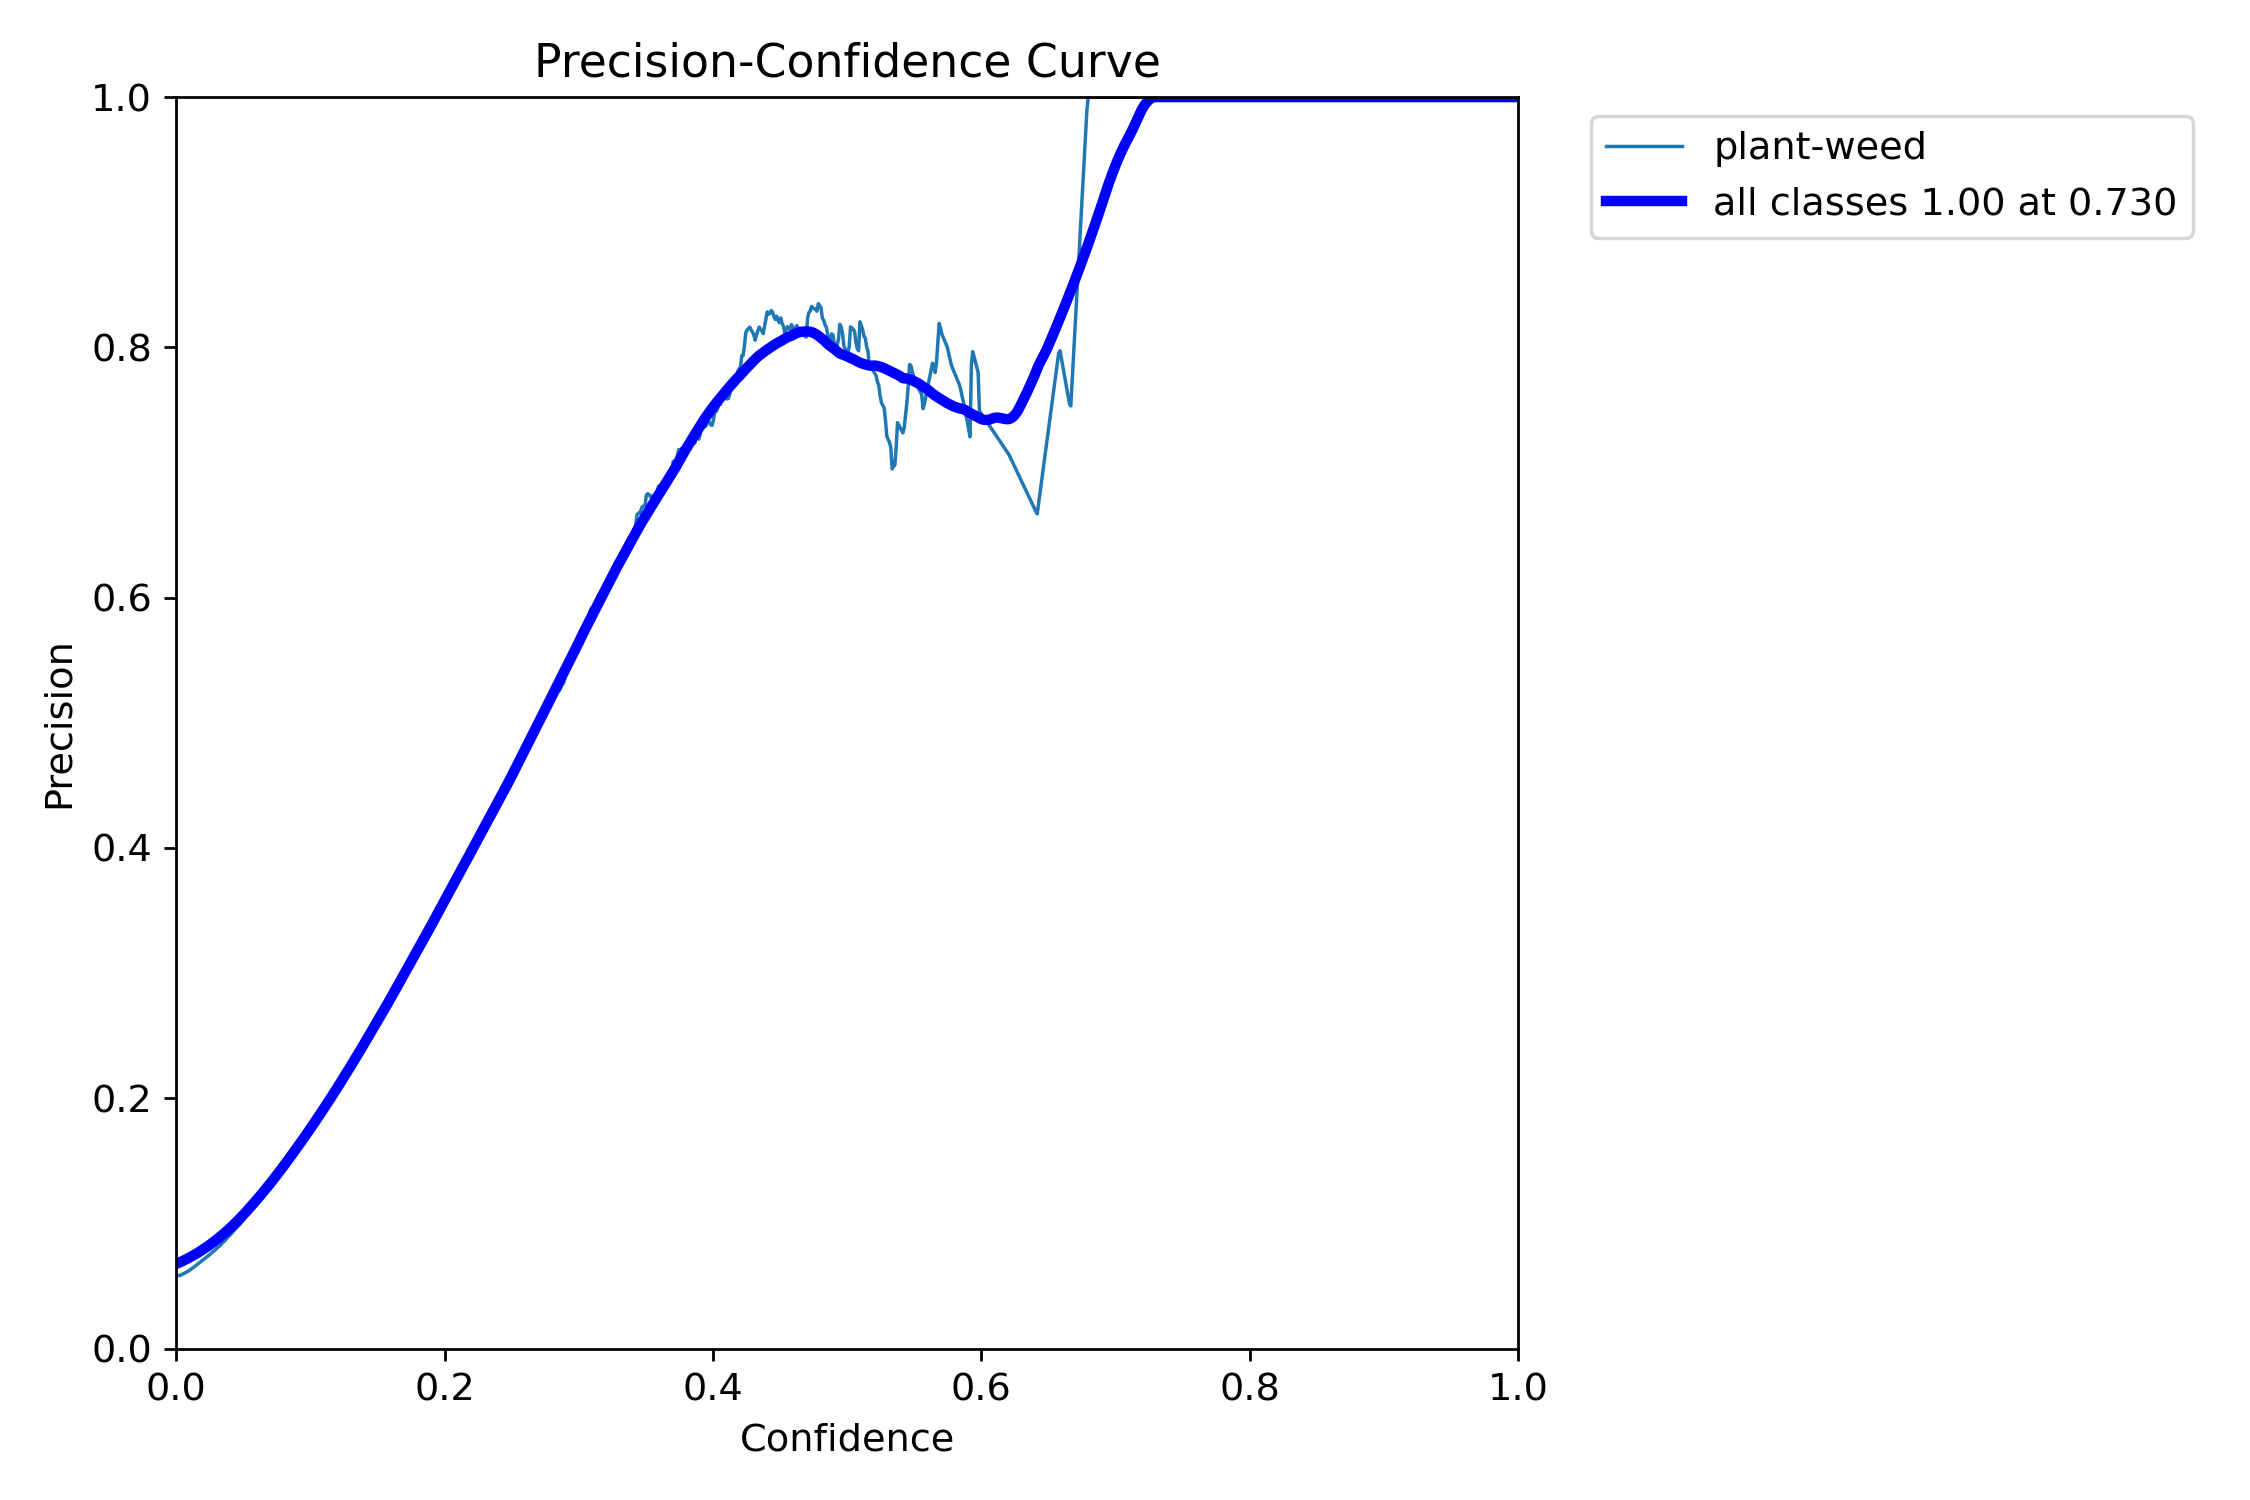

In [24]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

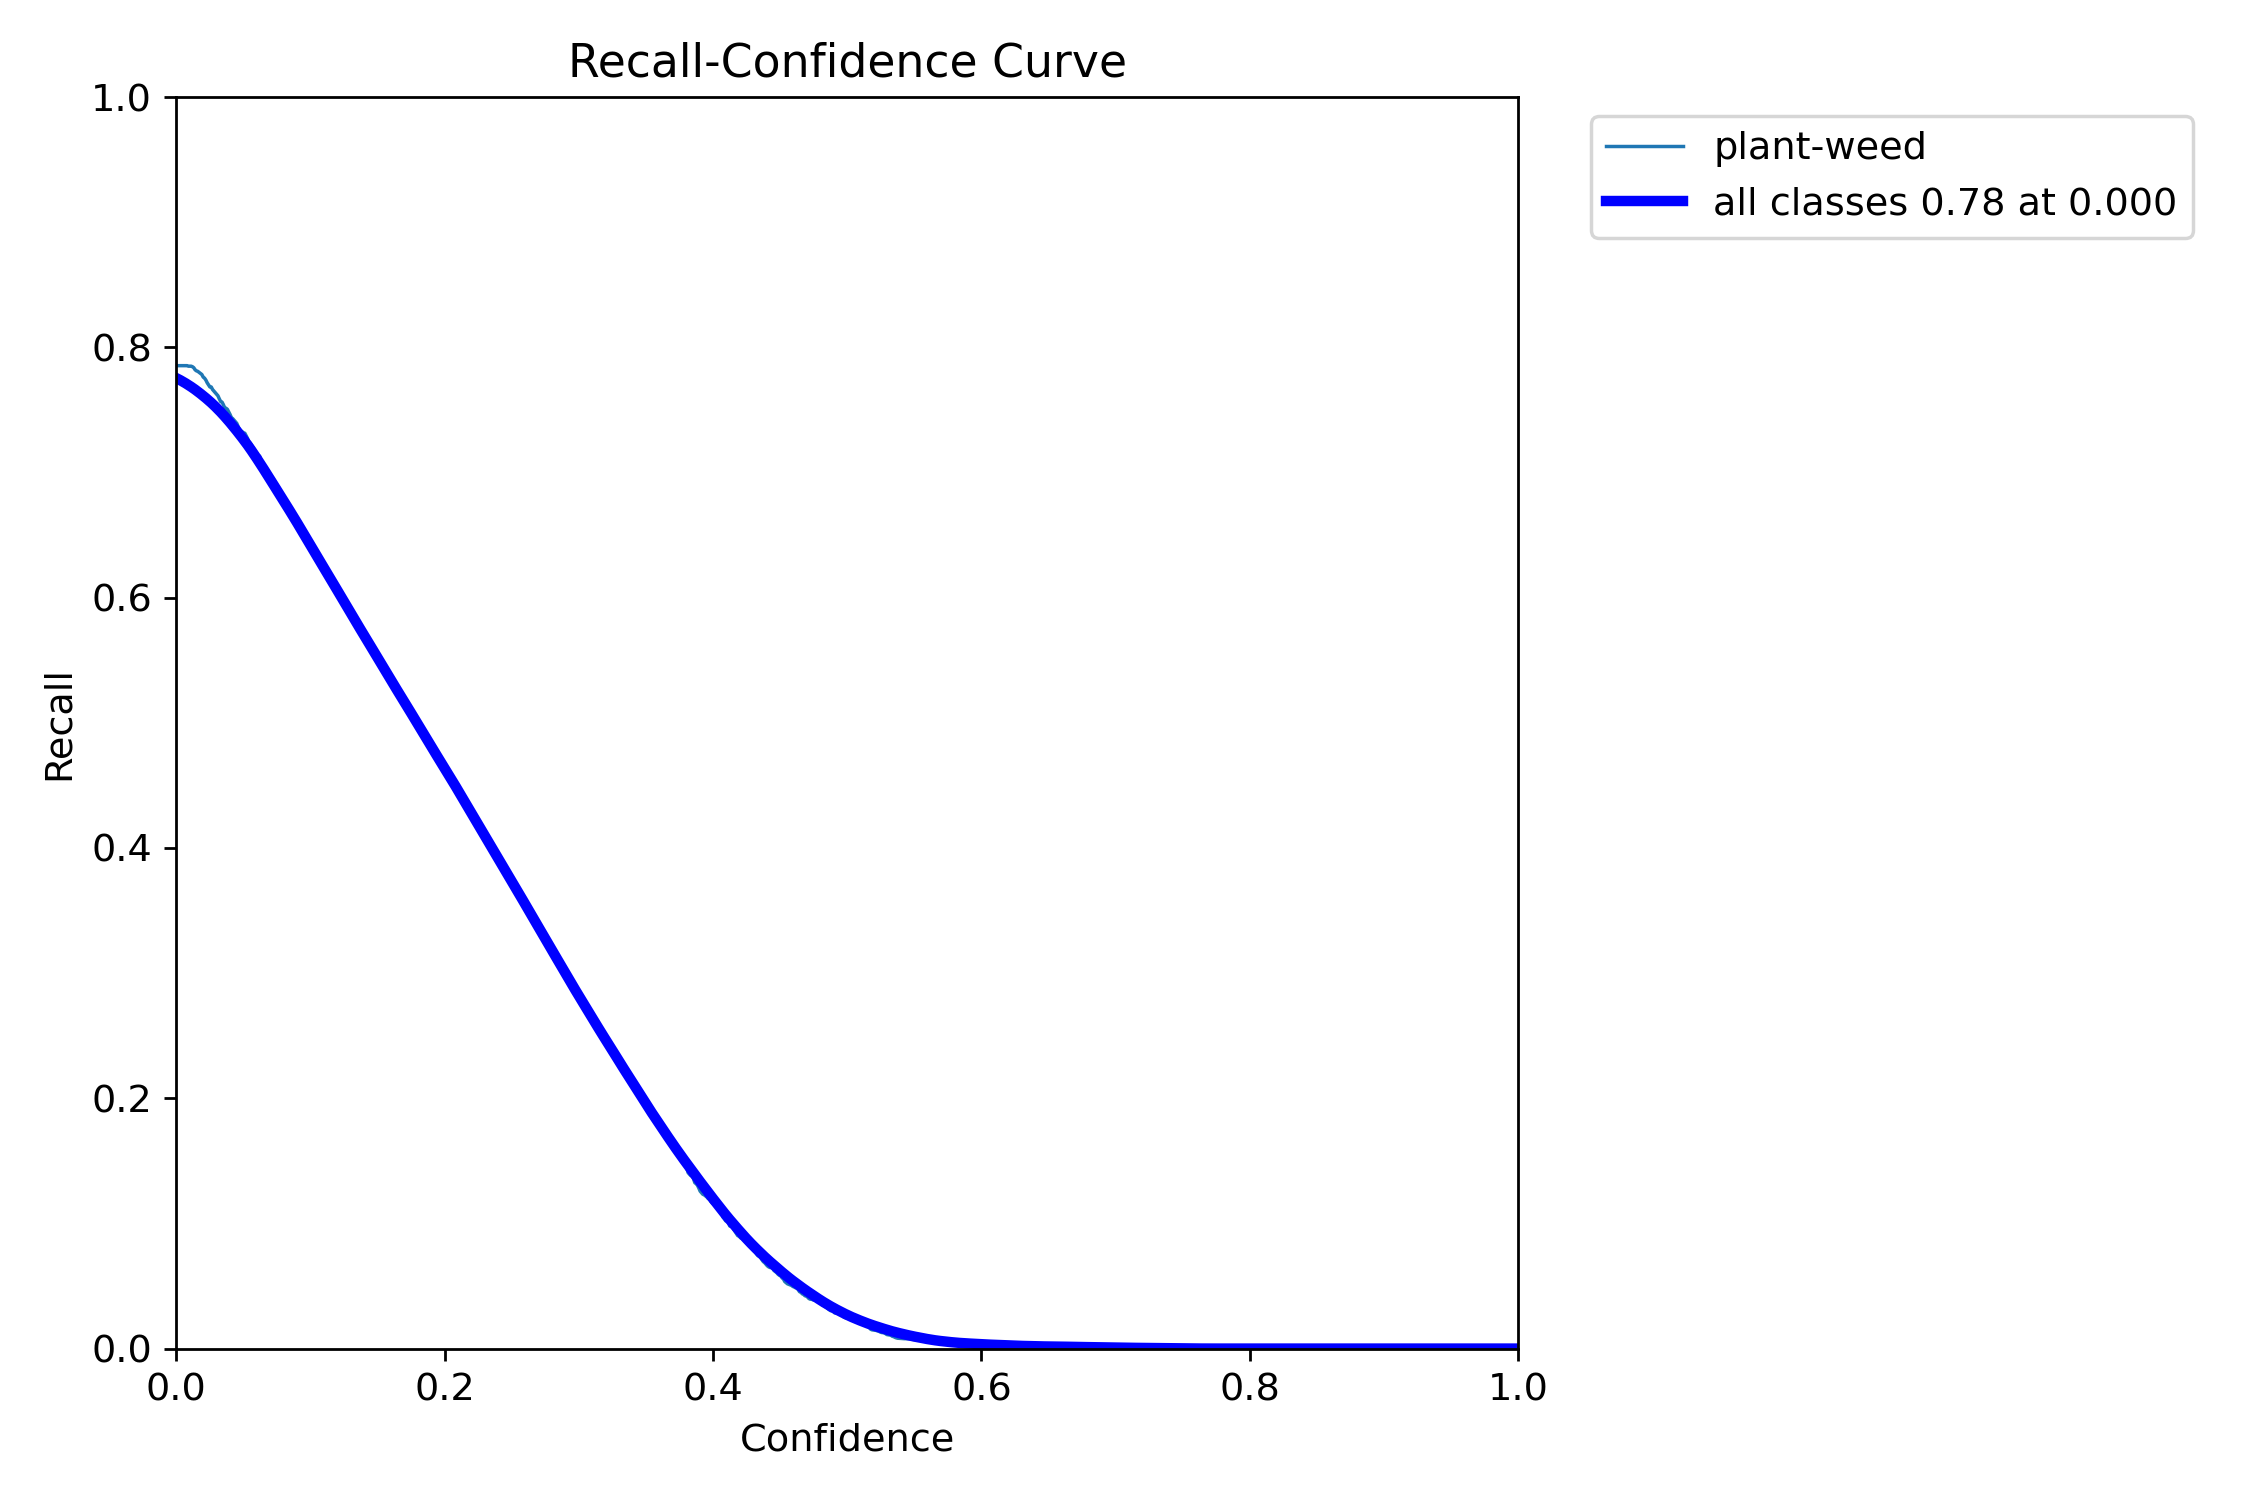

In [25]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

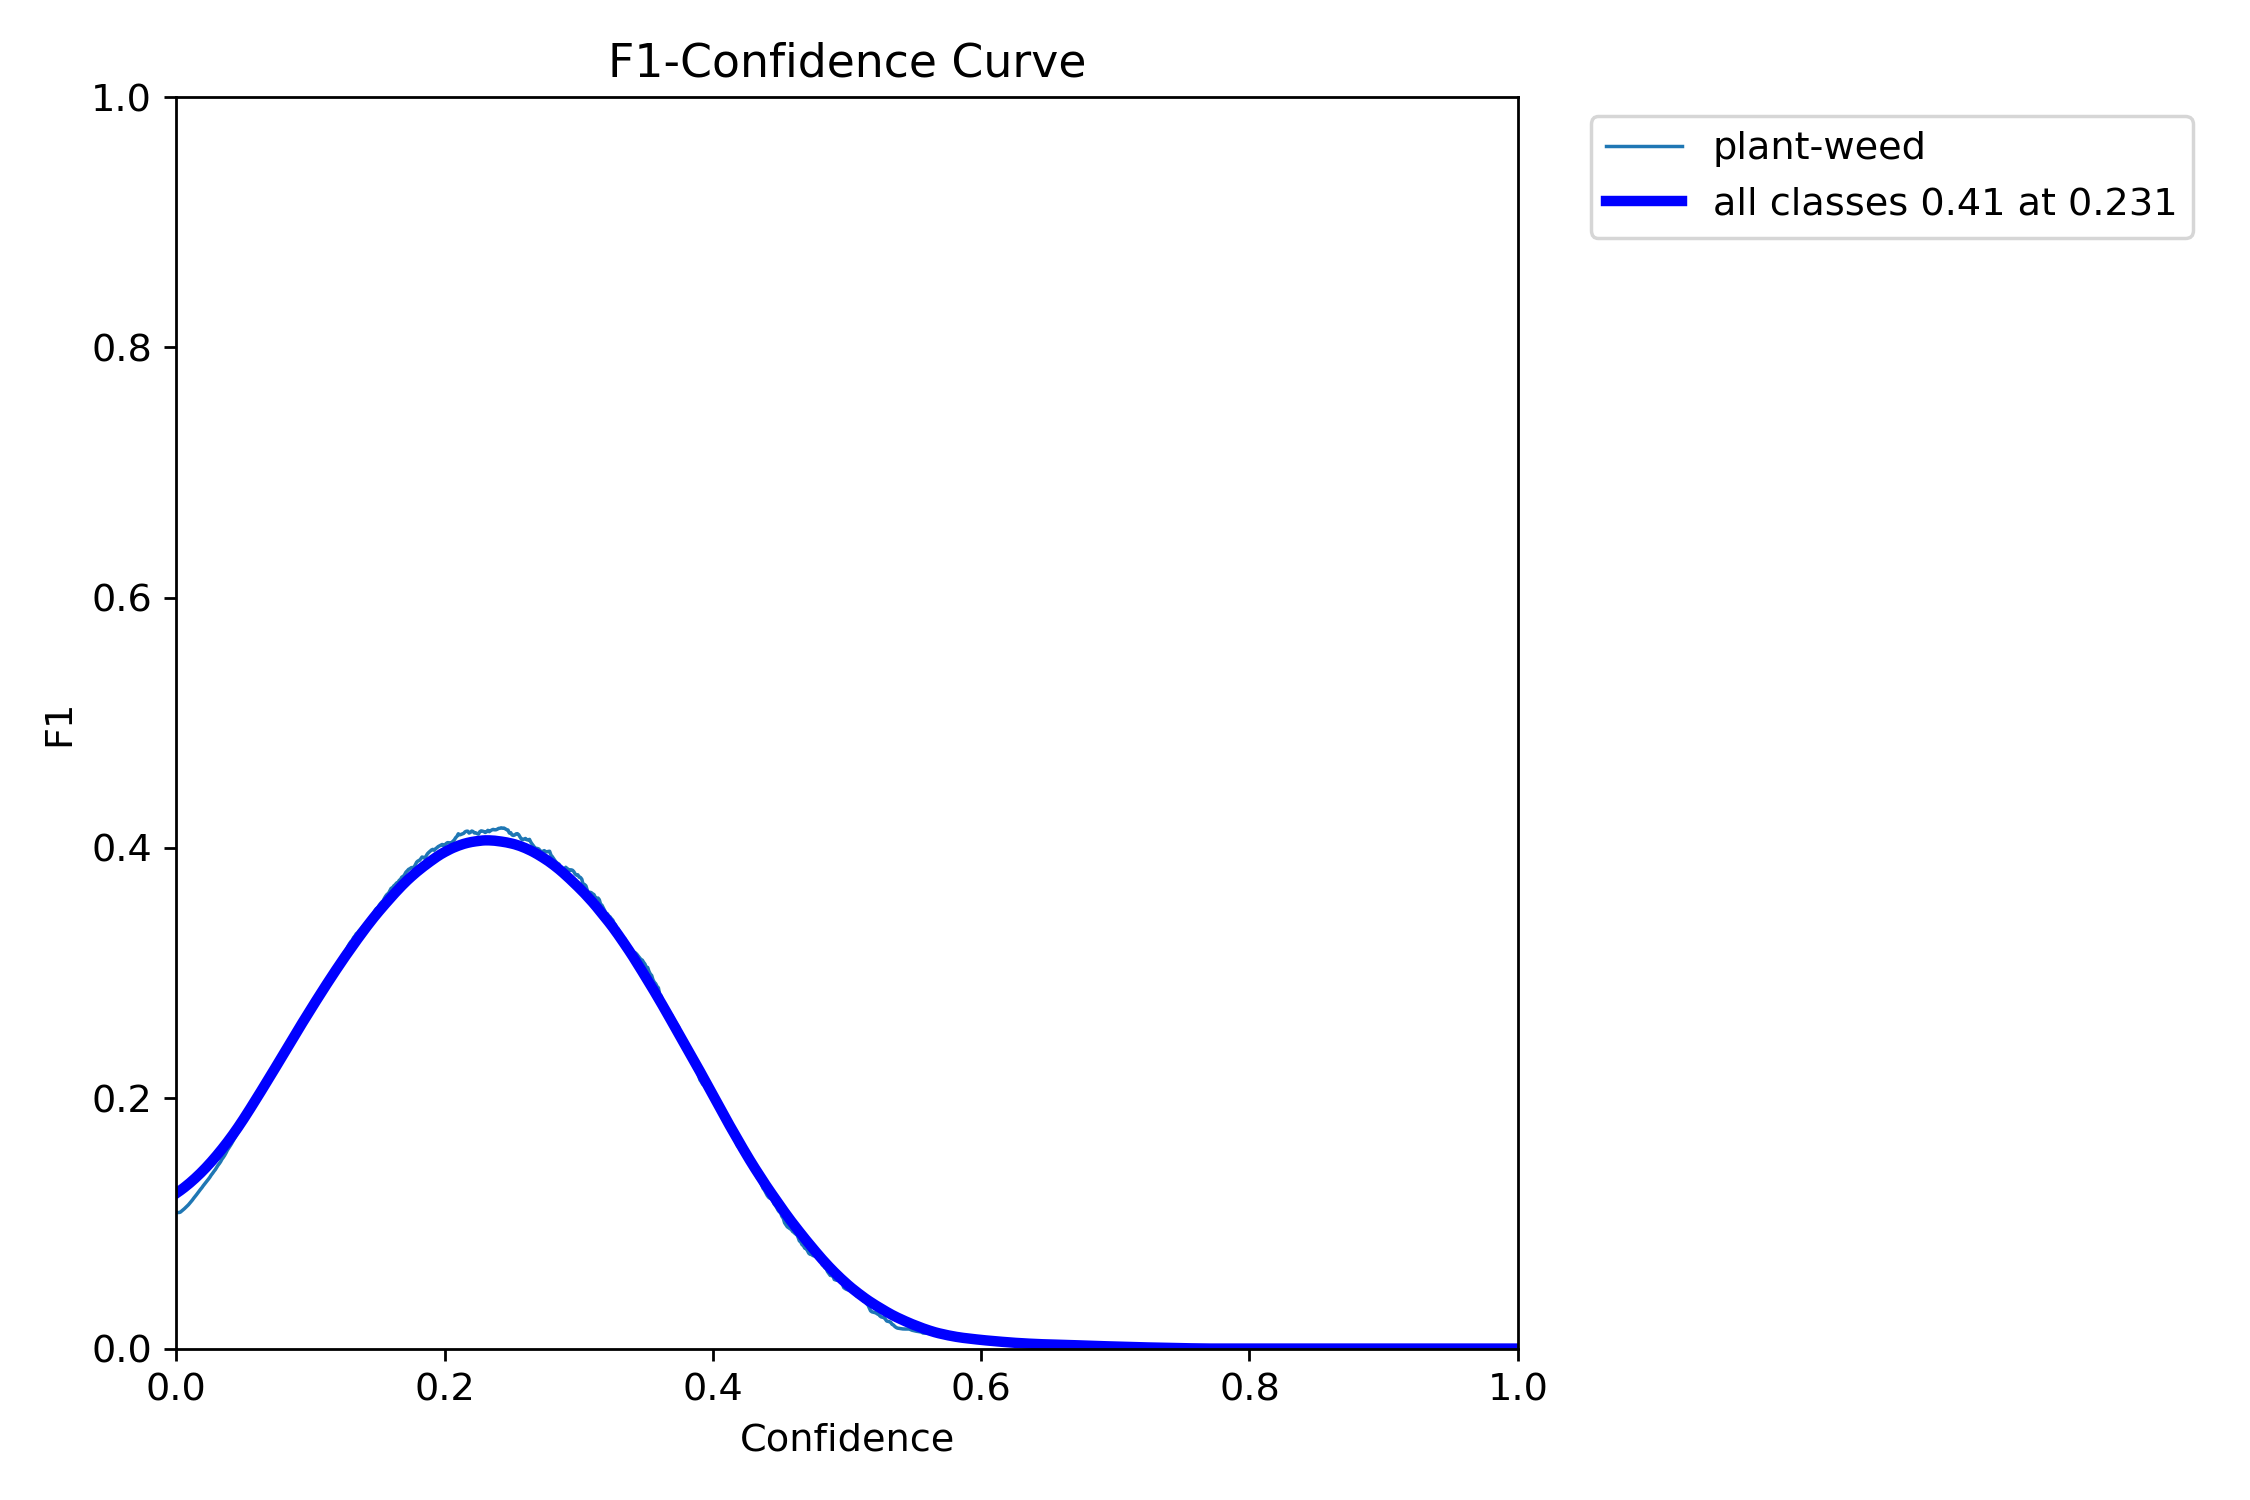

In [26]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

El valor de confianza que optimiza la precisión y recall es 0.231. En la mayoría de los casos, una mayor confianza es deseable.

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

## Experiment 43
### *YOLOv8 Mid | False color images*
False color images are created by applying:
1. Excess Green to a grayscale image.
1. A 2-component PCA (to reduce dimensionality).
1. Combining these images as RGB channels.
1. Applying a Burn Blend between the resulting image and the original.

In [27]:
folder = "train2/"

In [28]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df2 = pd.read_csv(file_path)
df = df2.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
495,496,3592.31,0.91752,0.50961,0.96853,0.53225,0.45039,0.40824,0.13097,2.53027,1.48107,1.87429,0.000040,0.000040,0.000040
496,497,3600.03,0.86566,0.49453,0.94233,0.53102,0.45330,0.40904,0.13063,2.53219,1.48580,1.87544,0.000036,0.000036,0.000036
497,498,3606.66,0.85317,0.48329,0.92920,0.52783,0.45477,0.40810,0.13087,2.53106,1.48297,1.87517,0.000032,0.000032,0.000032
498,499,3614.24,0.95018,0.51381,0.98645,0.52978,0.45621,0.41045,0.13101,2.53141,1.48606,1.87813,0.000028,0.000028,0.000028
499,500,3620.90,0.97067,0.55663,1.02539,0.52760,0.45496,0.40874,0.13100,2.53102,1.49032,1.87983,0.000024,0.000024,0.000024


In [29]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 60.348 min


In [30]:
df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
53,54,398.282,1.99676,1.25836,1.45897,0.51745,0.47406,0.44565,0.14513,2.32588,1.75765,1.53881,0.00179,0.00179,0.00179


#### Best epoch

In [31]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
53,54,398.282,1.99676,1.25836,1.45897,0.51745,0.47406,0.44565,0.14513,2.32588,1.75765,1.53881,0.00179,0.00179,0.00179,60.348333


In [32]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 54 con mAP50 de 0.446


In [33]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [69]:
TP = 1642
FP = 3034
FN = 767
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 5443


In [70]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.30167187212934043, 0.5574131912548227, 0.14091493661583684)

### Graphs

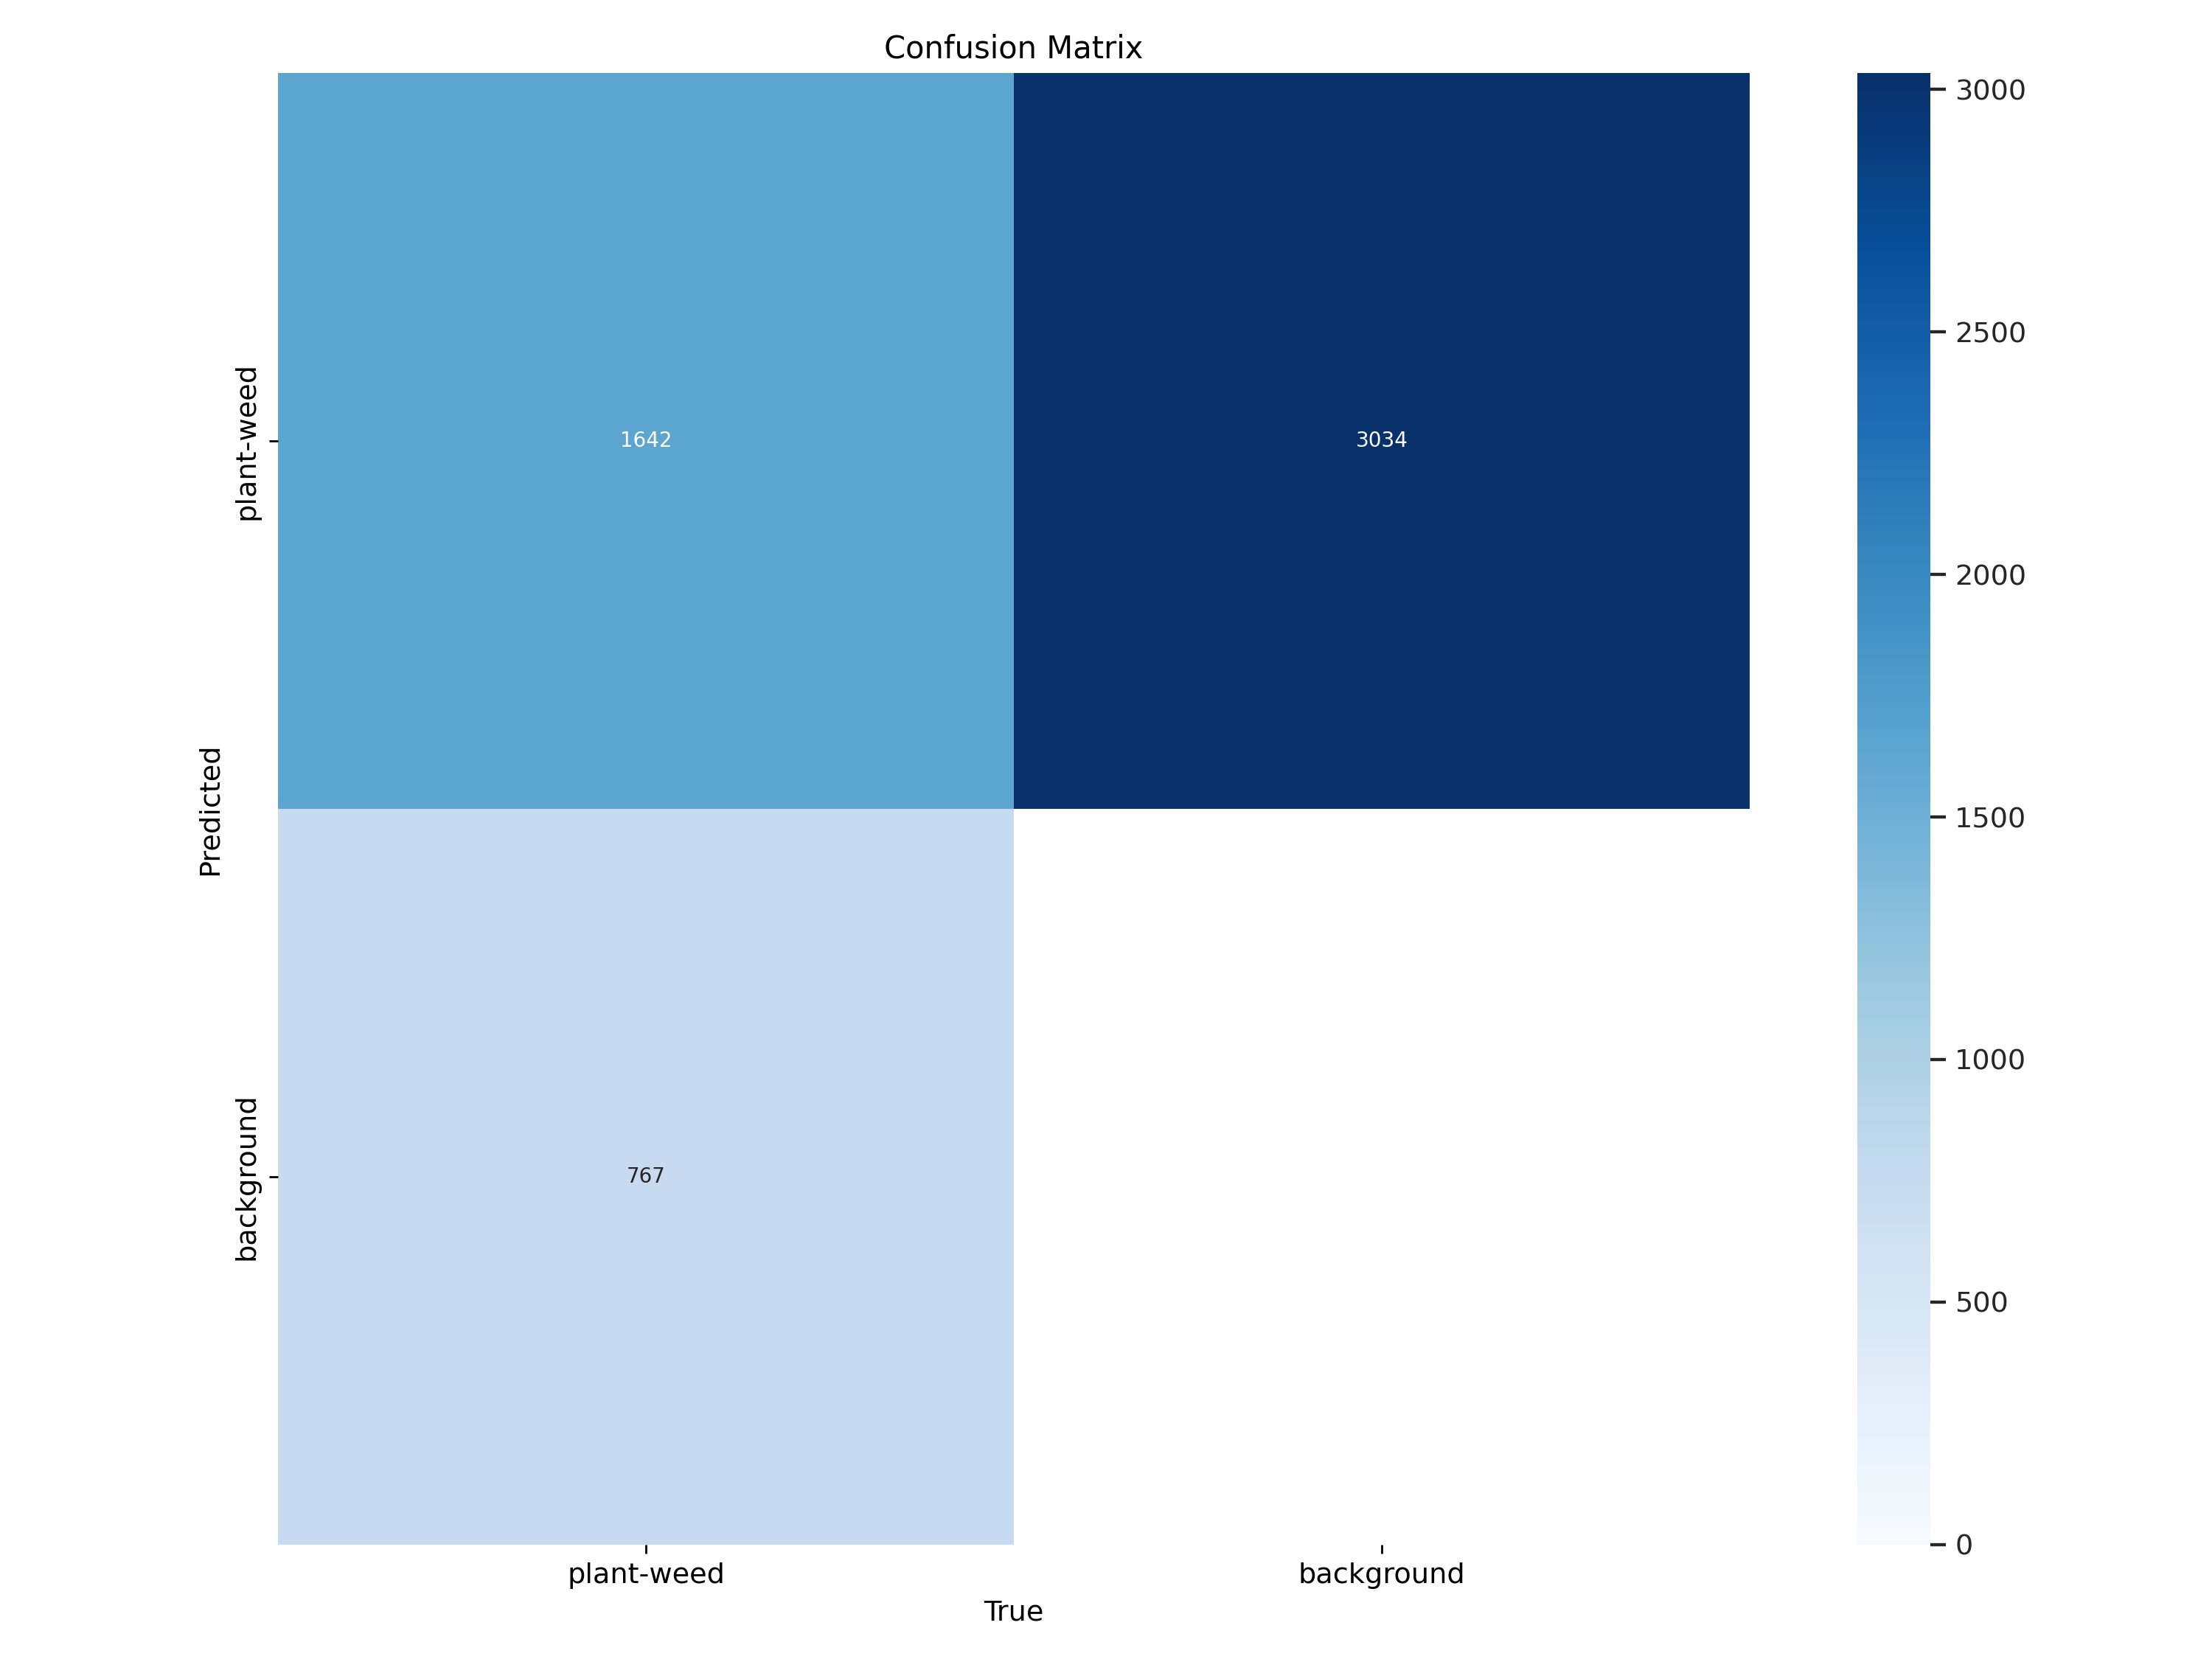

In [36]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

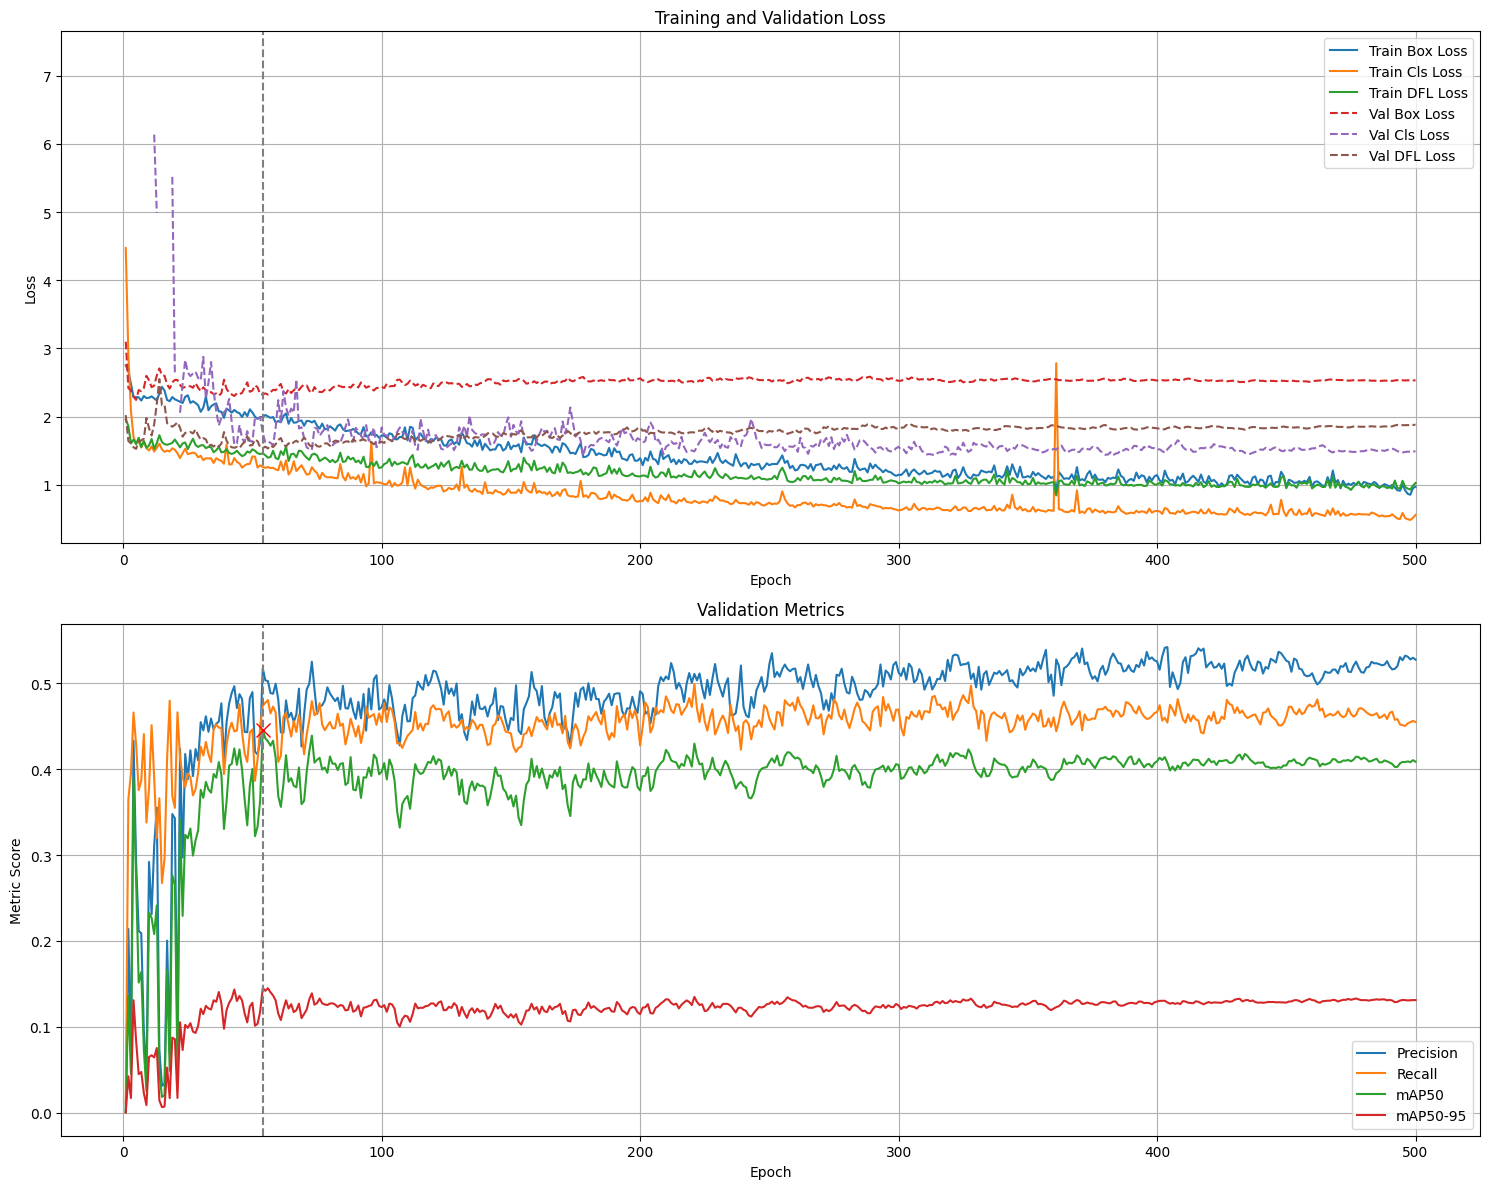

In [37]:
graph_training_metrics(df, epoch, graph="full")

In [38]:
graph_LrLoss_3D(df)

Validation set


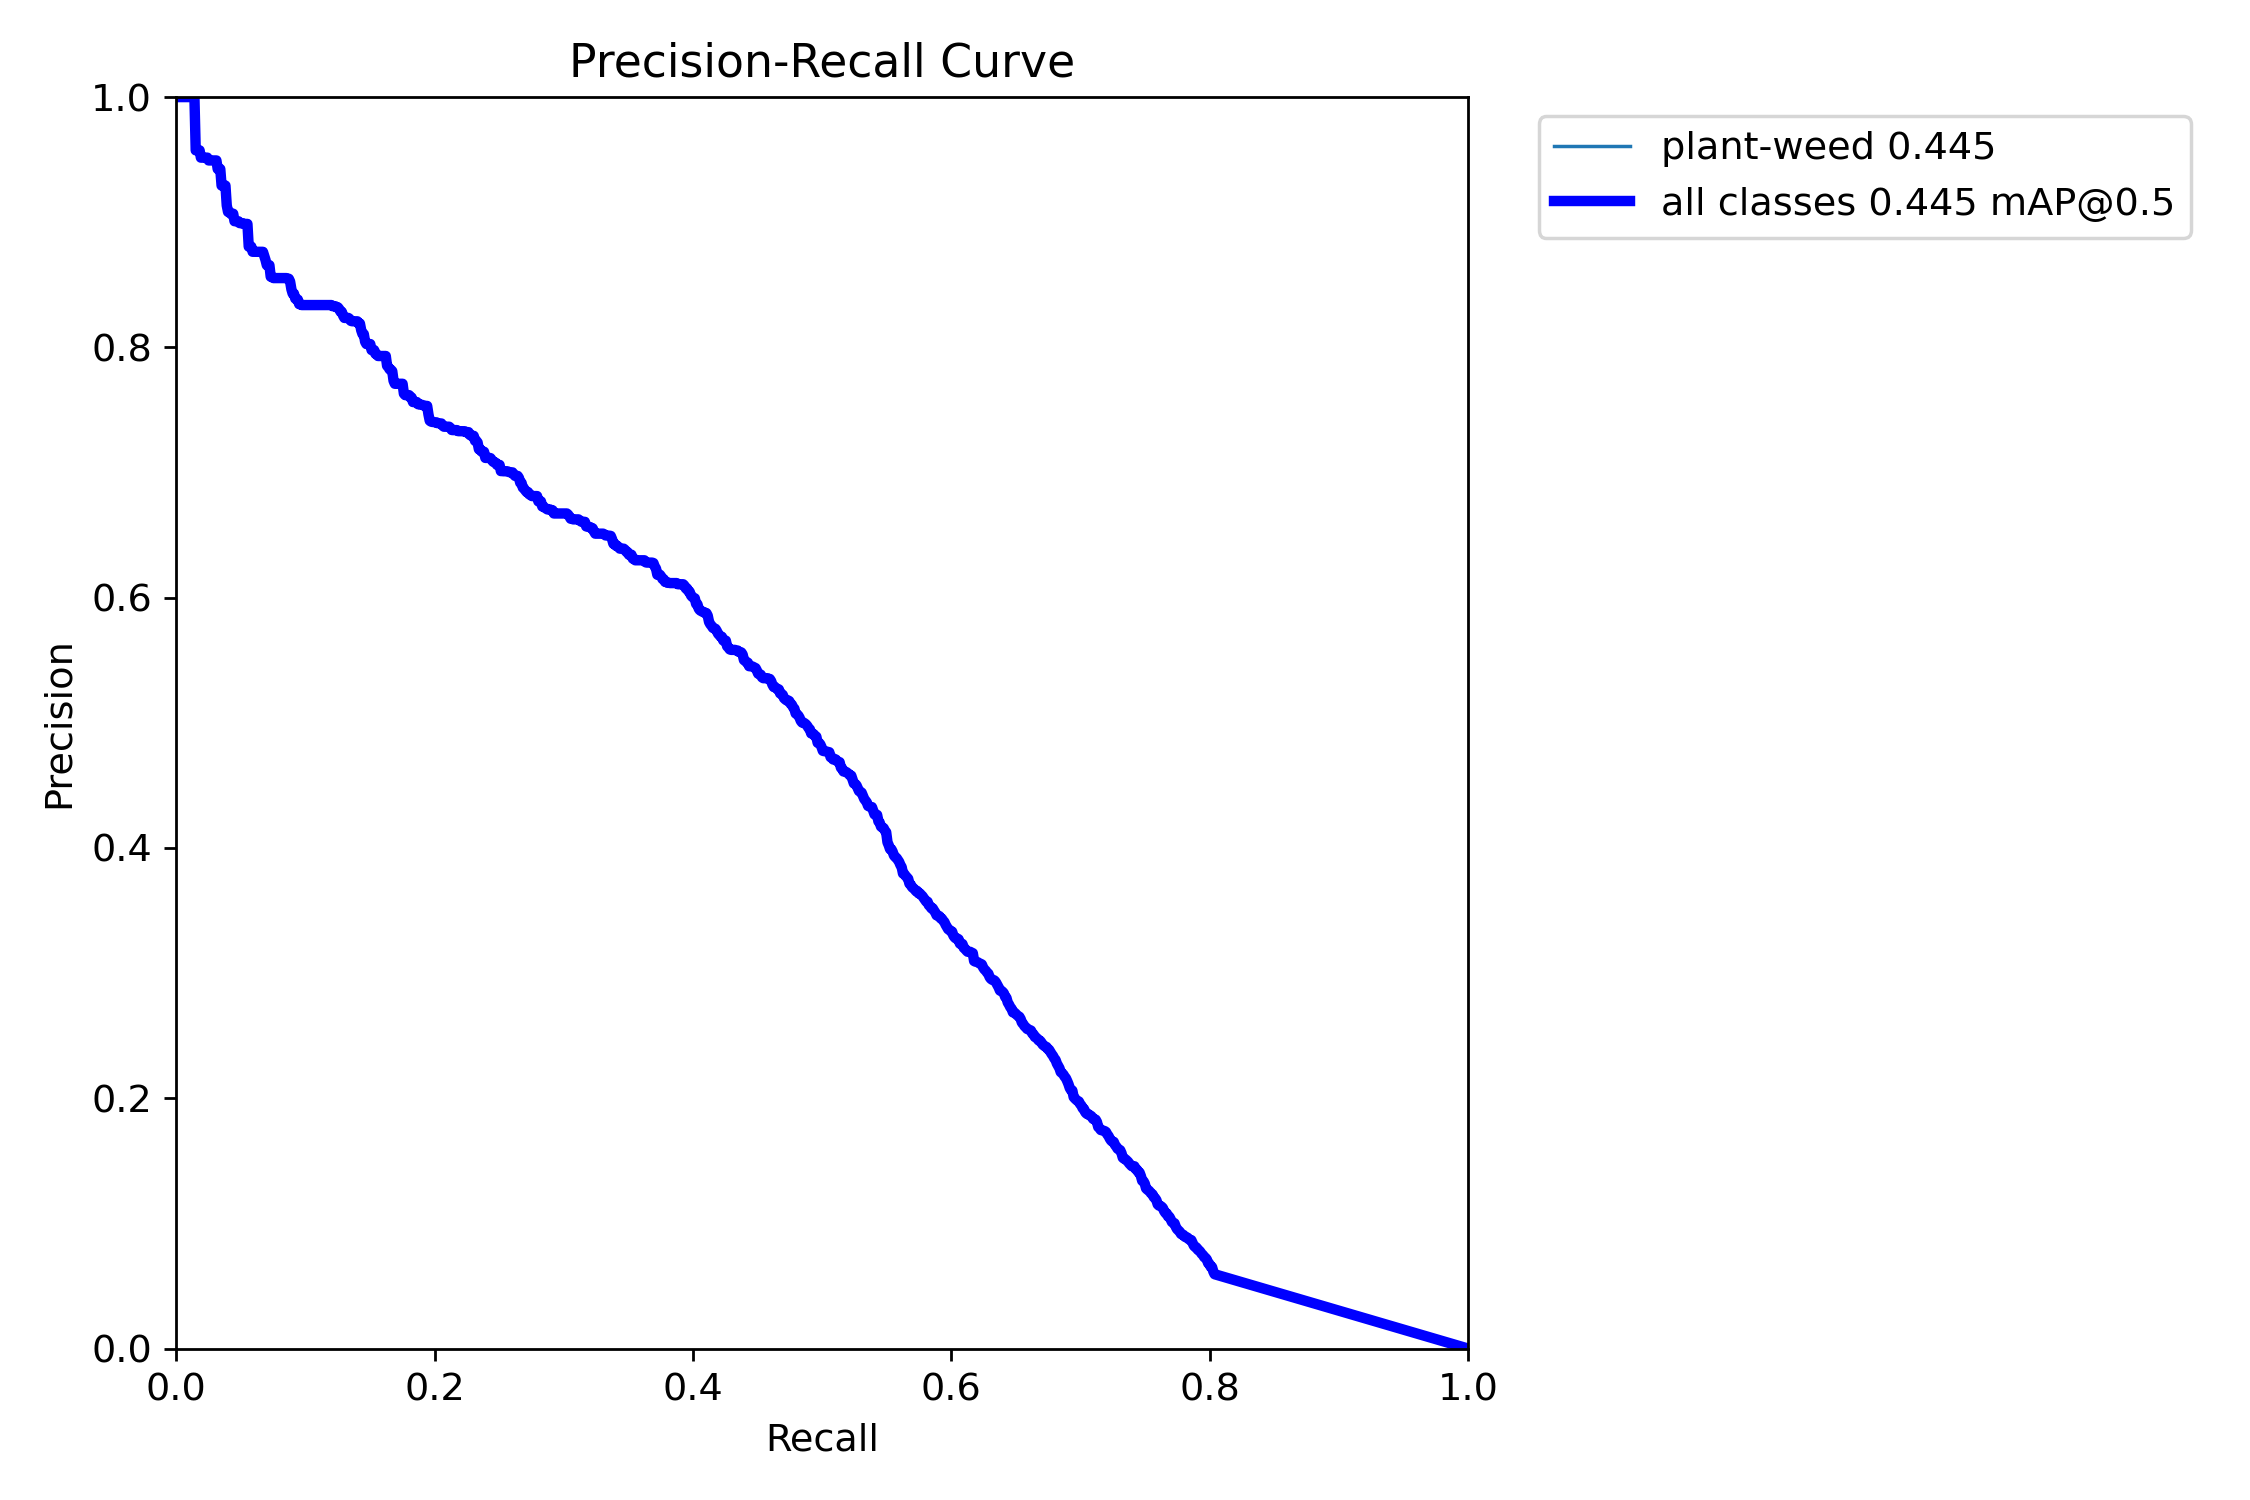

In [39]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

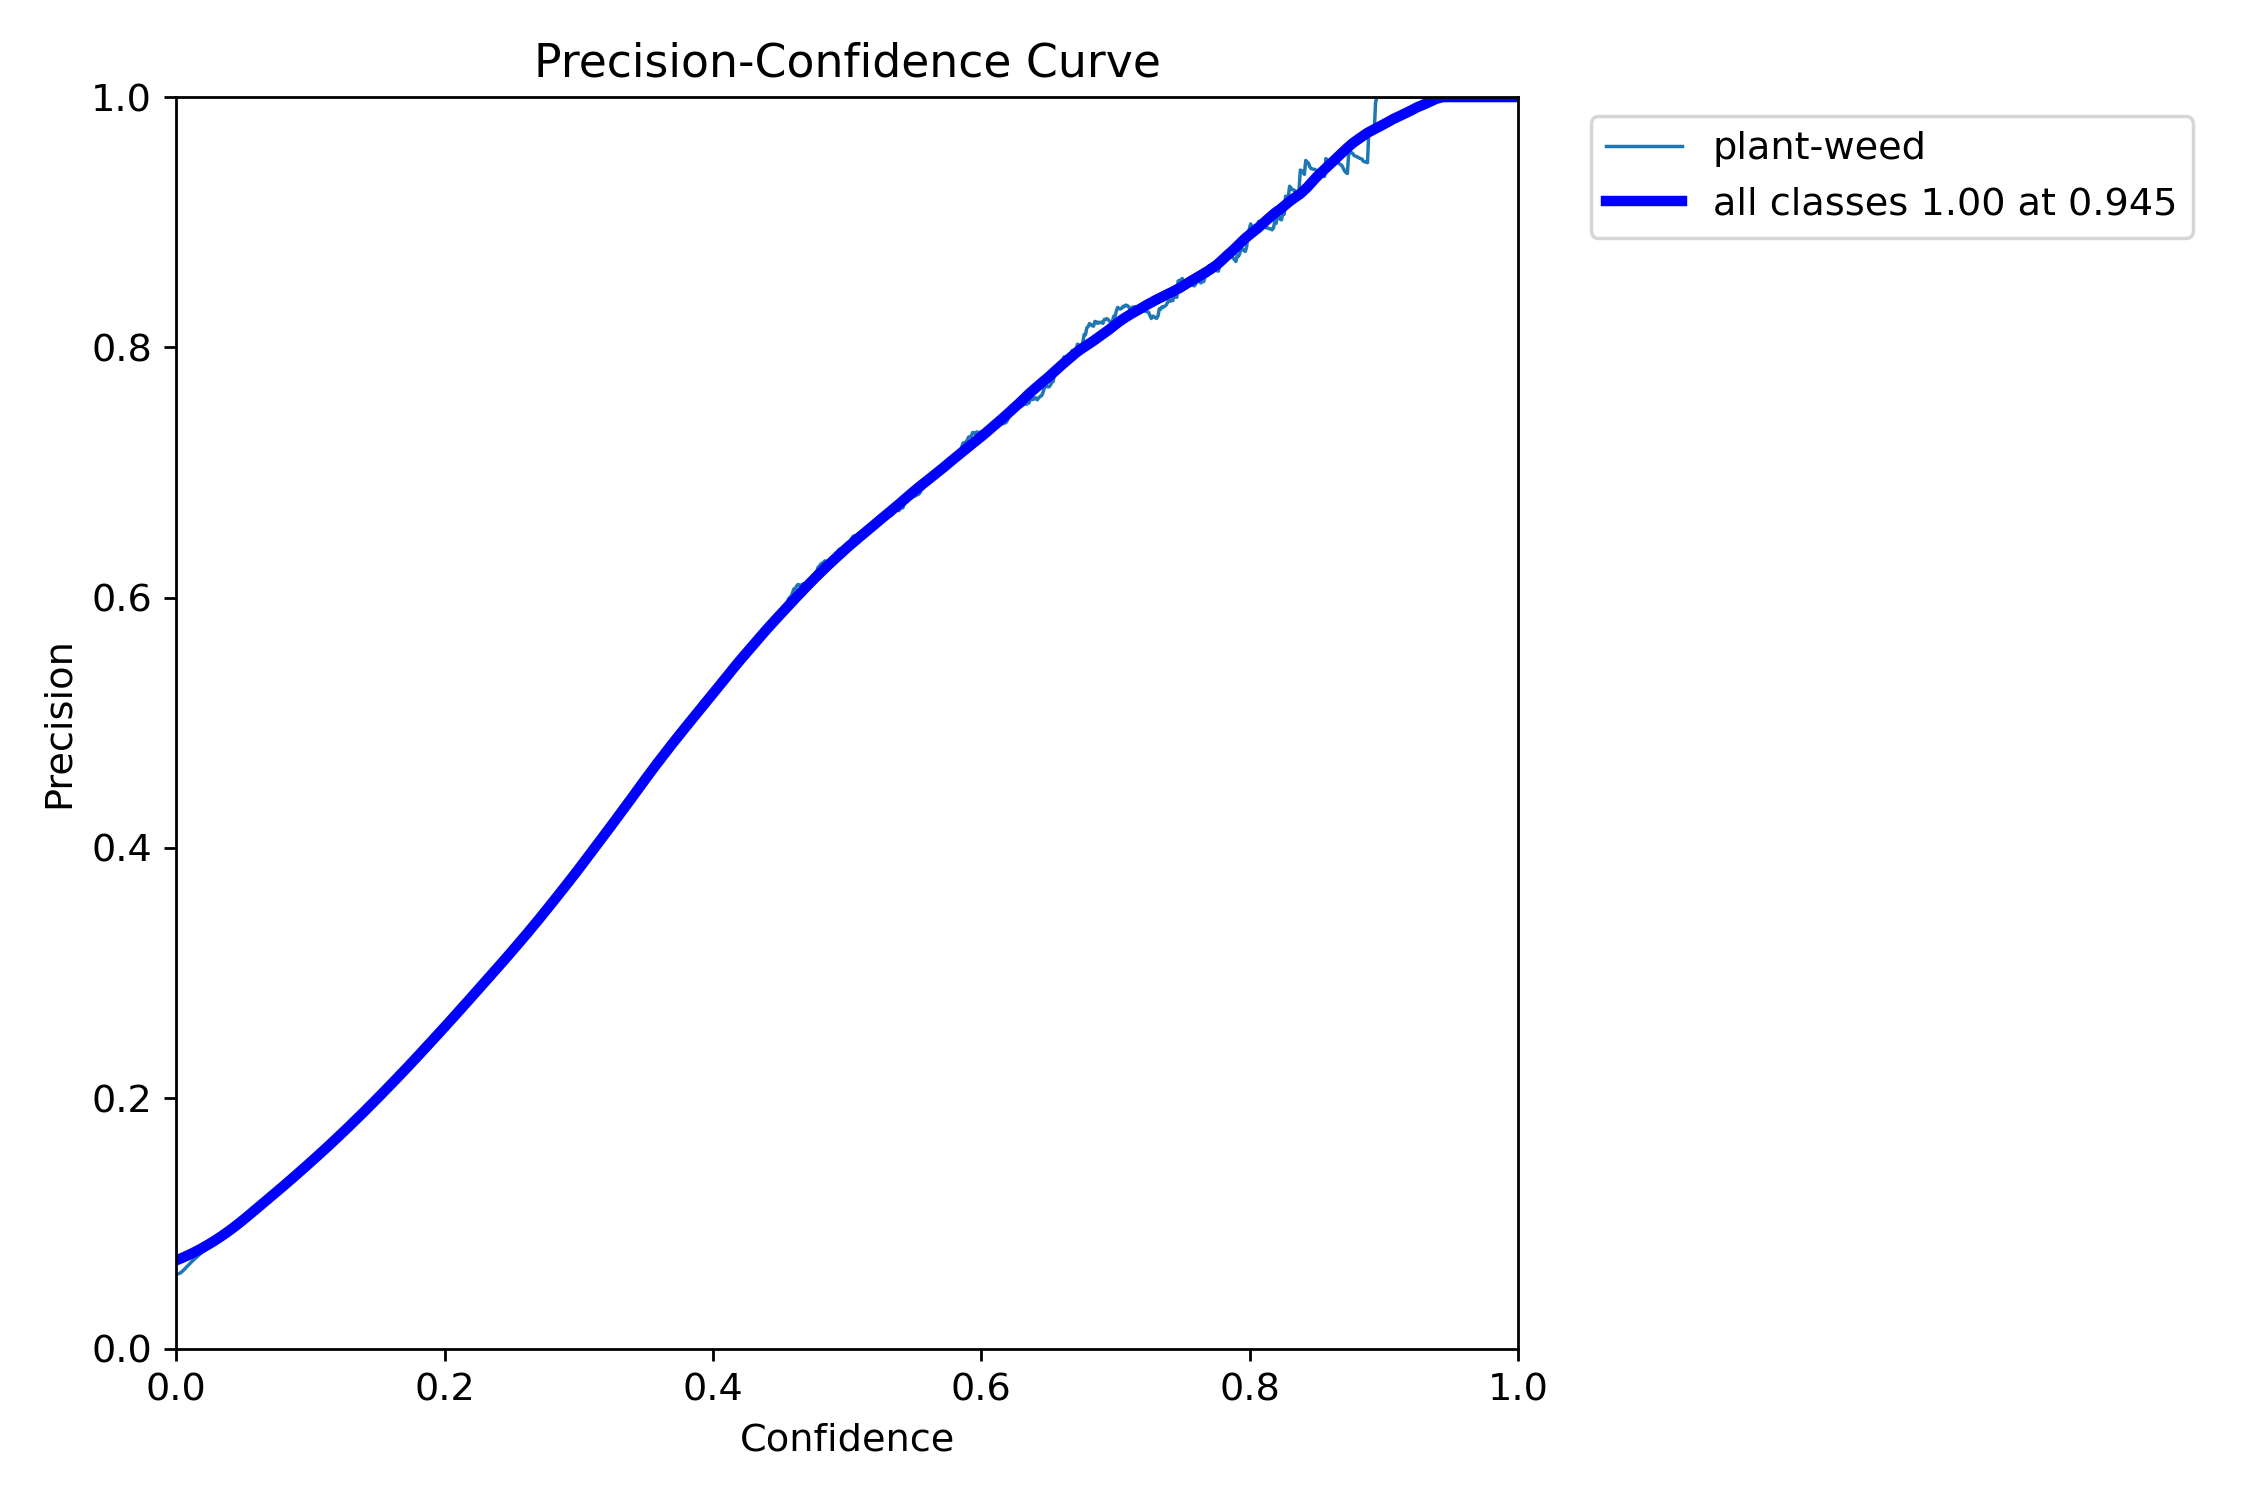

In [40]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

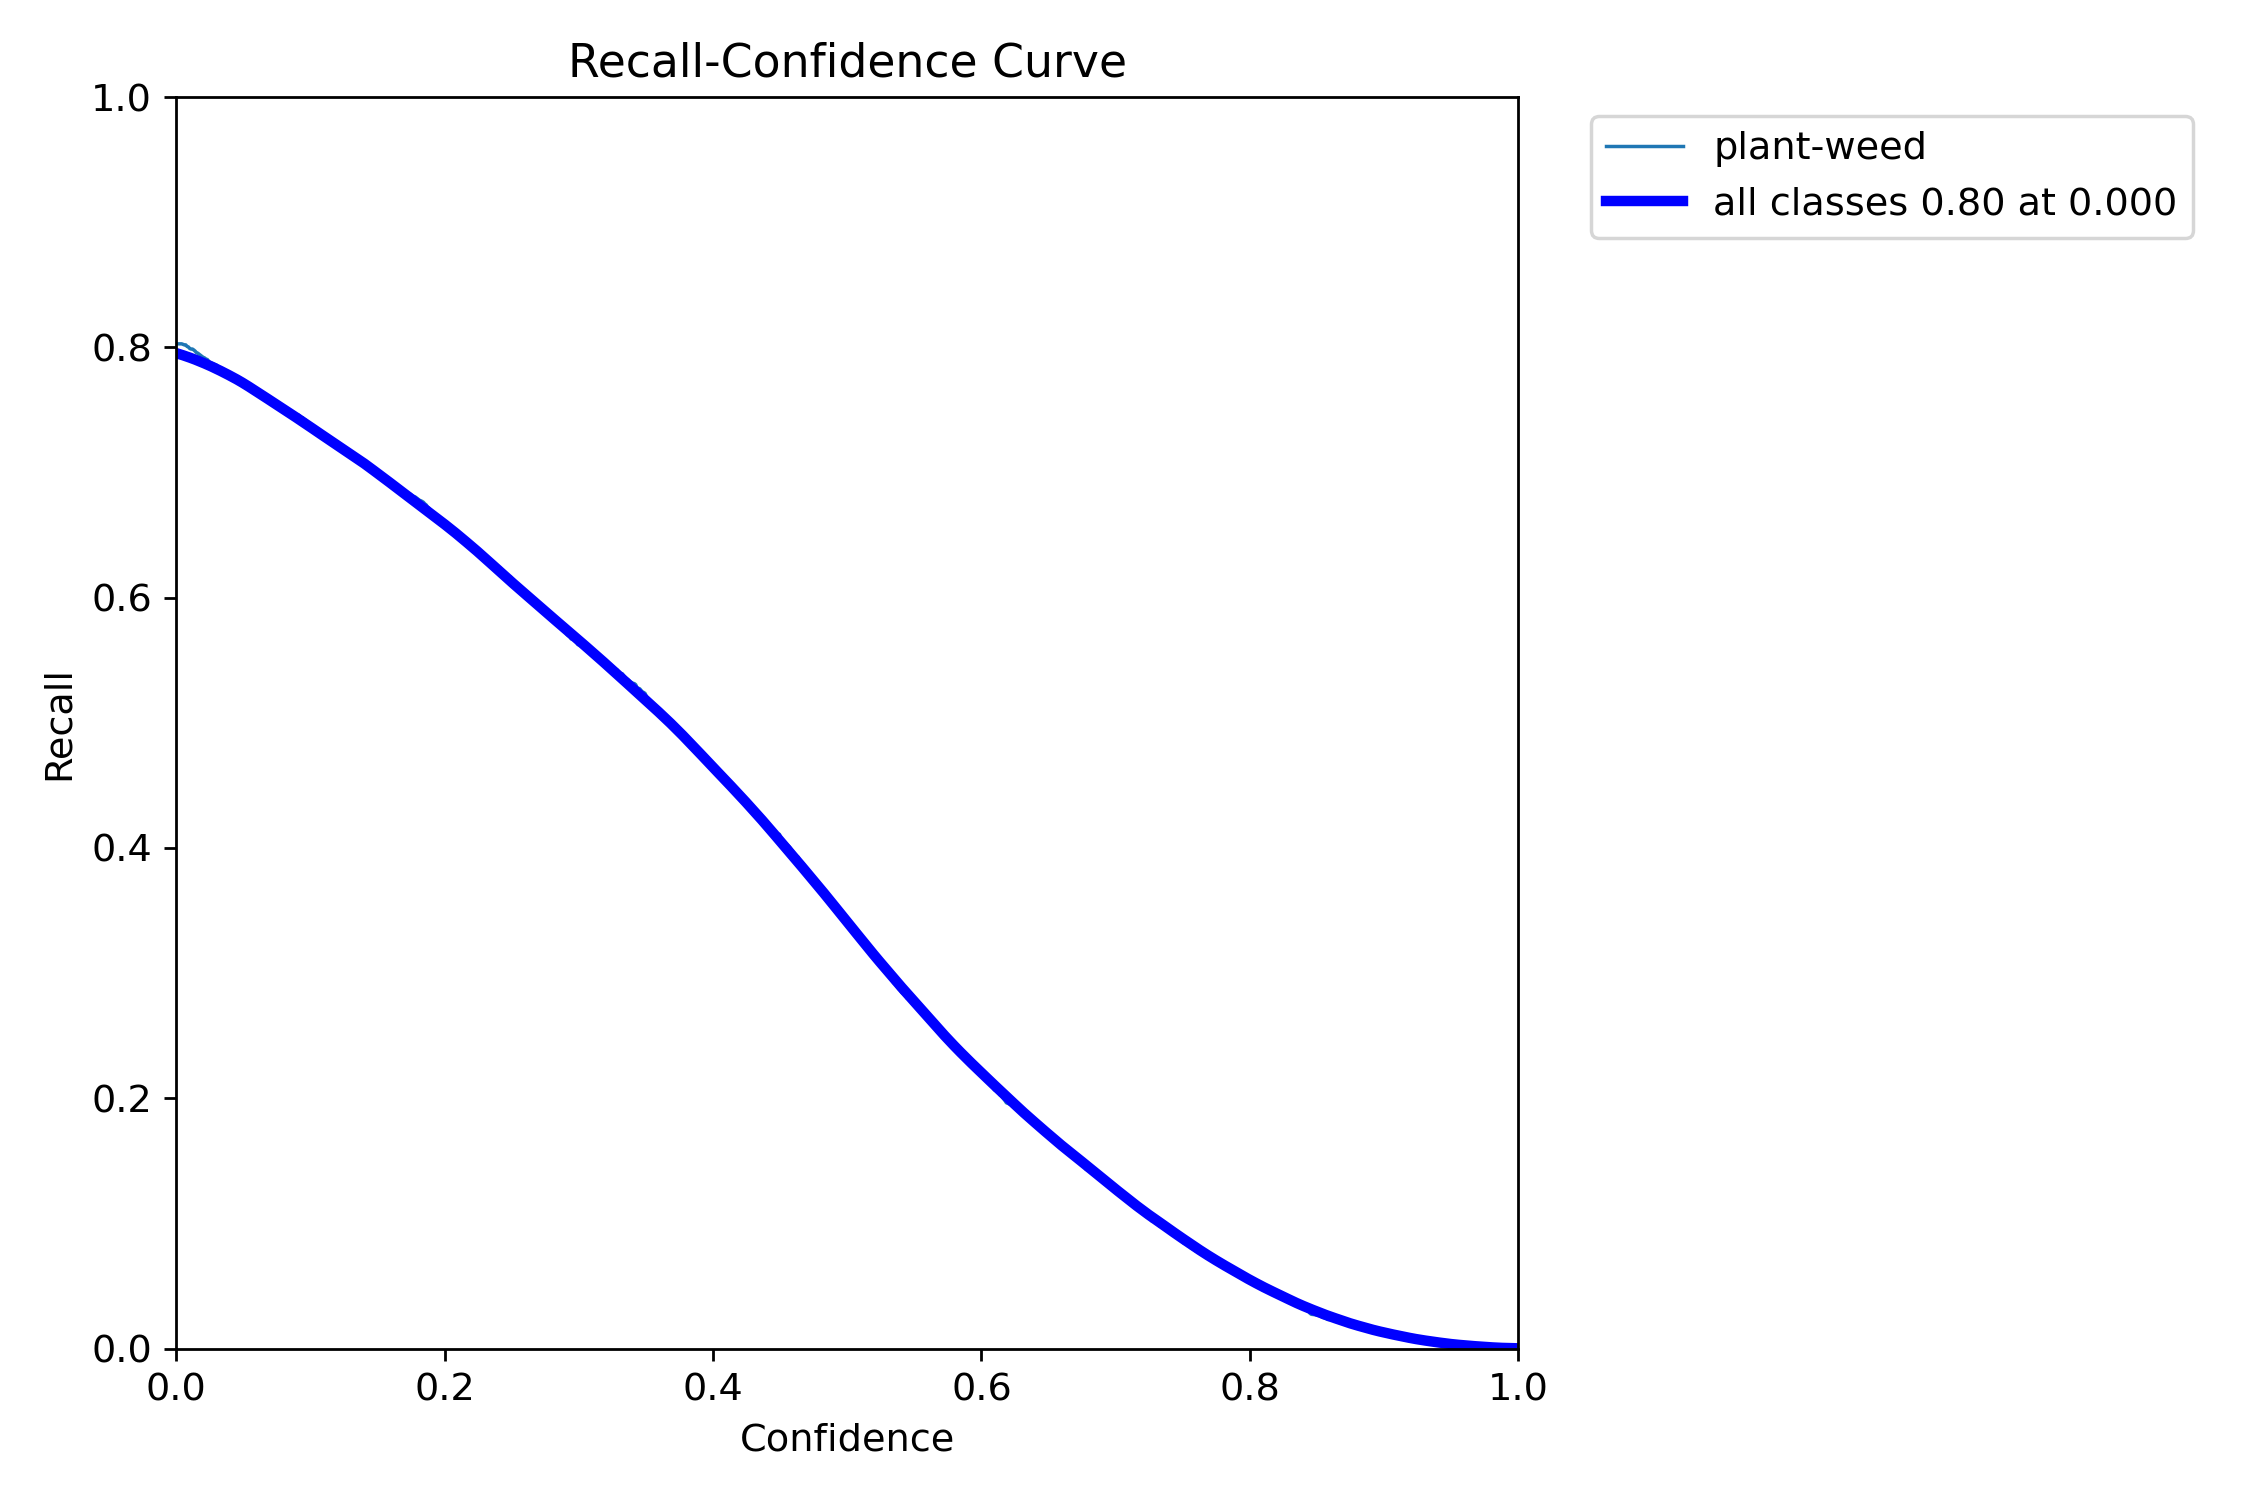

In [41]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

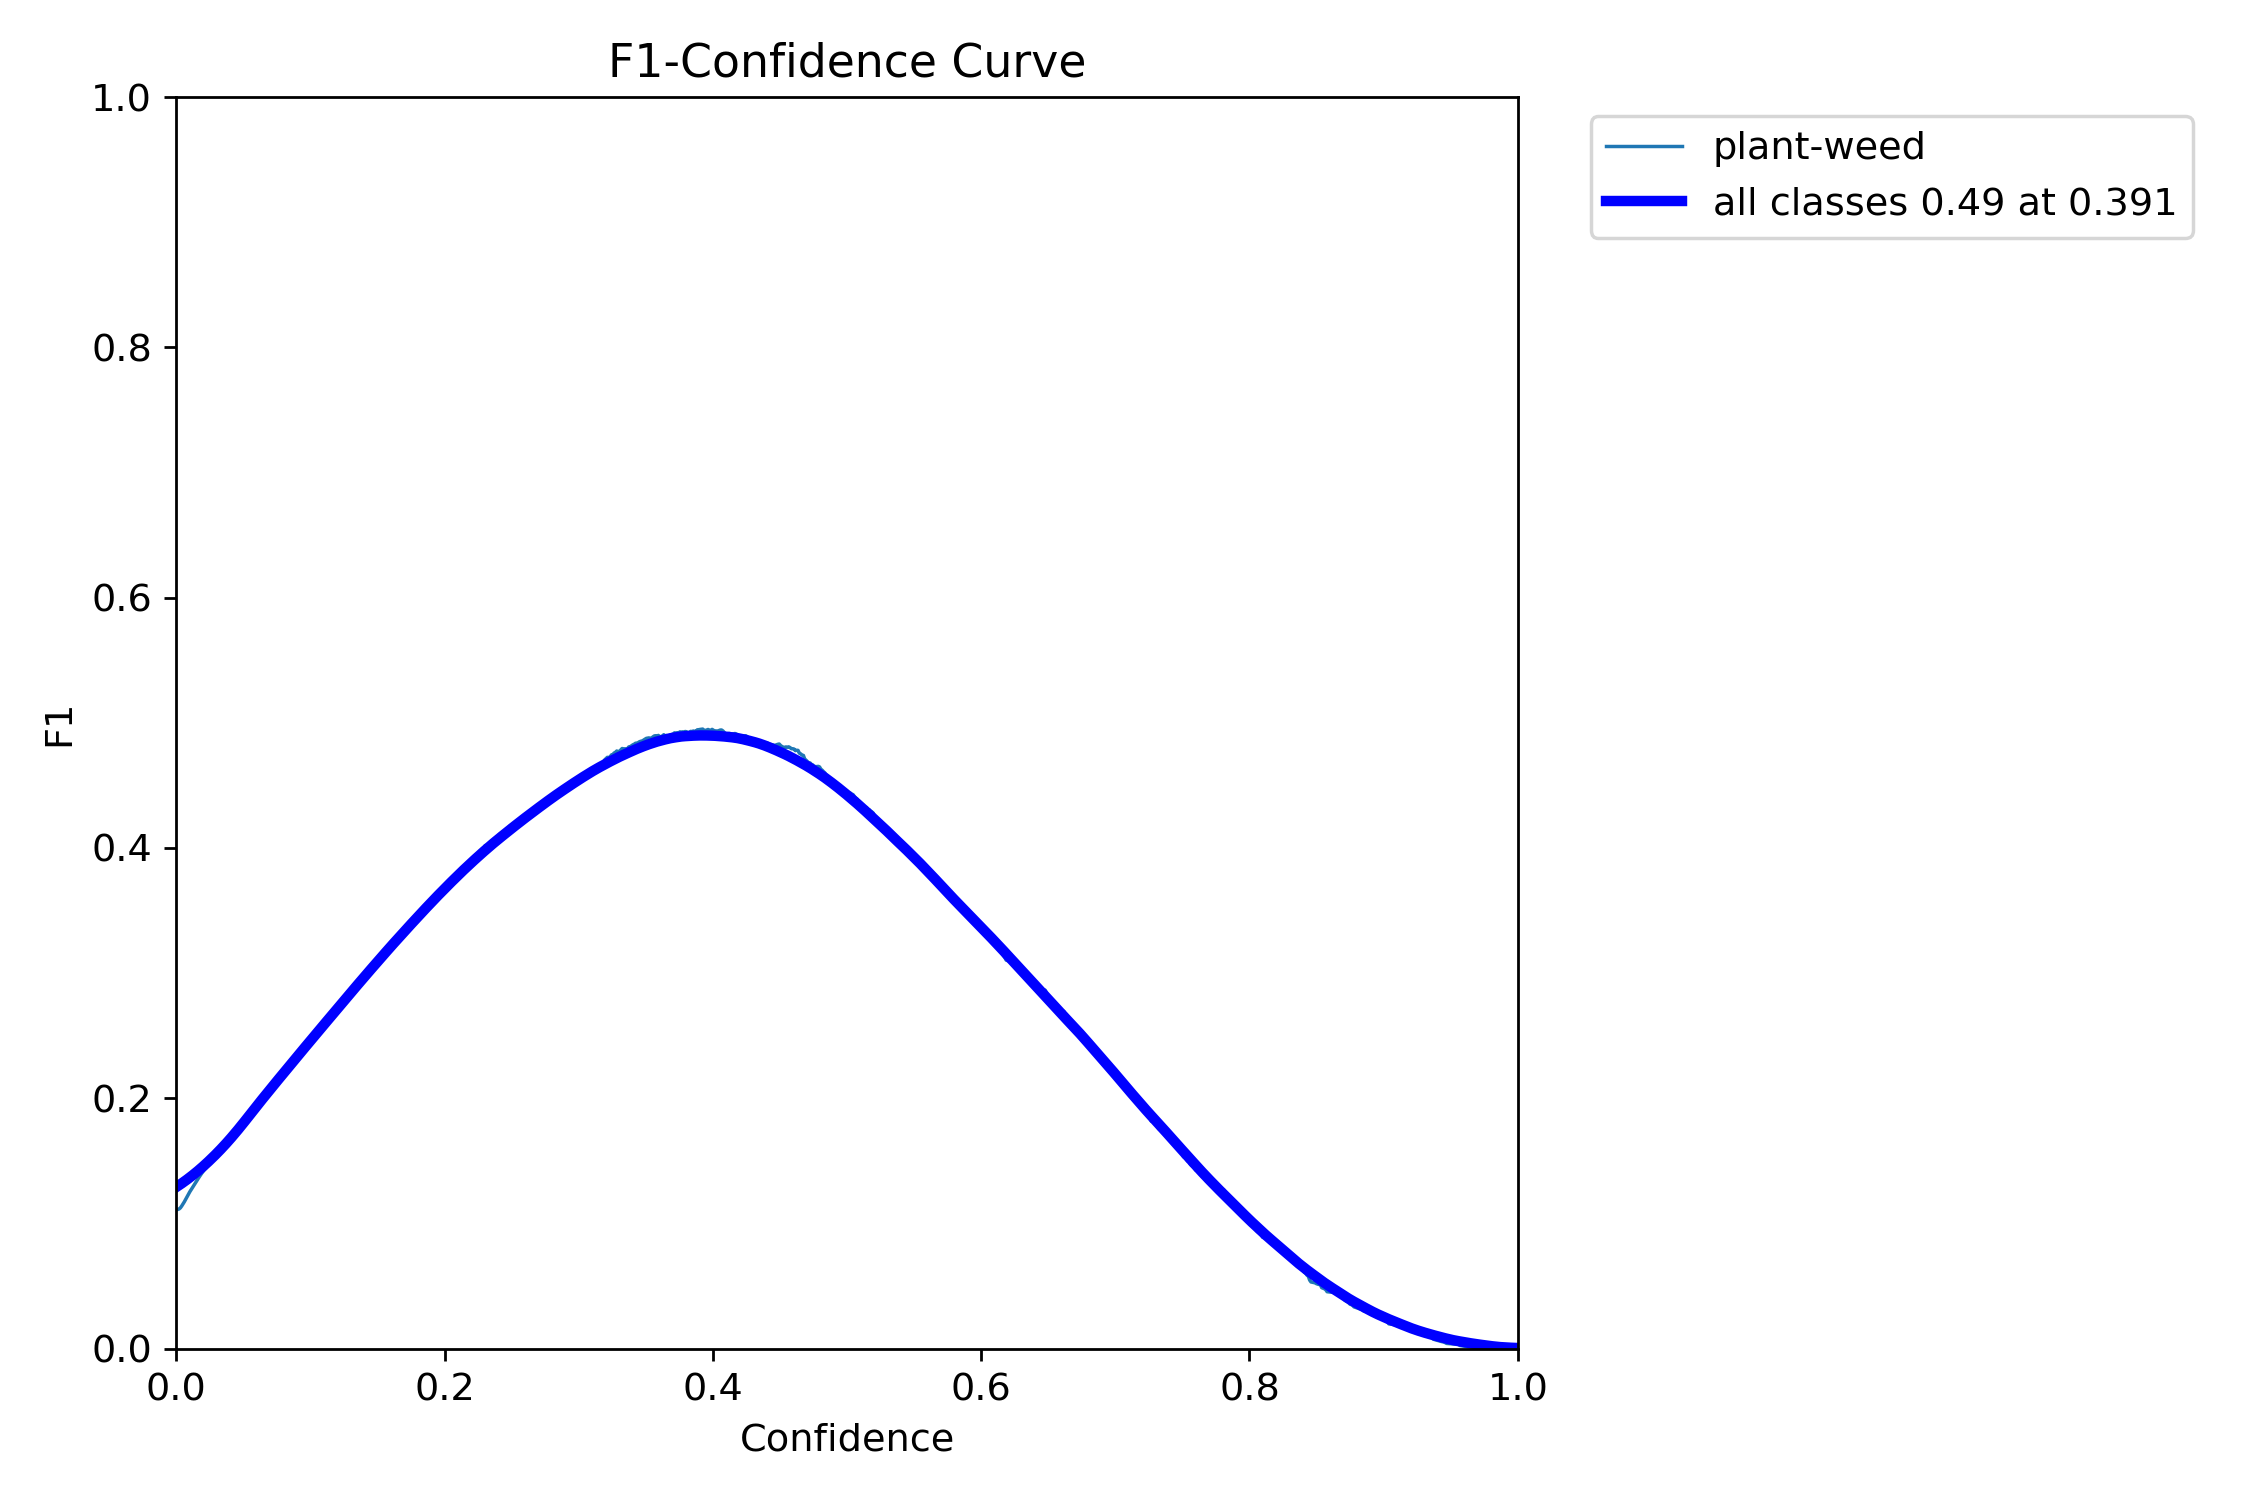

In [42]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

# References

## Experiment 19
### Default YOLO augmentation | ~1000 epochs
YOLO by Ultralytics apply data augementation by default using Albumentations library.

In [43]:
target_folder = f"docs/Experimentos/5 Model version/1 set/"
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/5 Model version/1 set
Project root updated to: ../../../../


In [44]:
folder = "v8/detect/train/"

In [45]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df3 = pd.read_csv(file_path)
df = df3.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
385,386,2985.60,1.16564,0.64824,1.00079,0.51783,0.44915,0.42026,0.13158,2.71083,1.35703,1.74103,0.001238,0.001238,0.001238
386,387,2993.32,1.16003,0.64194,1.00164,0.49944,0.45828,0.41433,0.13166,2.68775,1.35982,1.71300,0.001236,0.001236,0.001236
387,388,3001.15,1.20936,0.66569,1.00235,0.51585,0.48194,0.43181,0.13696,2.64976,1.37377,1.70644,0.001234,0.001234,0.001234
388,389,3008.95,1.19211,0.66791,1.00913,0.51908,0.48609,0.42939,0.13653,2.62402,1.36774,1.70599,0.001232,0.001232,0.001232
389,390,3016.91,1.16665,0.65433,1.00045,0.52793,0.48187,0.43890,0.13979,2.61230,1.35686,1.70114,0.001230,0.001230,0.001230


In [46]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 50.282 min


#### Best epoch

In [47]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
360,361,2792.5,1.20257,0.66073,1.00807,0.54572,0.48236,0.45092,0.14408,2.61832,1.37244,1.71799,0.001287,0.001287,0.001287,50.281833


In [48]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print("Proceso de entrenamiento:")
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Proceso de entrenamiento:
Mejor época de entrenamiento 361 con mAP50 de 0.451


In [49]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [50]:
TP = 1374
FP = 1184
FN = 1035
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 3593


In [51]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.3824102421374896, 0.32952964096855, 0.2880601168939605)

### Graphs

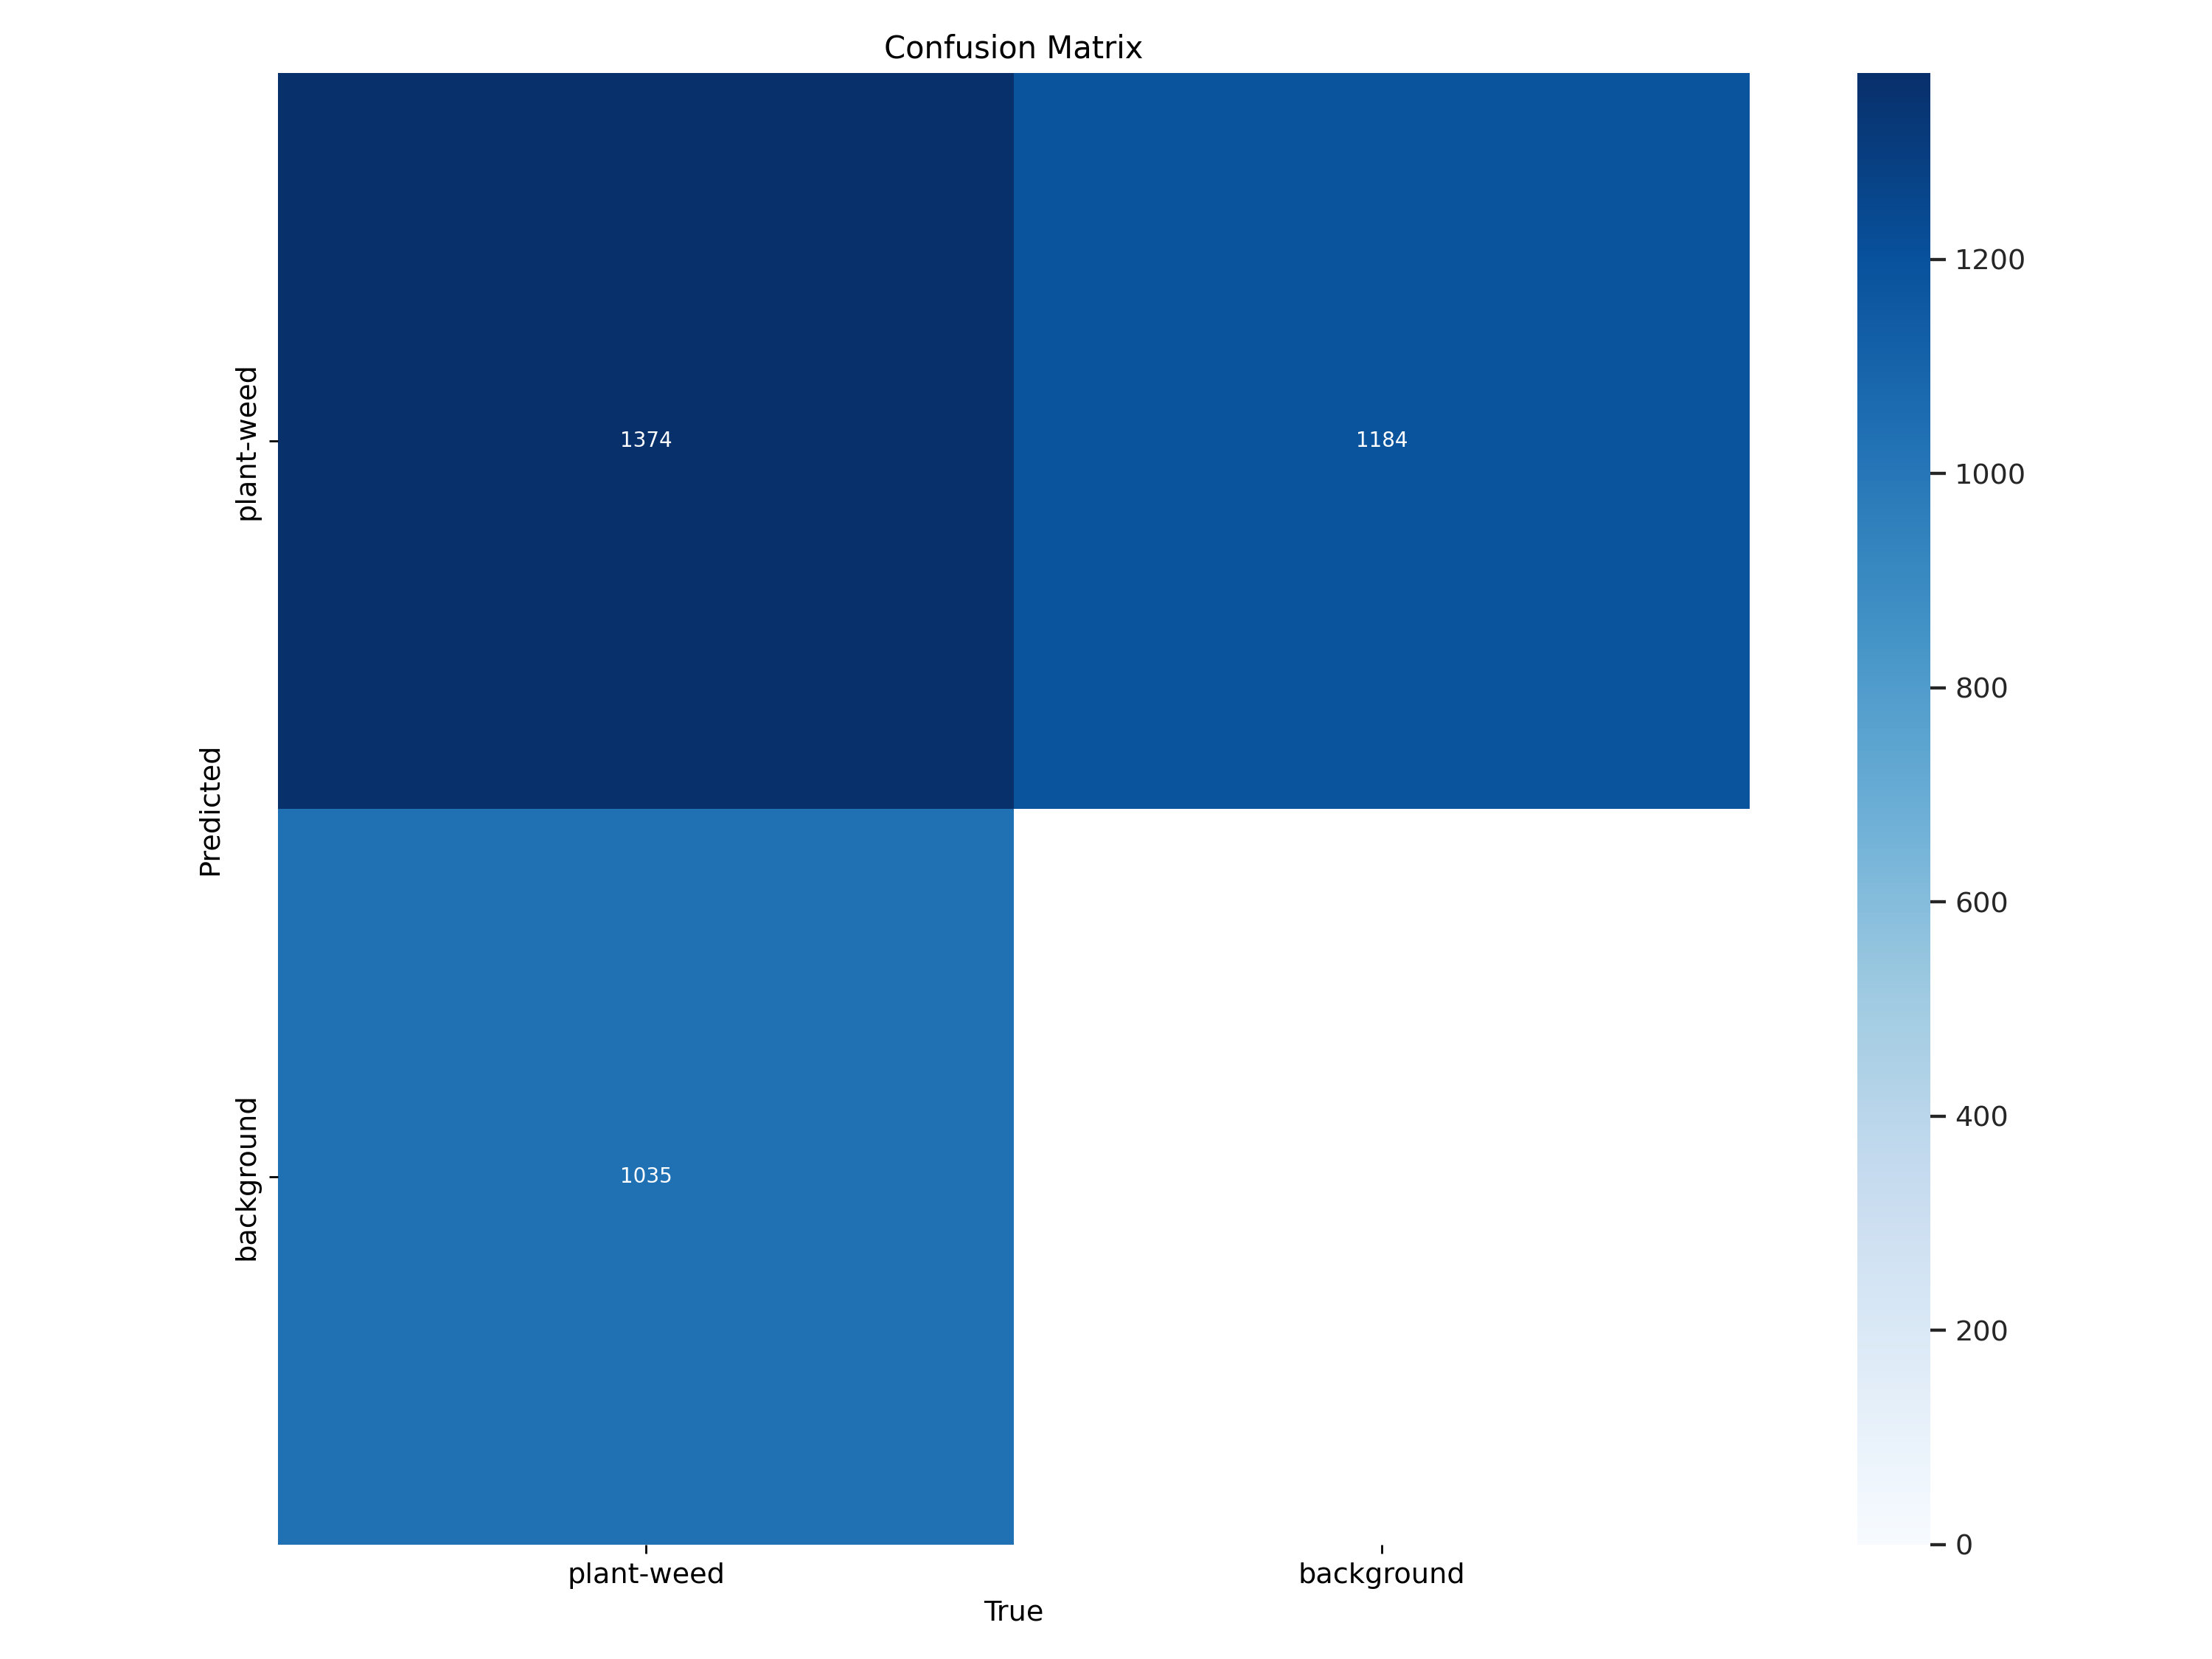

In [52]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

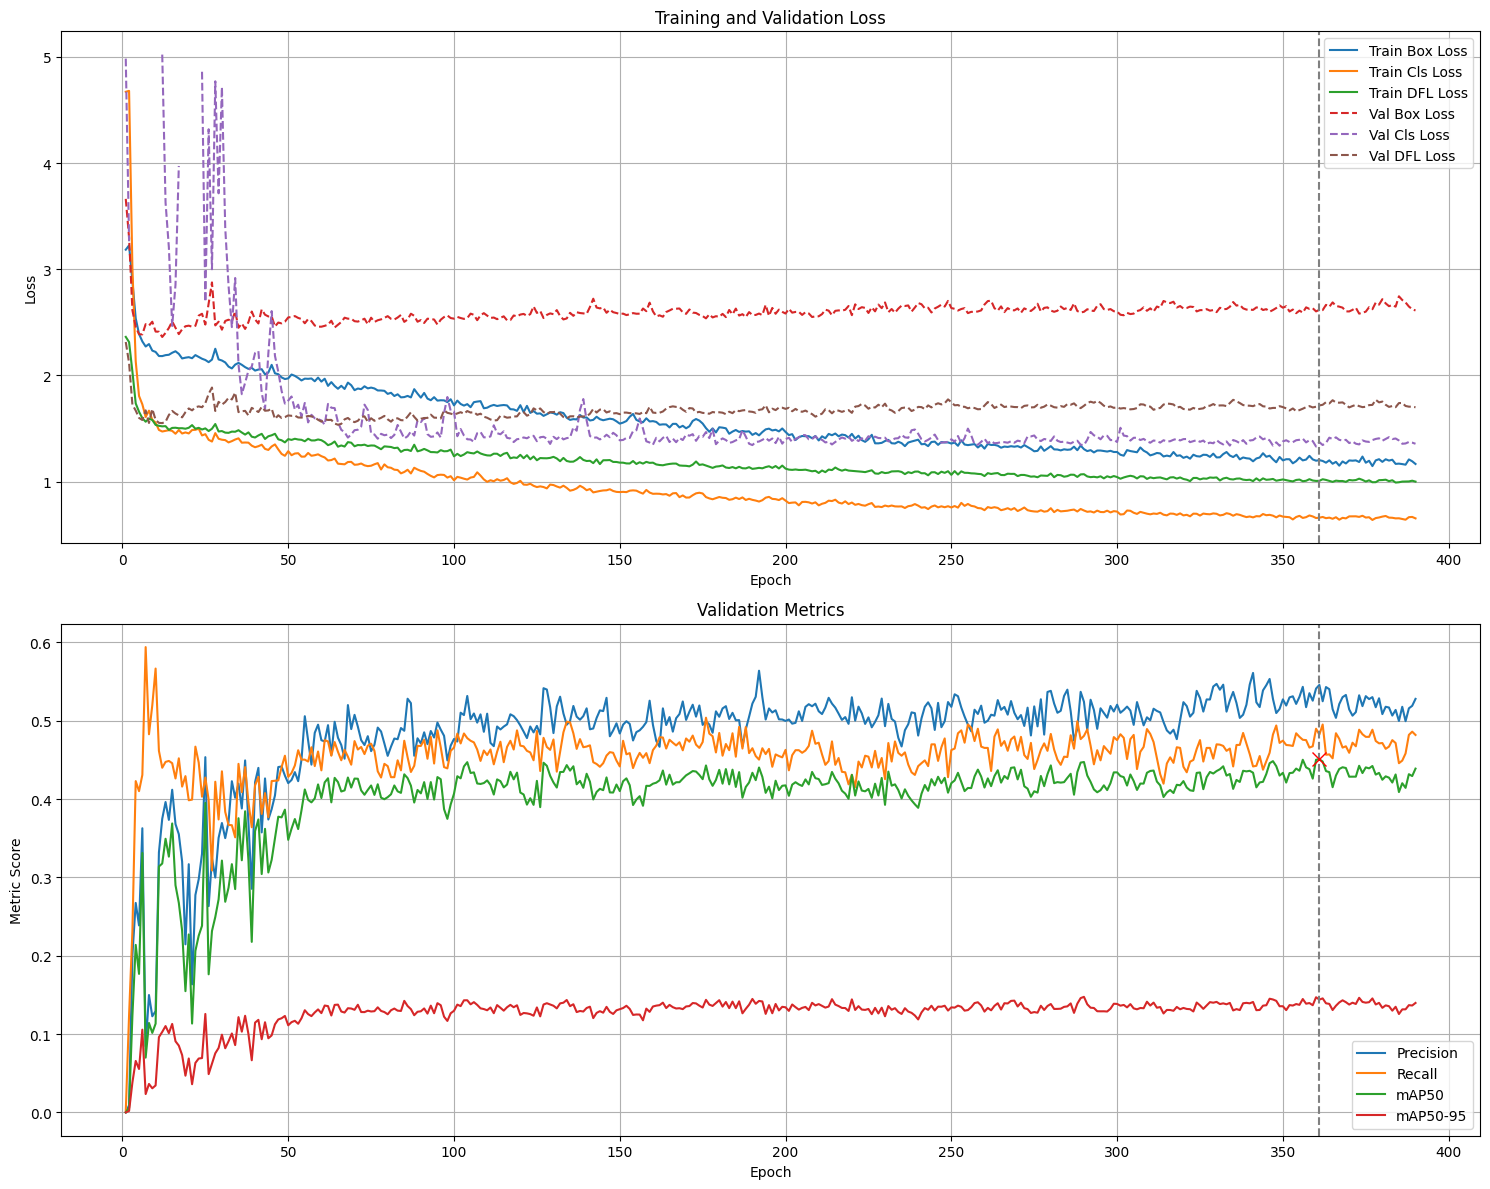

In [53]:
graph_training_metrics(df, epoch, graph="full")


_**NOTA:** `patience`=100 para EarlyStop_

In [54]:
graph_LrLoss_3D(df)

Validation set


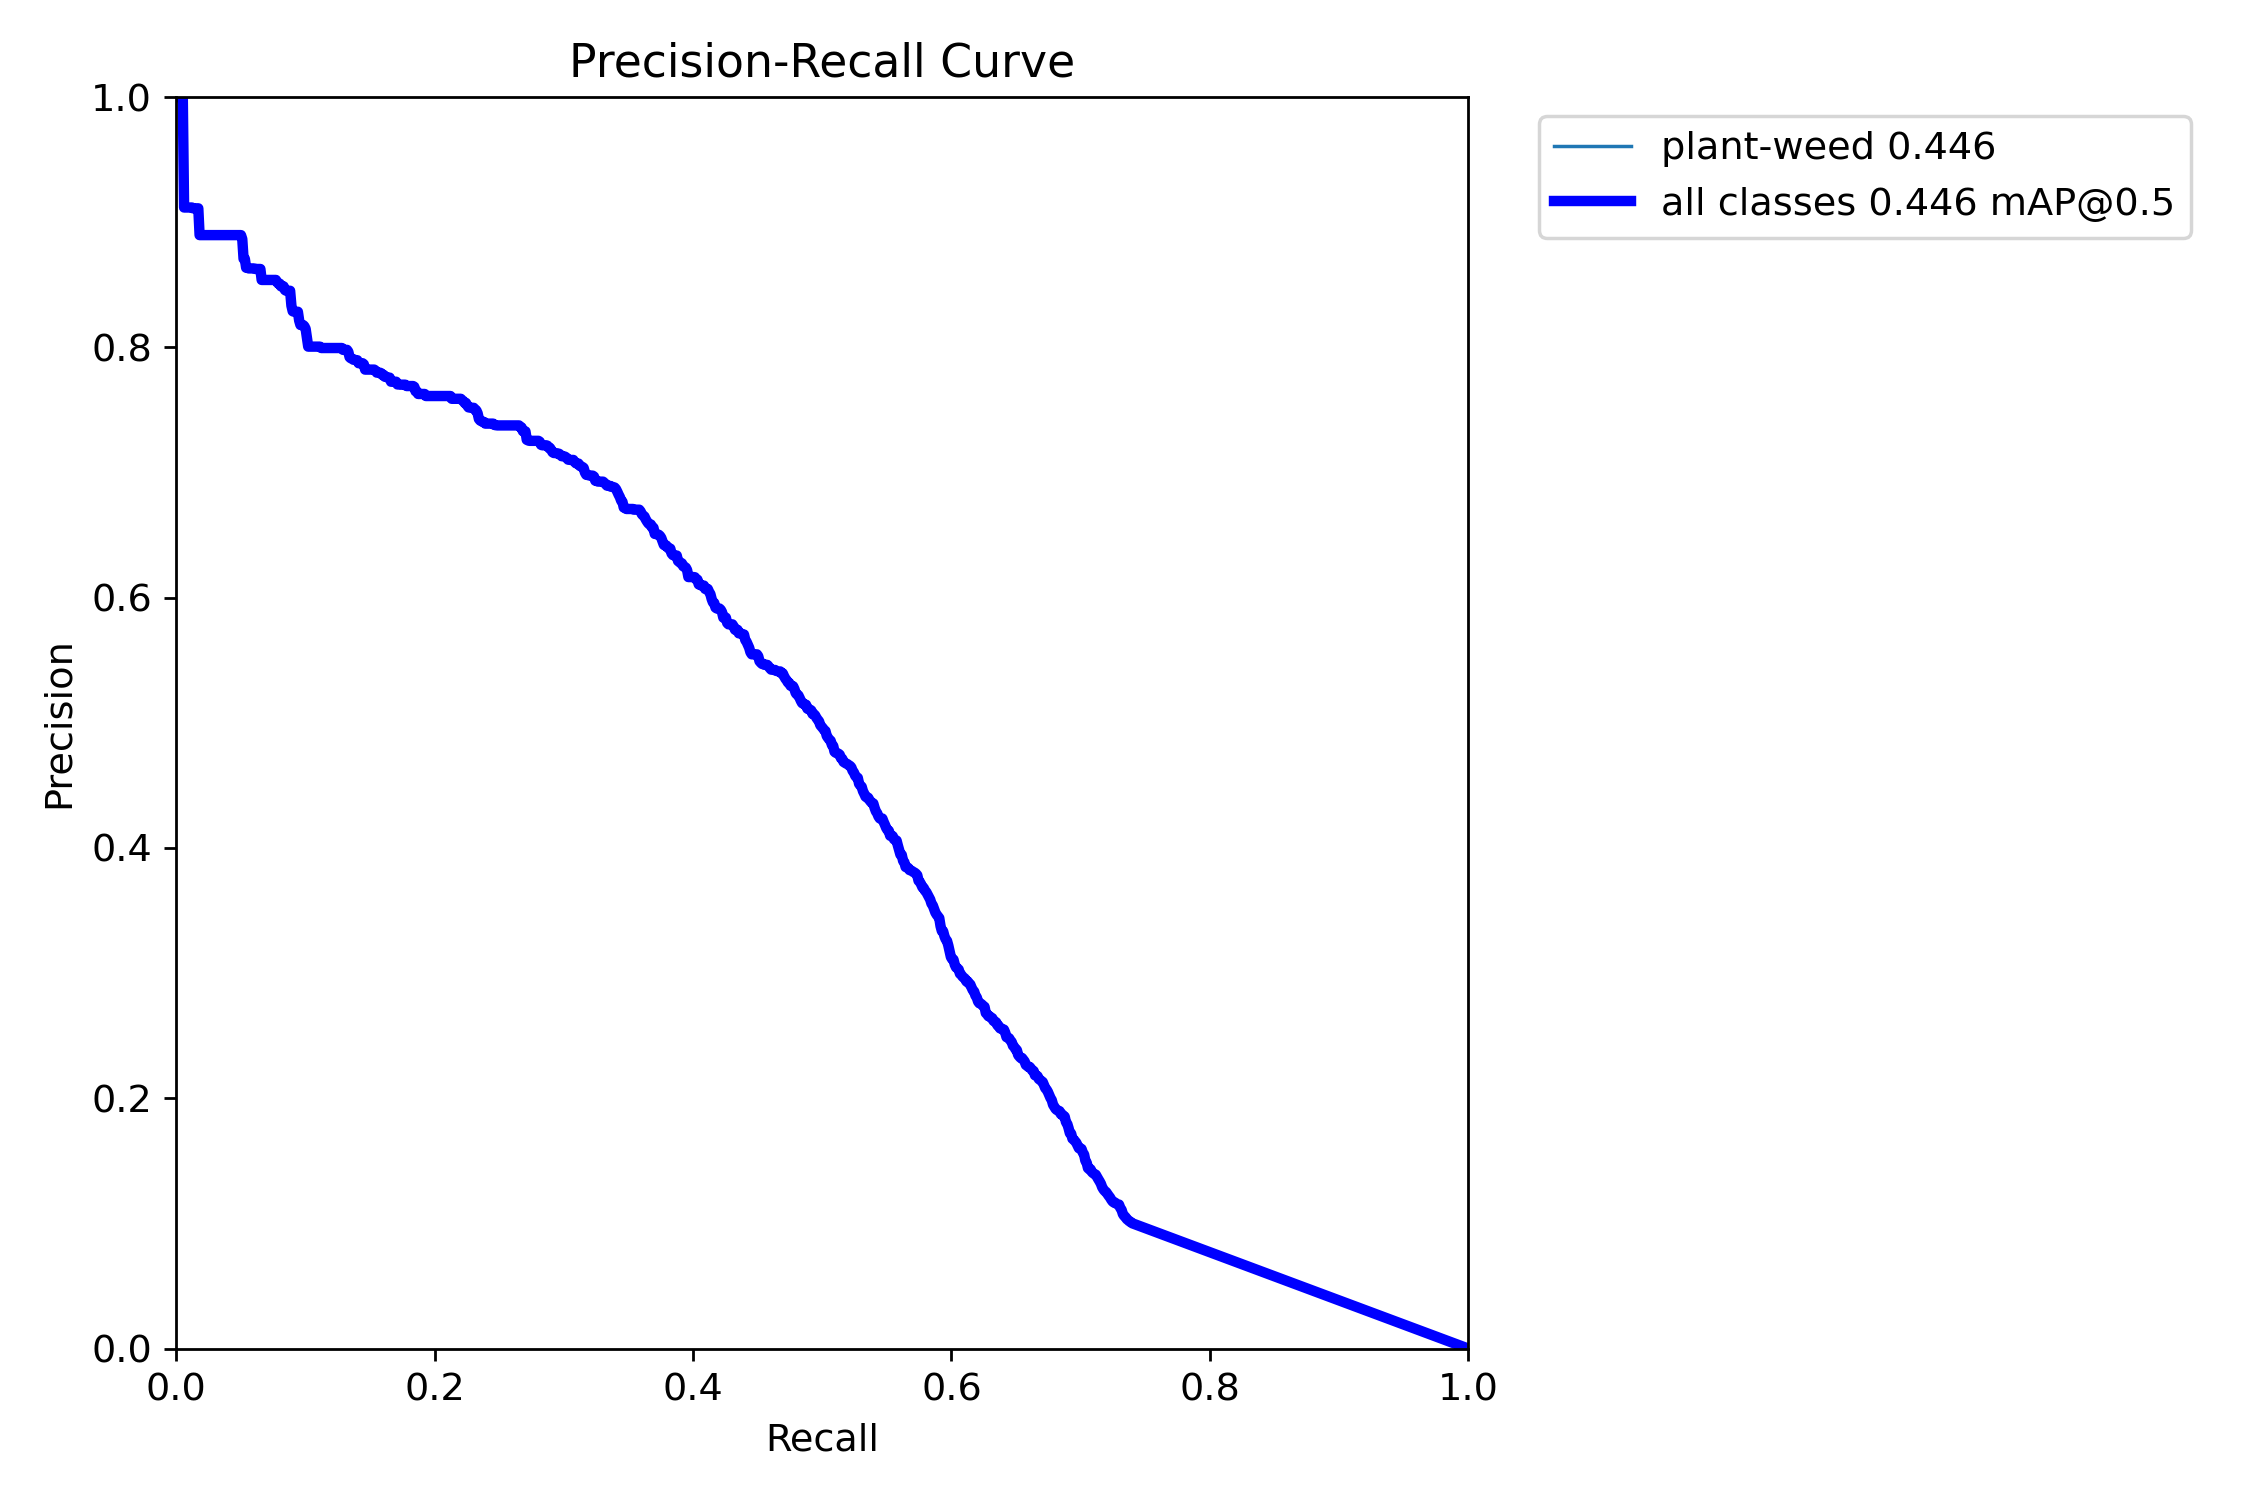

In [55]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

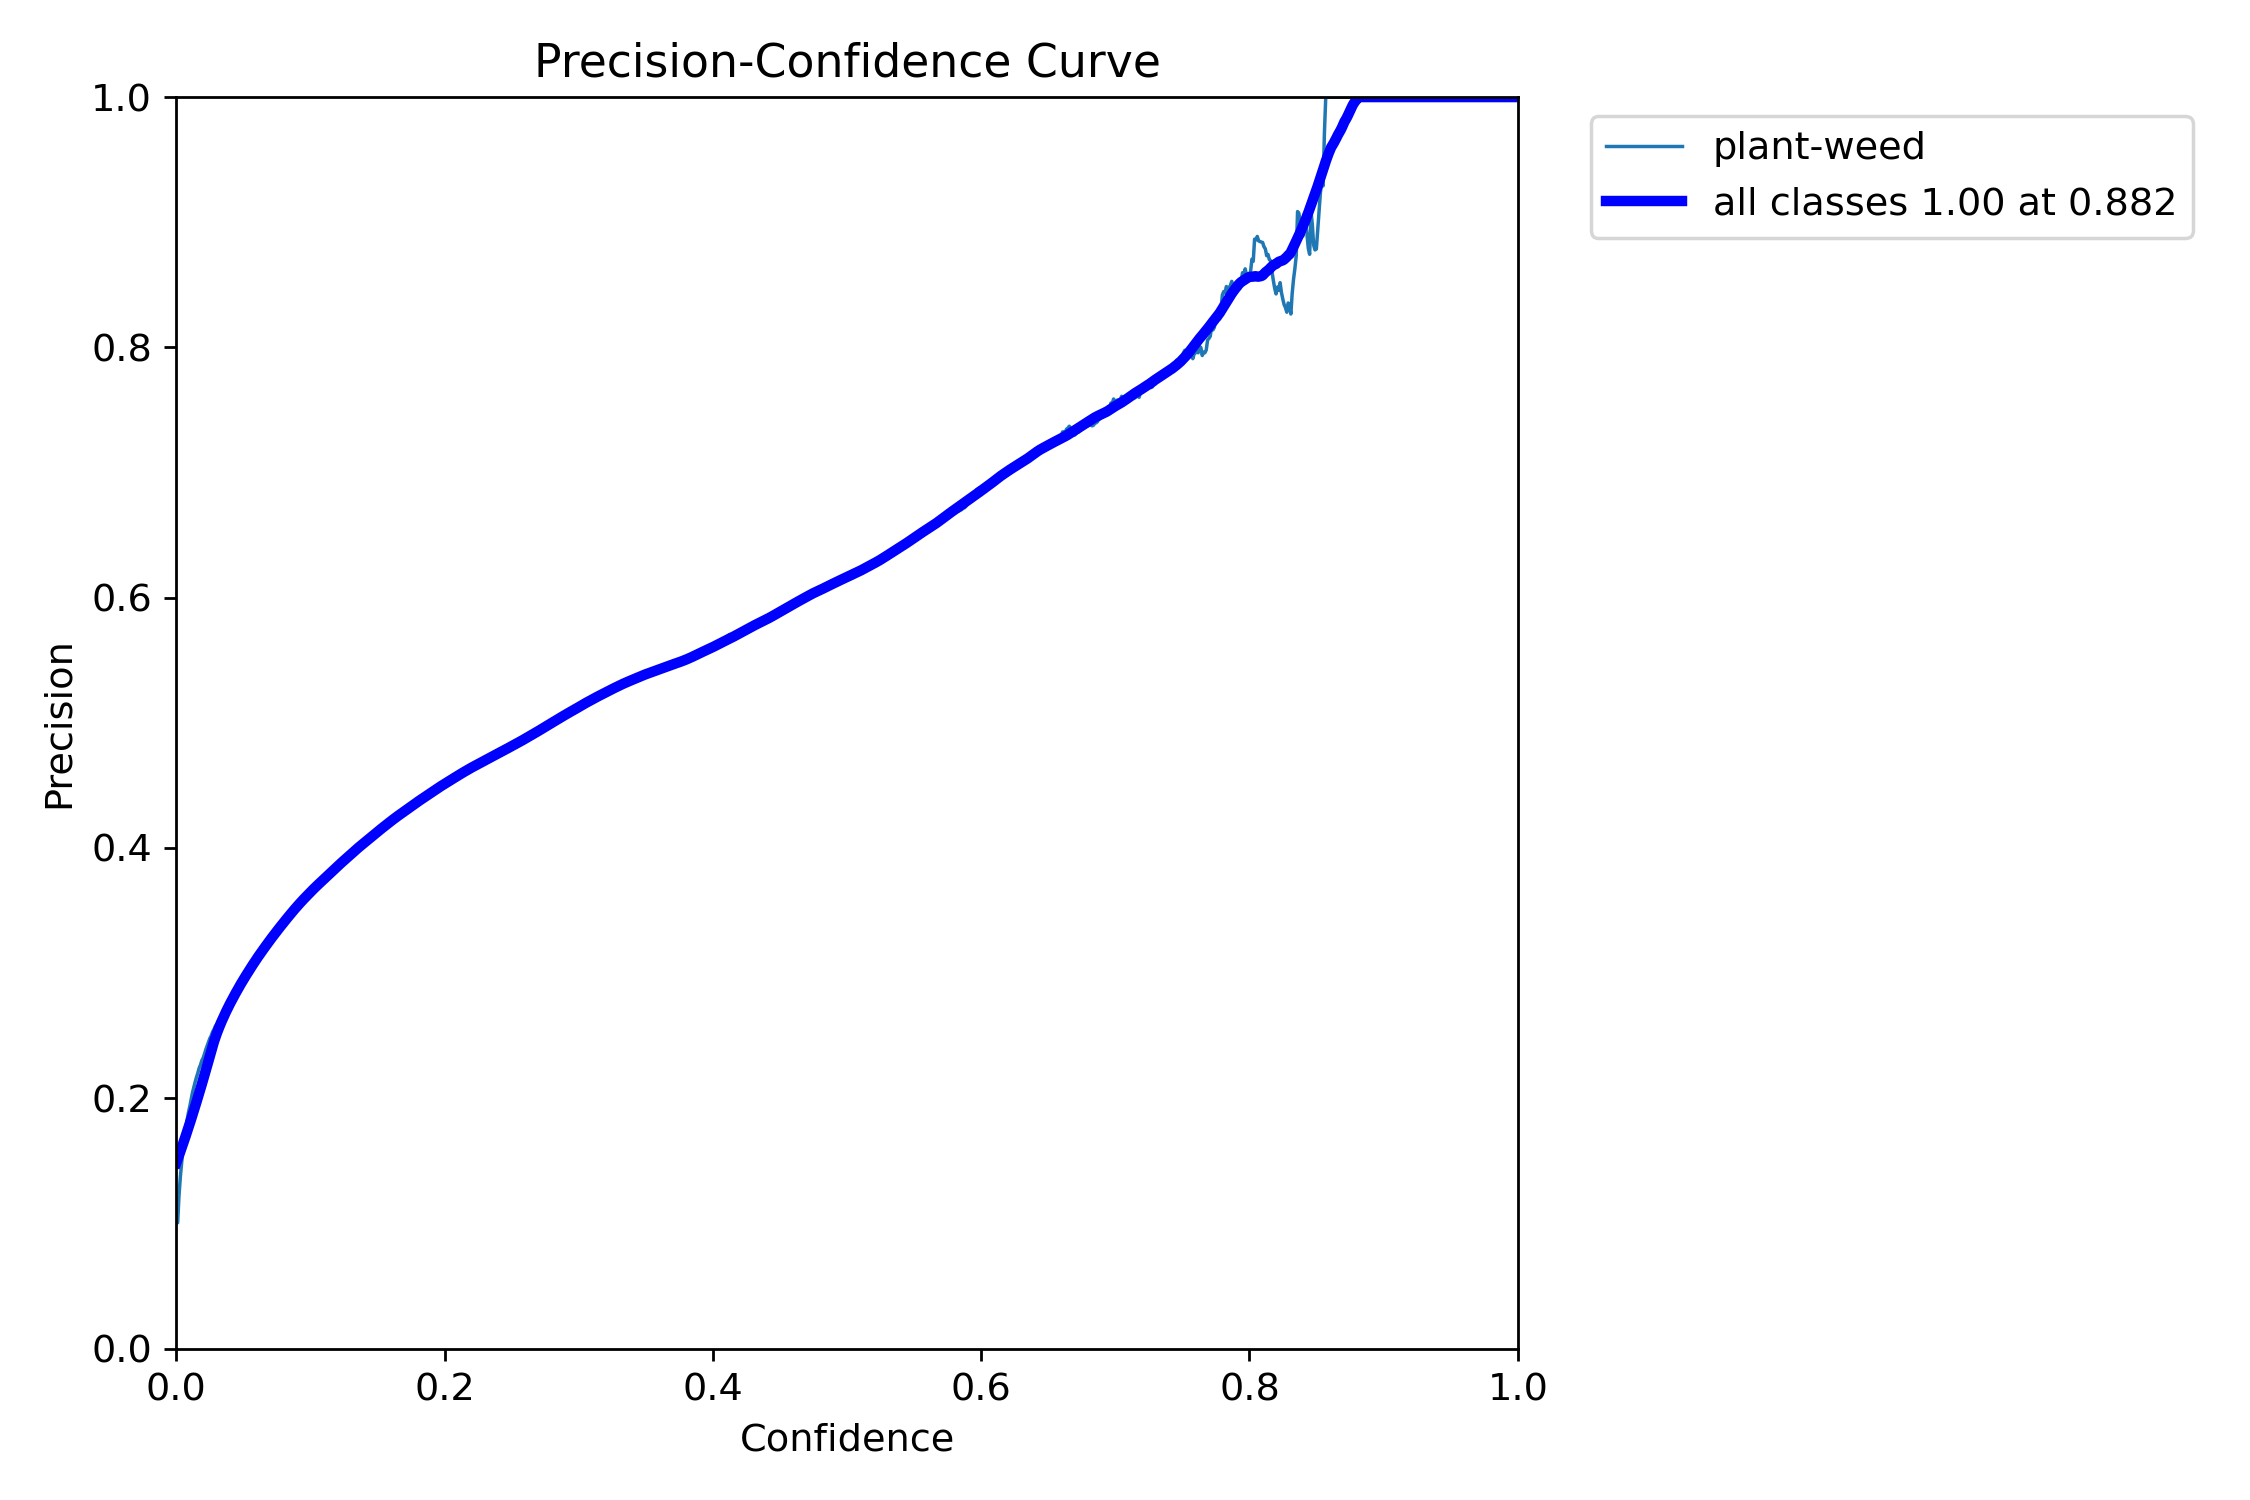

In [56]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

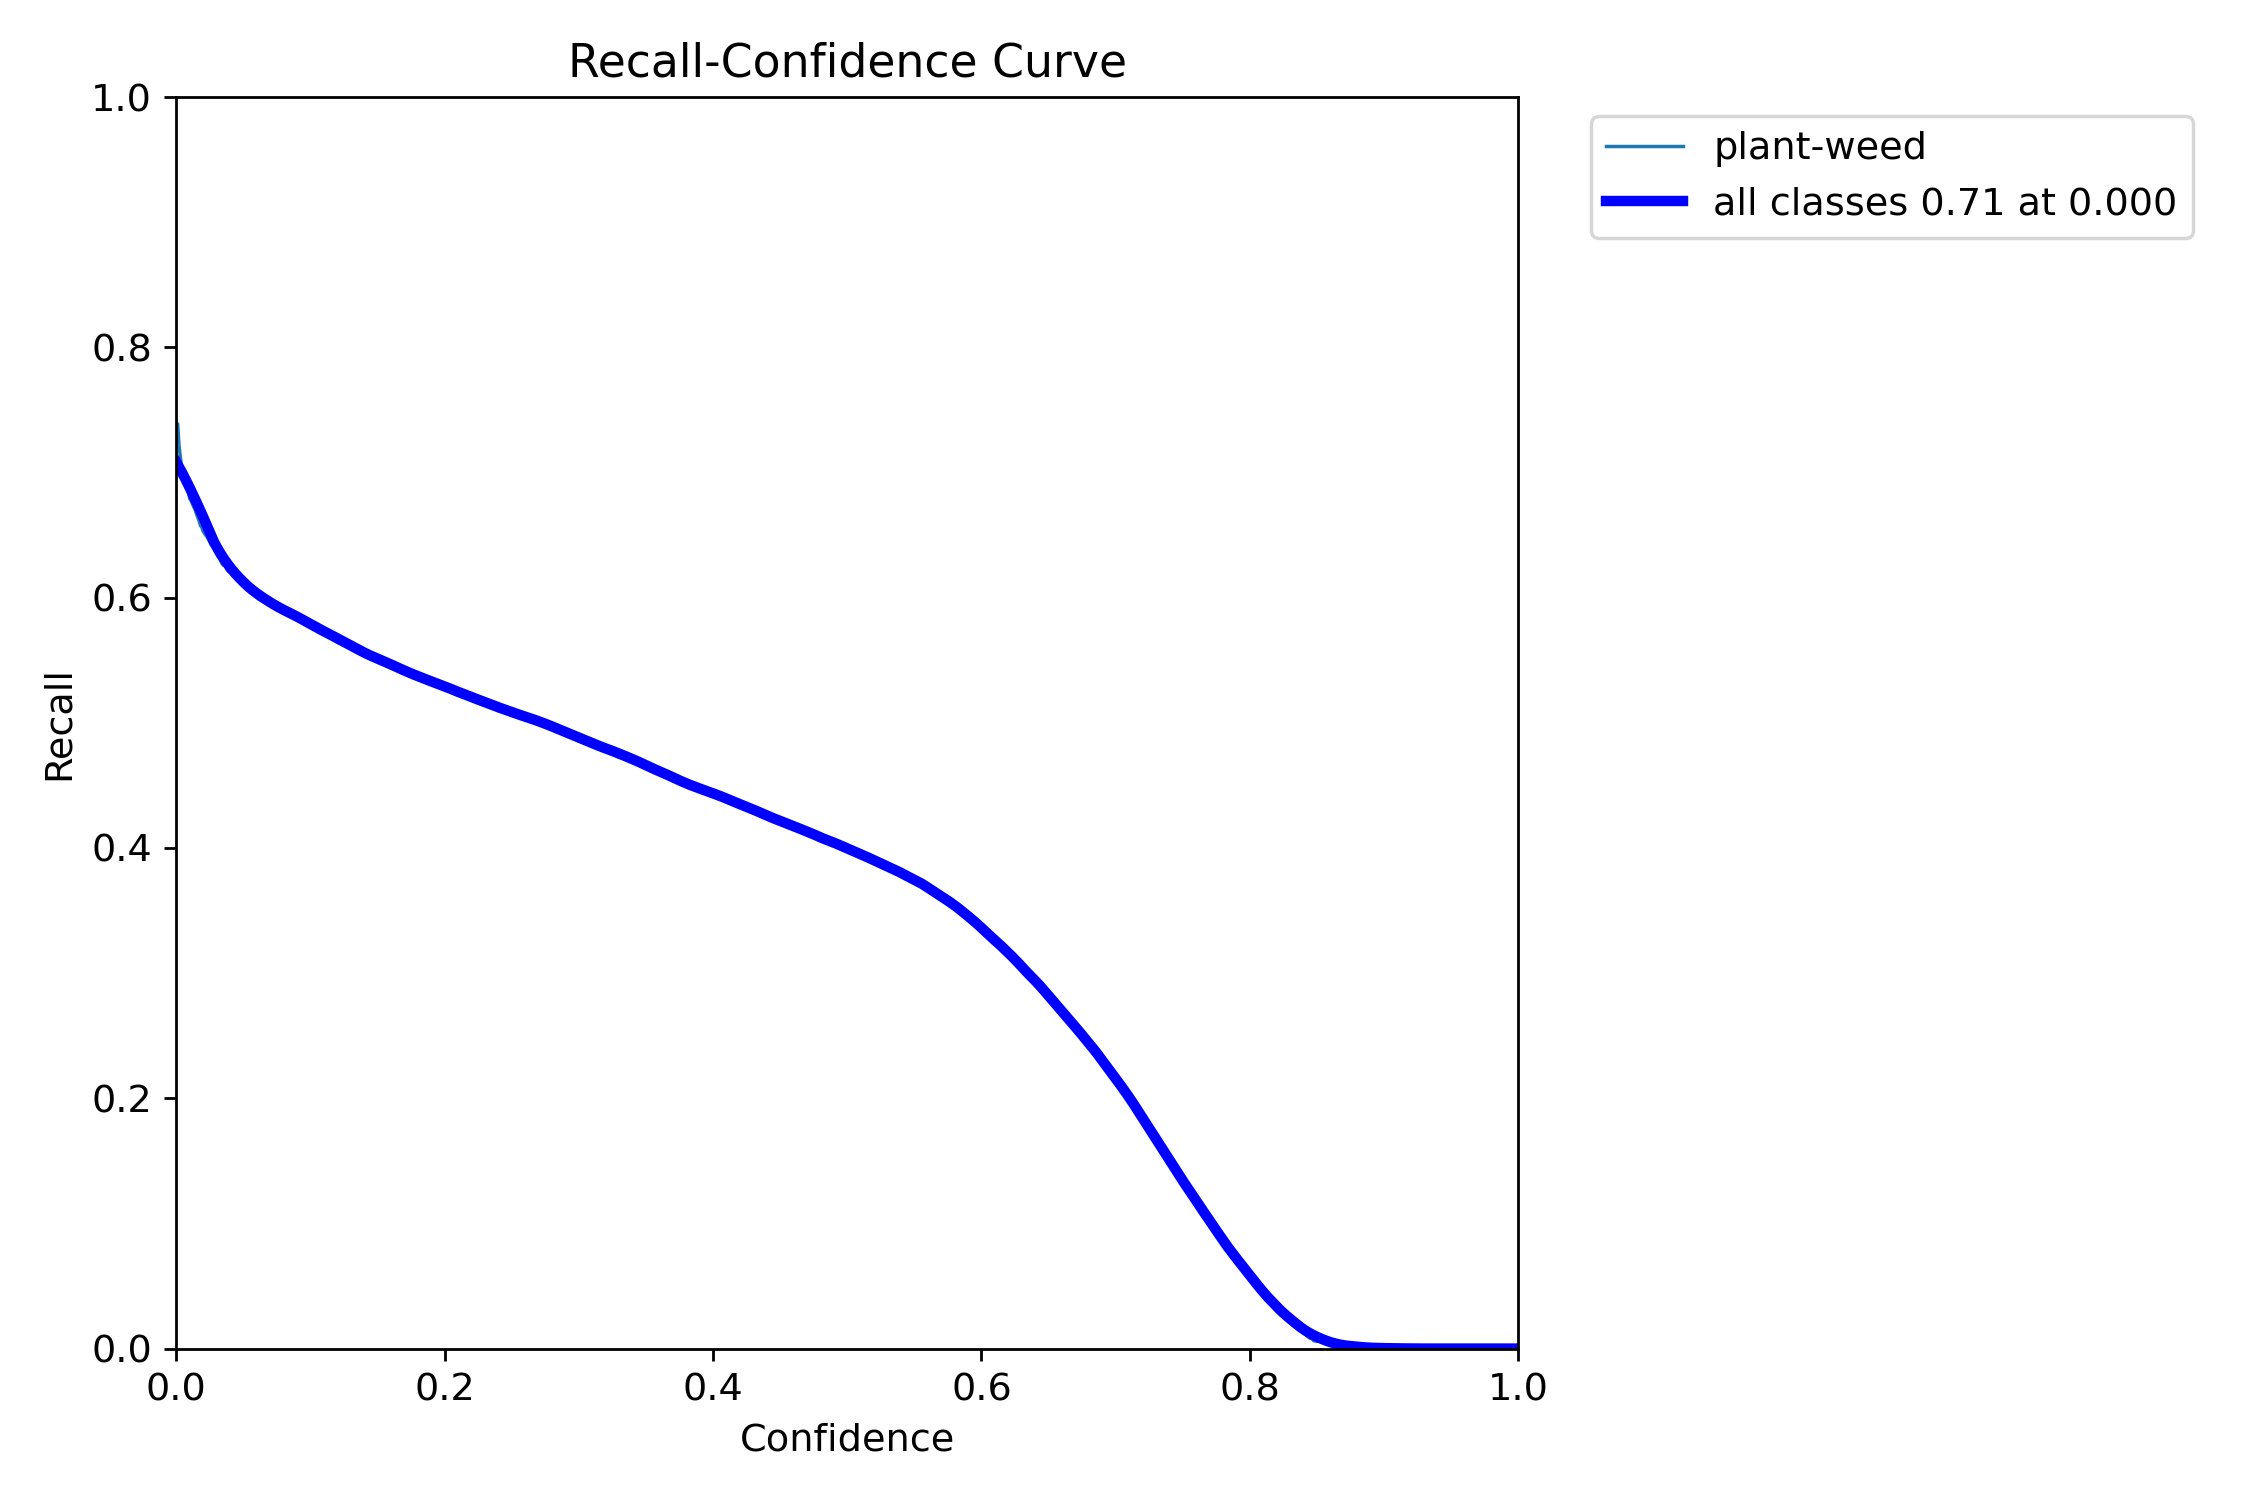

In [57]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

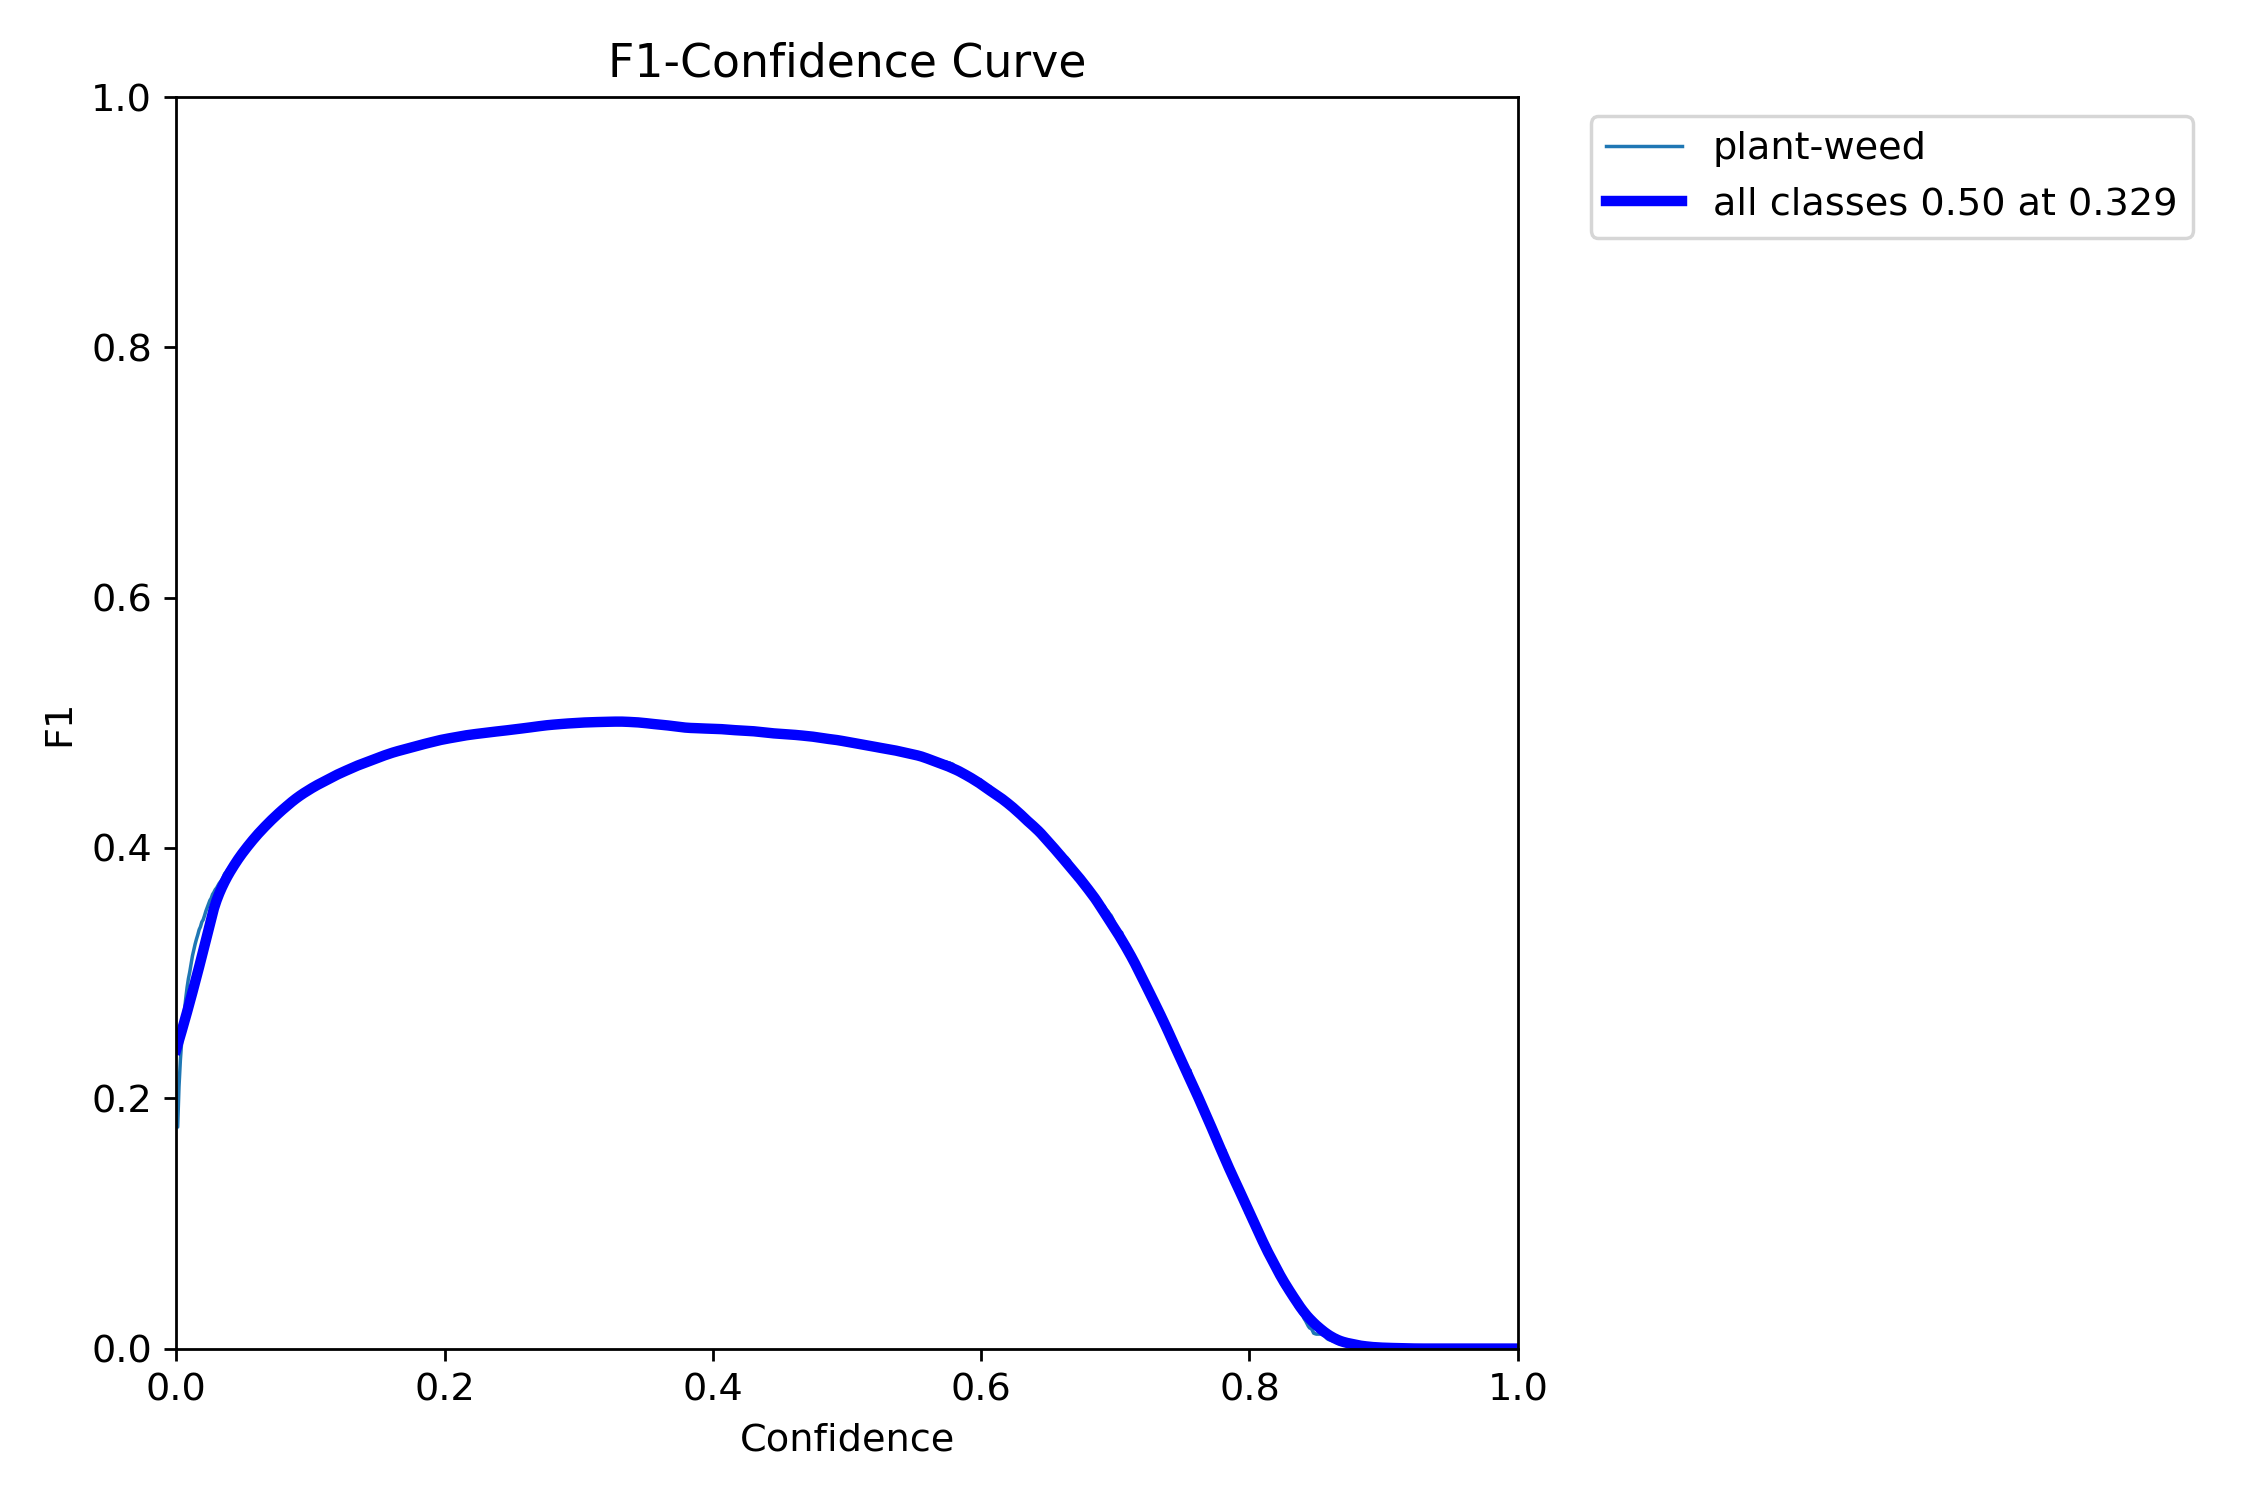

In [58]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

----

# Métricas generales

In [59]:
best_models.index = [f"{i}º TRAIN" for i in range(1, len(best_models)+1)]

In [60]:
best_models.sort_values(by='metrics/mAP50(B)', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
1º TRAIN,61,456.640,2.45698,1.89124,1.77849,0.41957,0.40722,0.35821,0.10947,2.38044,1.66311,1.55345,0.001762,0.001762,0.001762,61.749500
2º TRAIN,54,398.282,1.99676,1.25836,1.45897,0.51745,0.47406,0.44565,0.14513,2.32588,1.75765,1.53881,0.001790,0.001790,0.001790,60.348333
3º TRAIN,361,2792.500,1.20257,0.66073,1.00807,0.54572,0.48236,0.45092,0.14408,2.61832,1.37244,1.71799,0.001287,0.001287,0.001287,50.281833


## History Graphs

In [61]:
# Define function to plot metrics
def plot_metric(metric, ylabel, title):
    plt.figure(figsize=(15, 5))
    if len(best_models) < 1: print('ALERTA: No hay datos para realizar las gráficas.')
    if len(best_models) >= 1: plt.plot(df1["epoch"], df1[metric], label="Training 1", linestyle="--", marker="o", markersize=4)
    if len(best_models) >= 2: plt.plot(df2["epoch"], df2[metric], label="Training 2", linestyle="--", marker="s", markersize=4)
    if len(best_models) >= 3: plt.plot(df3["epoch"], df3[metric], label="Training 3", linestyle="--", marker="d", markersize=4)
    if len(best_models) >= 4: plt.plot(df4["epoch"], df4[metric], label="Training 4", linestyle="--", marker="^", markersize=4)
    if len(best_models) >= 5: plt.plot(df5["epoch"], df5[metric], label="Training 5", linestyle="--", marker="v", markersize=4)
    if len(best_models) >= 6: plt.plot(df6["epoch"], df6[metric], label="Training 6", linestyle="--", marker="p", markersize=4)
    if len(best_models) >= 7: print("La cantidad de modelos entrenados supera la configuración del gráfico, por favor ajustar la función 'plot_metric()'")
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Training and Validation Losses

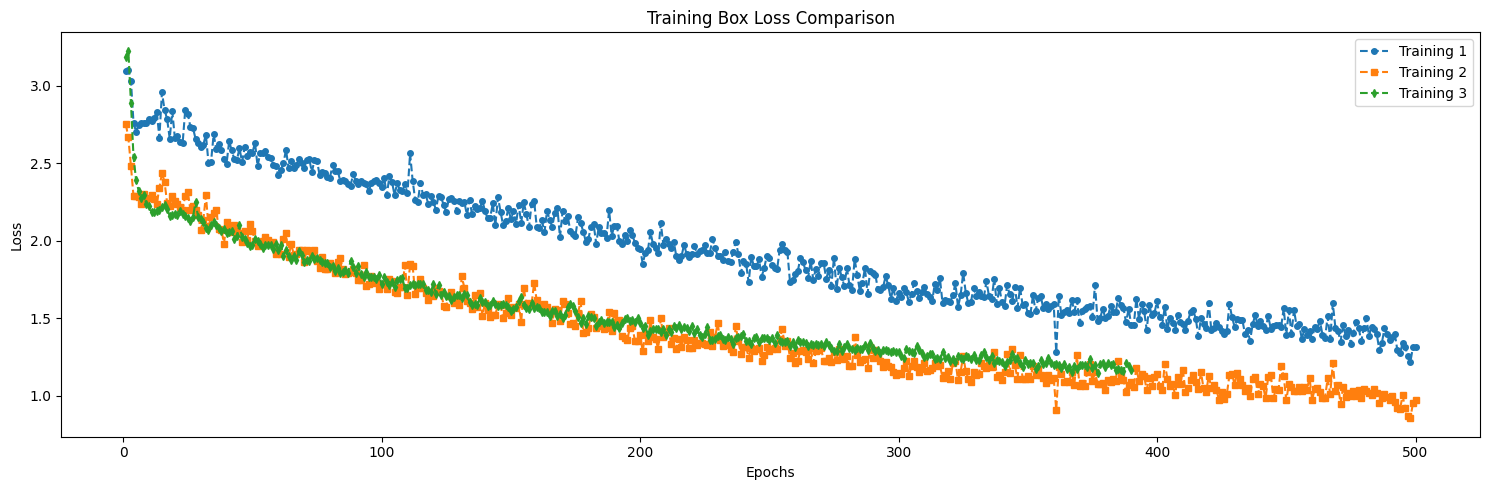

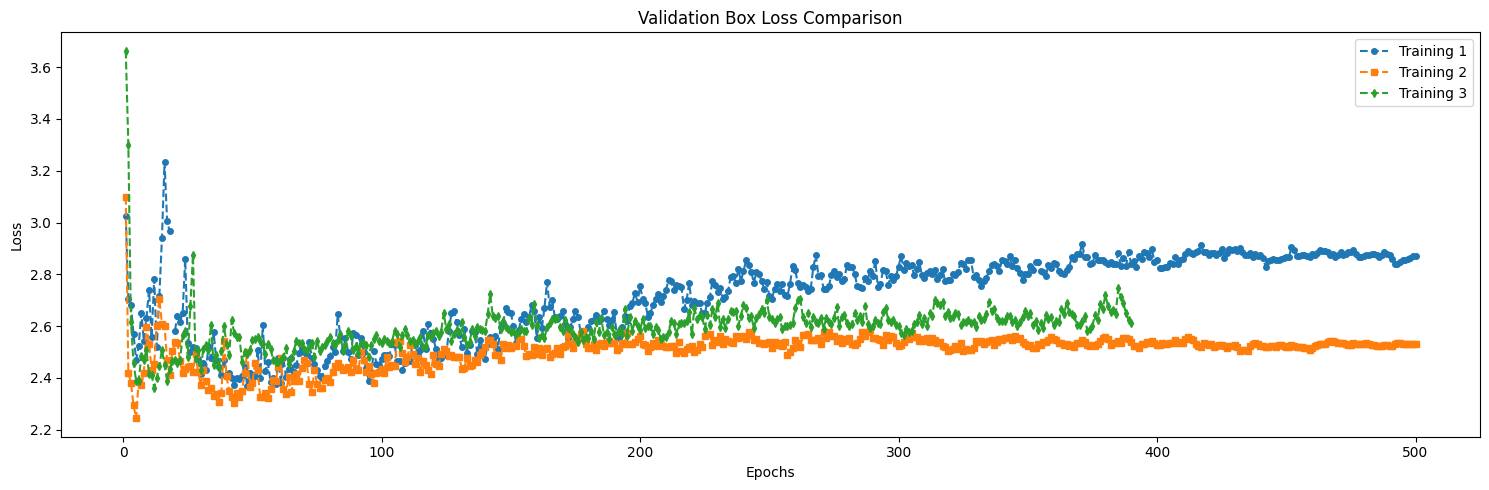

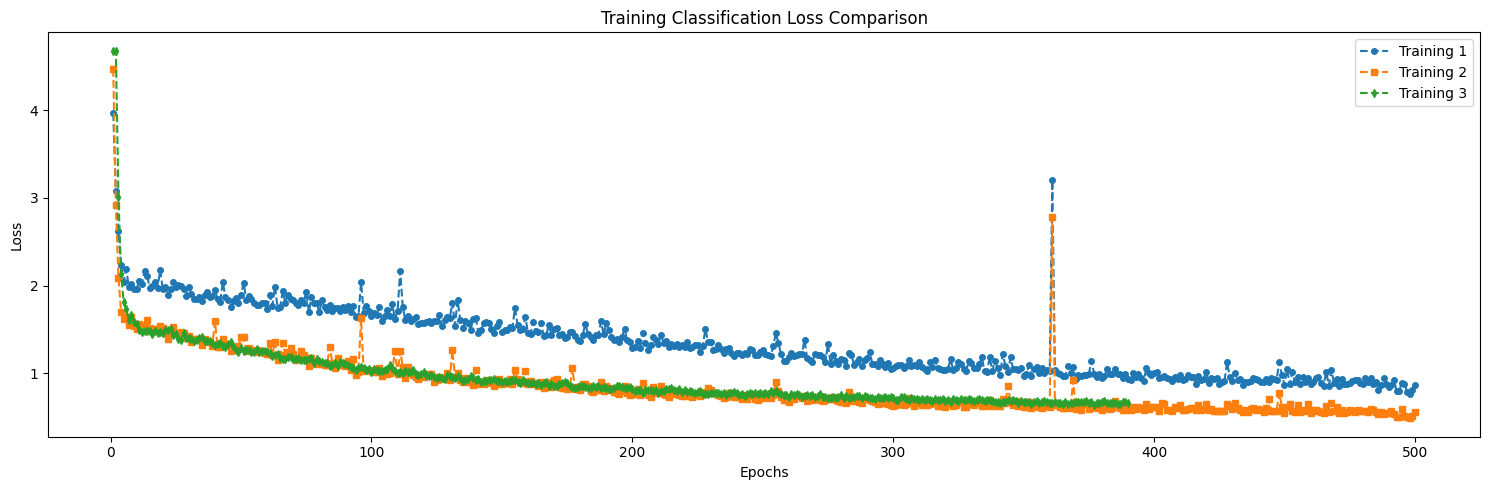

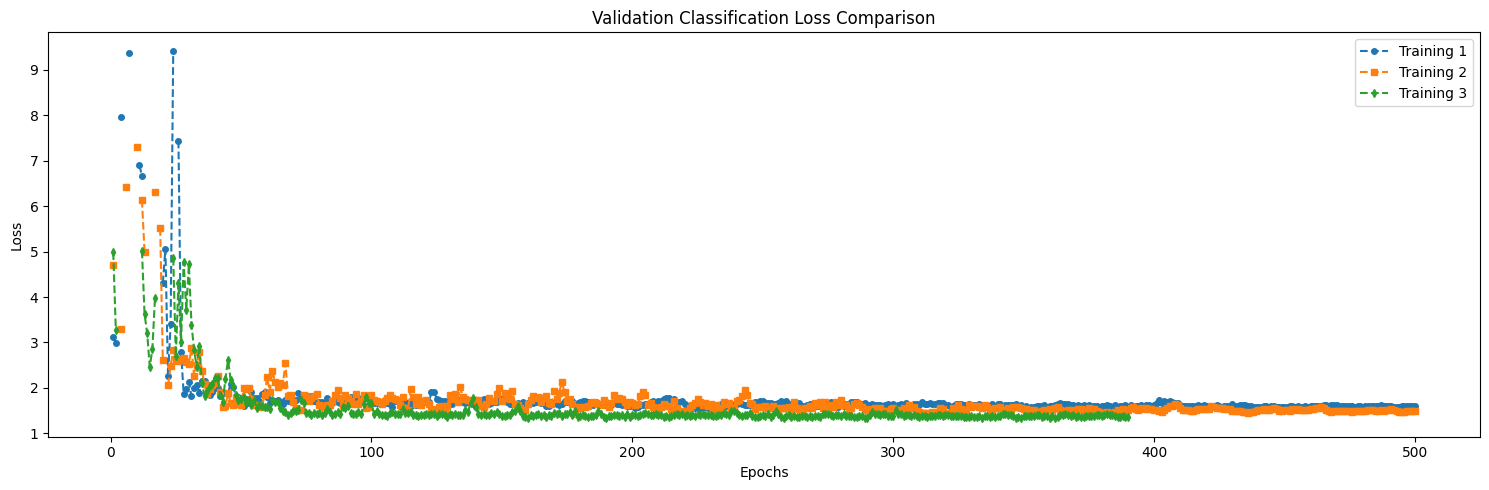

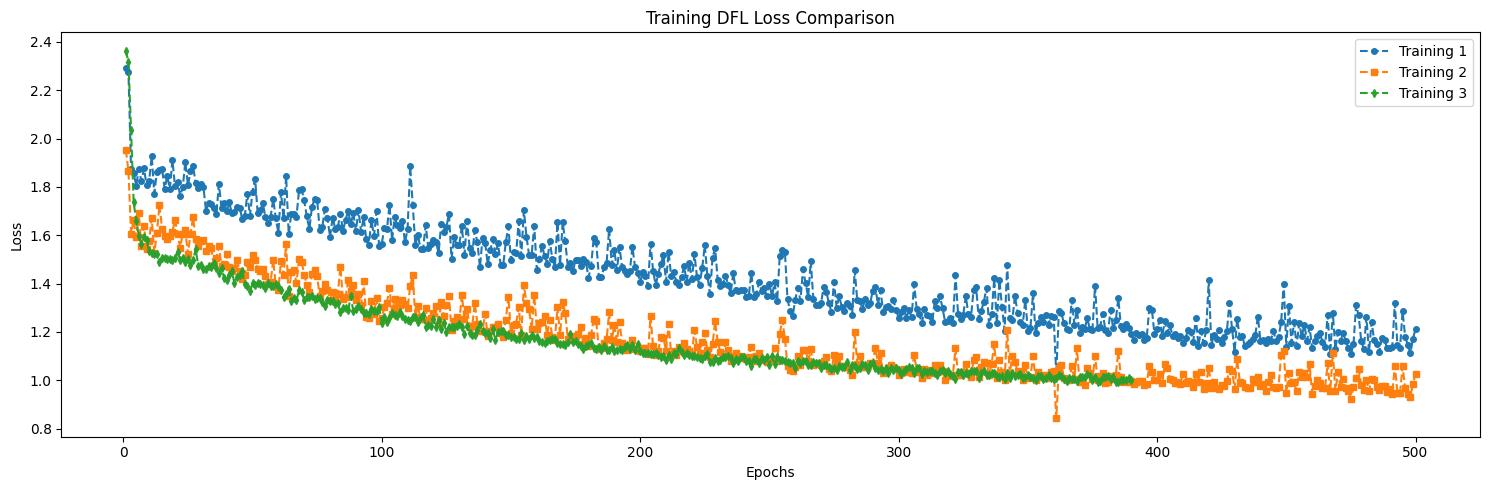

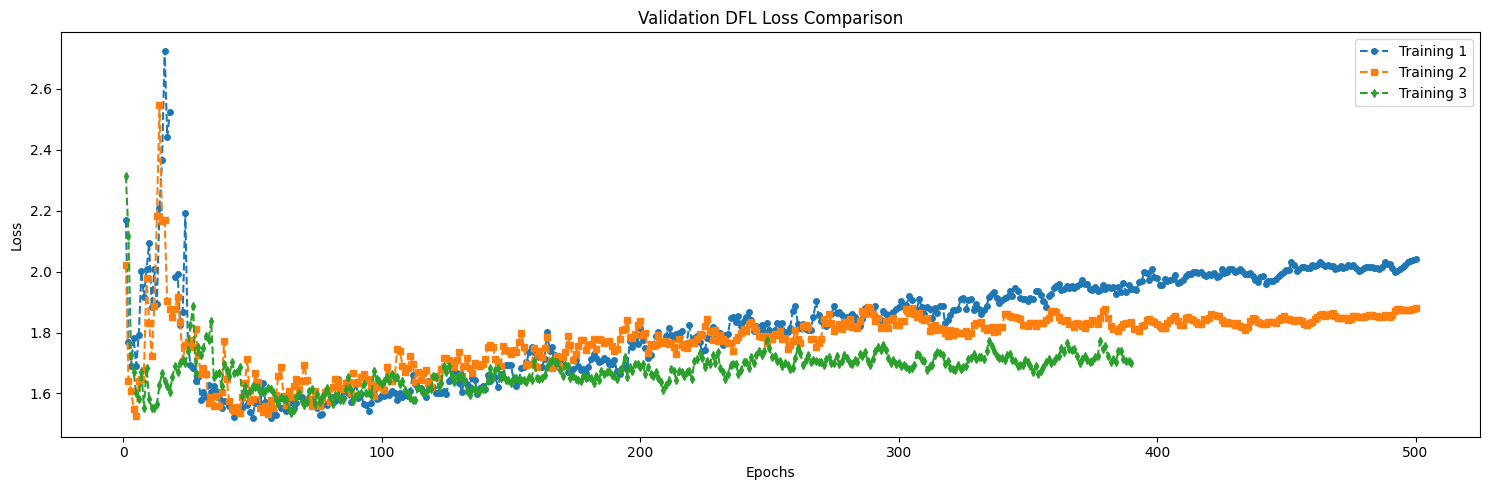

In [62]:
# Plot Training and Validation Losses
plot_metric("train/box_loss", "Loss", "Training Box Loss Comparison")
plot_metric("val/box_loss", "Loss", "Validation Box Loss Comparison")

plot_metric("train/cls_loss", "Loss", "Training Classification Loss Comparison")
plot_metric("val/cls_loss", "Loss", "Validation Classification Loss Comparison")

plot_metric("train/dfl_loss", "Loss", "Training DFL Loss Comparison")
plot_metric("val/dfl_loss", "Loss", "Validation DFL Loss Comparison")

### Performance Metrics

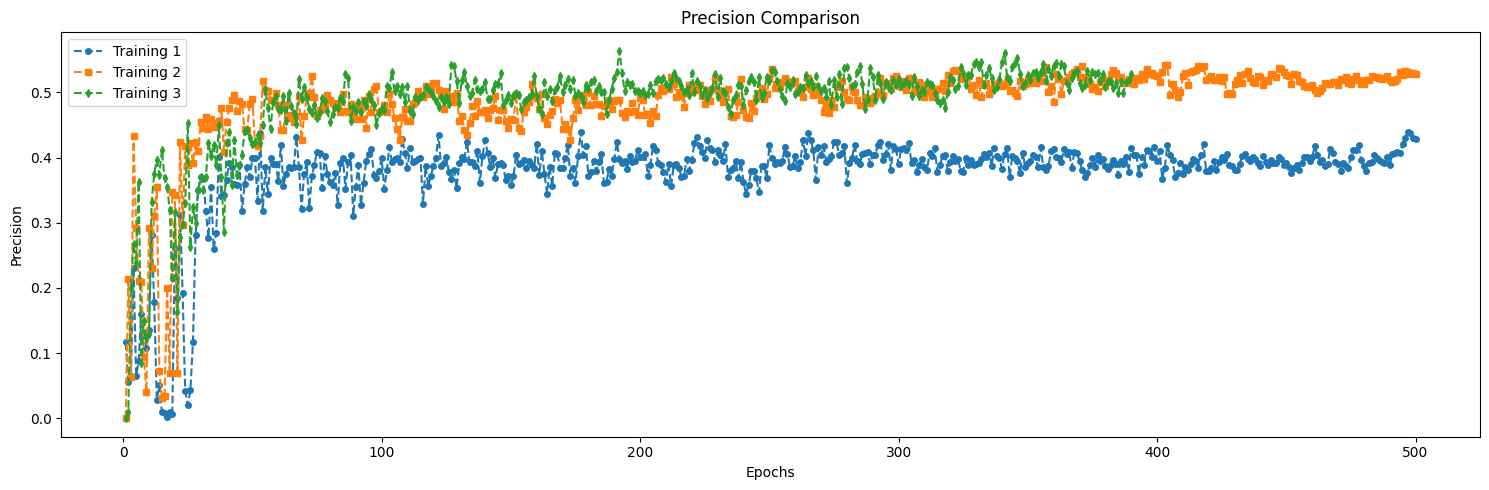

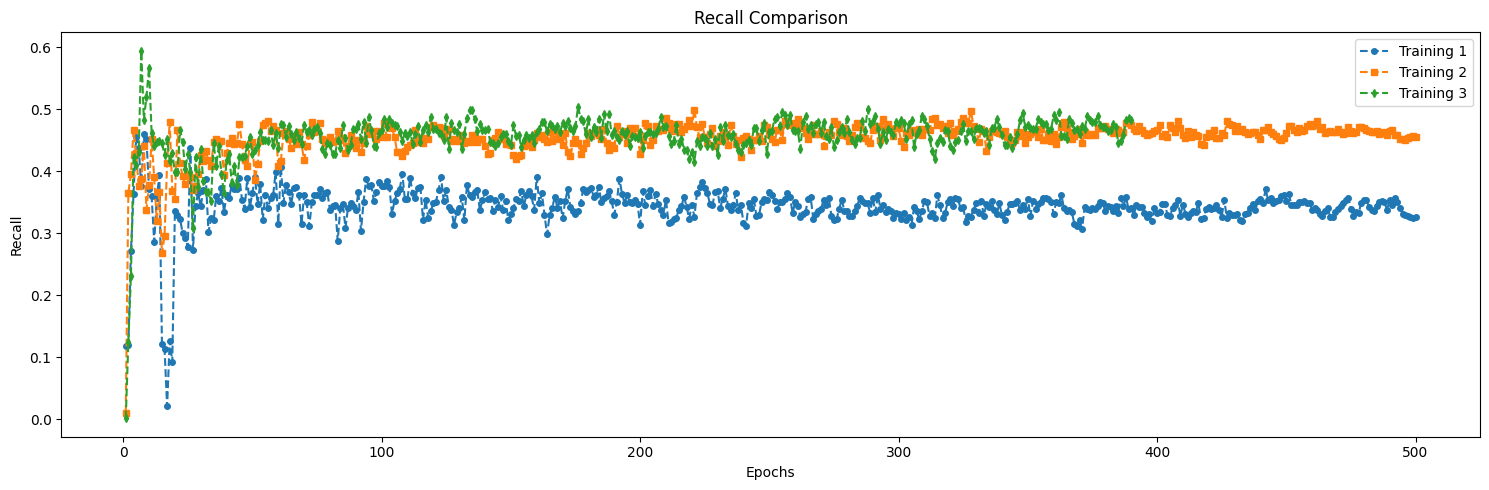

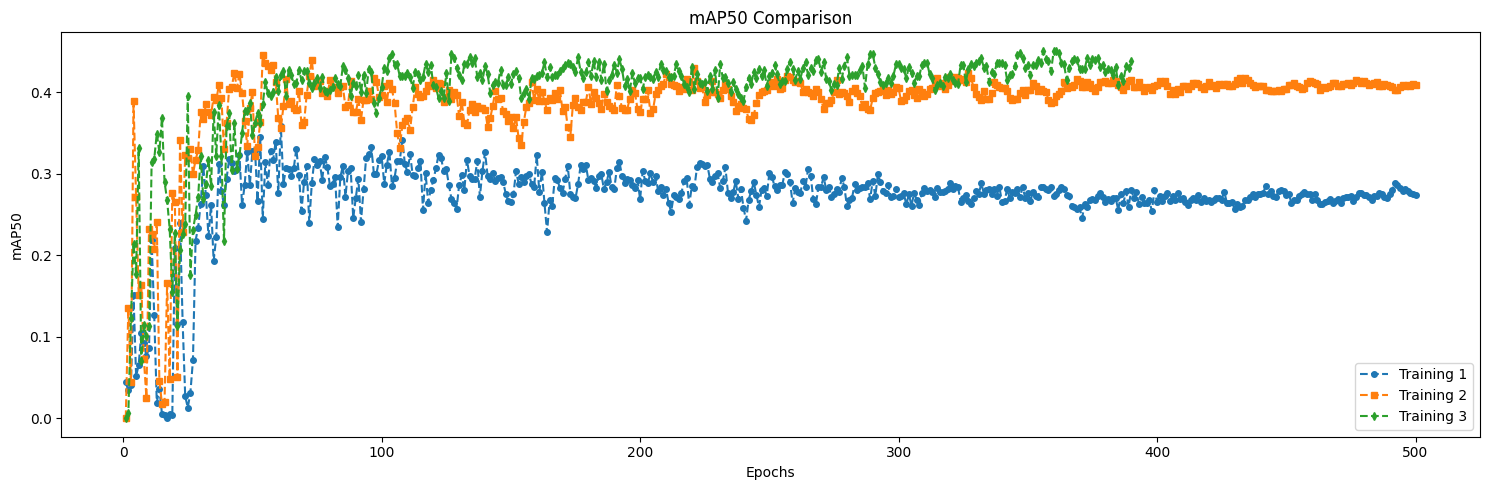

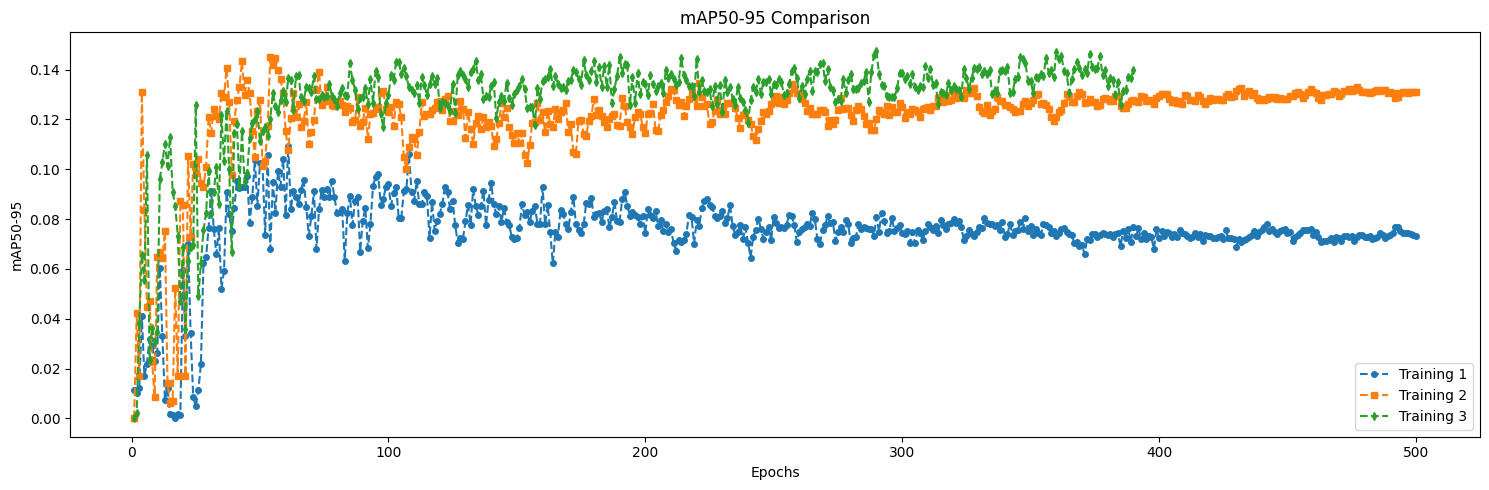

In [63]:
# Plot Performance Metrics
plot_metric("metrics/precision(B)", "Precision", "Precision Comparison")
plot_metric("metrics/recall(B)", "Recall", "Recall Comparison")
plot_metric("metrics/mAP50(B)", "mAP50", "mAP50 Comparison")
plot_metric("metrics/mAP50-95(B)", "mAP50-95", "mAP50-95 Comparison")

### Learning Rate

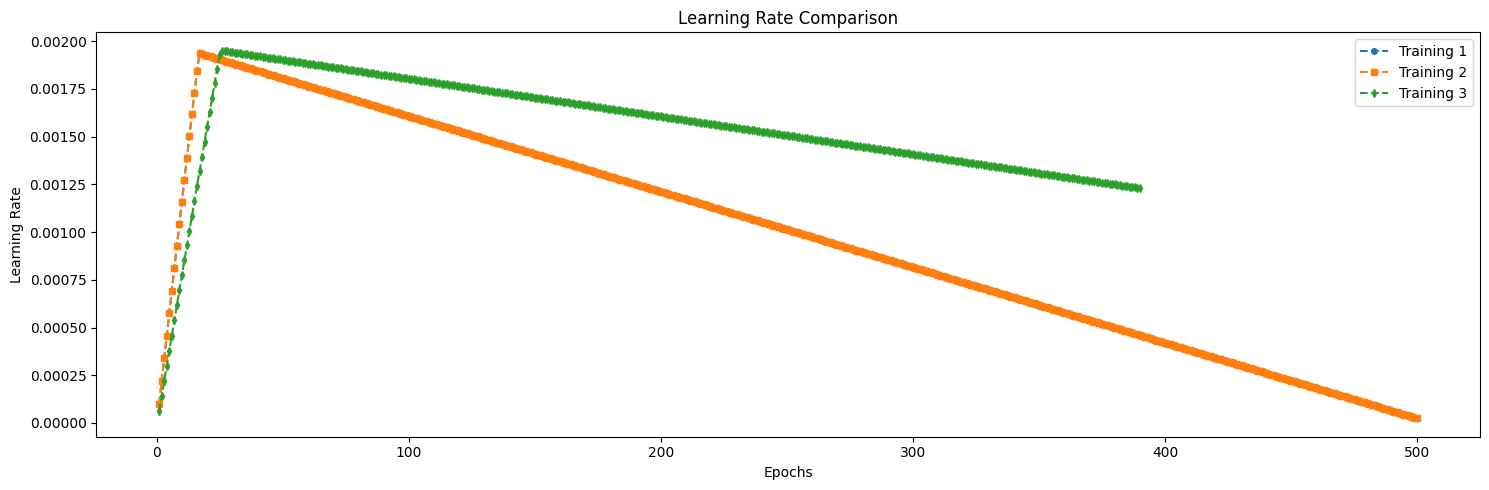

In [64]:
# Plot Learning Rate
plot_metric("lr/pg0", "Learning Rate", "Learning Rate Comparison")

## Comparative Graphs

In [65]:
#SETUP:
log_scale = False # Apply log scale to the y-axis

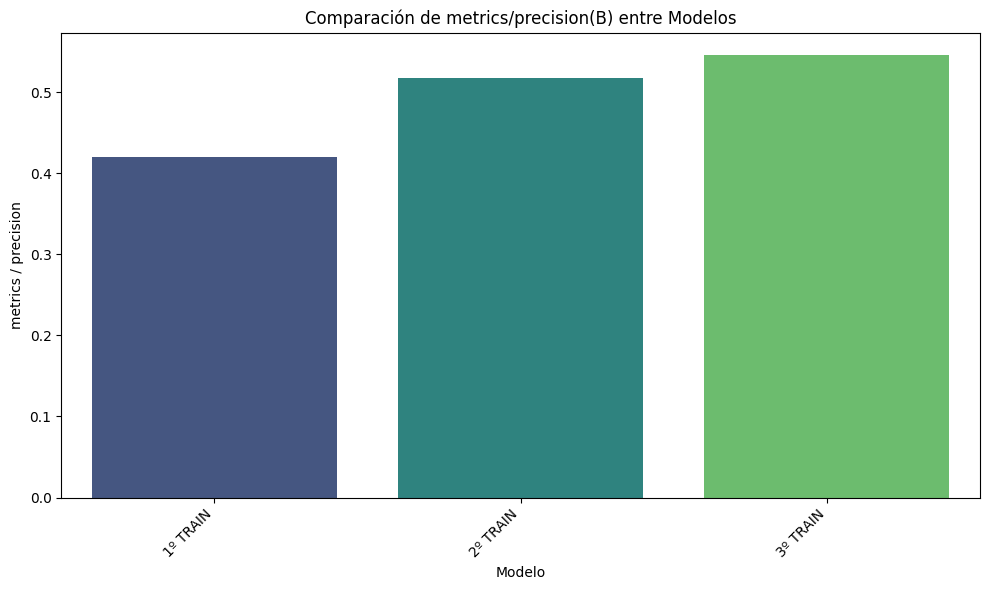

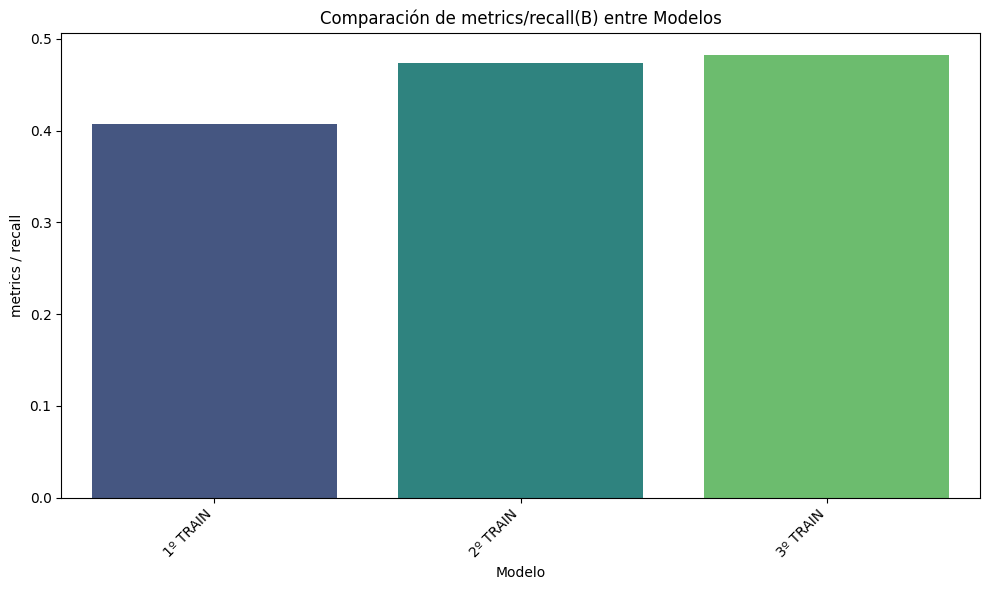

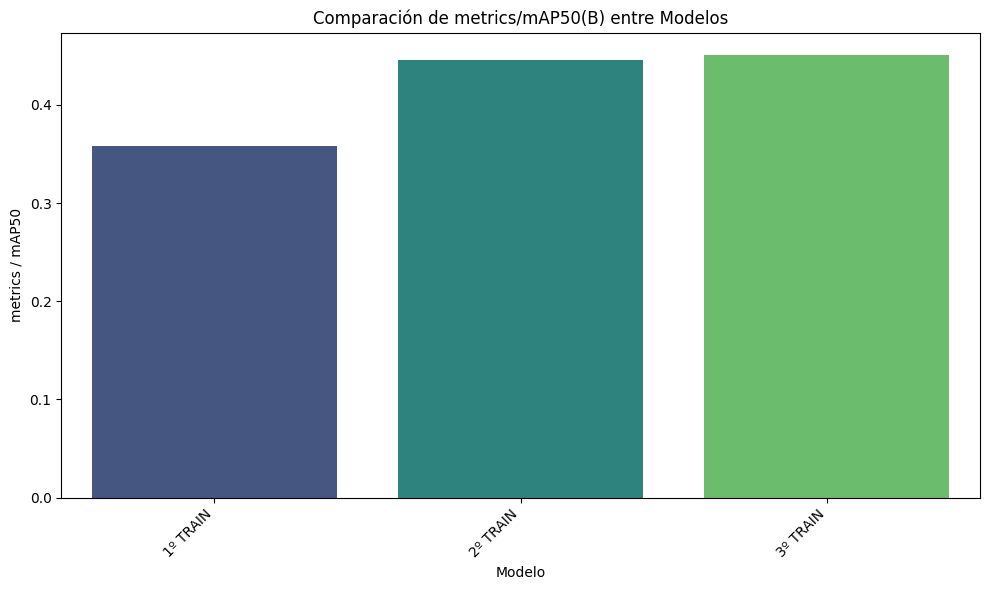

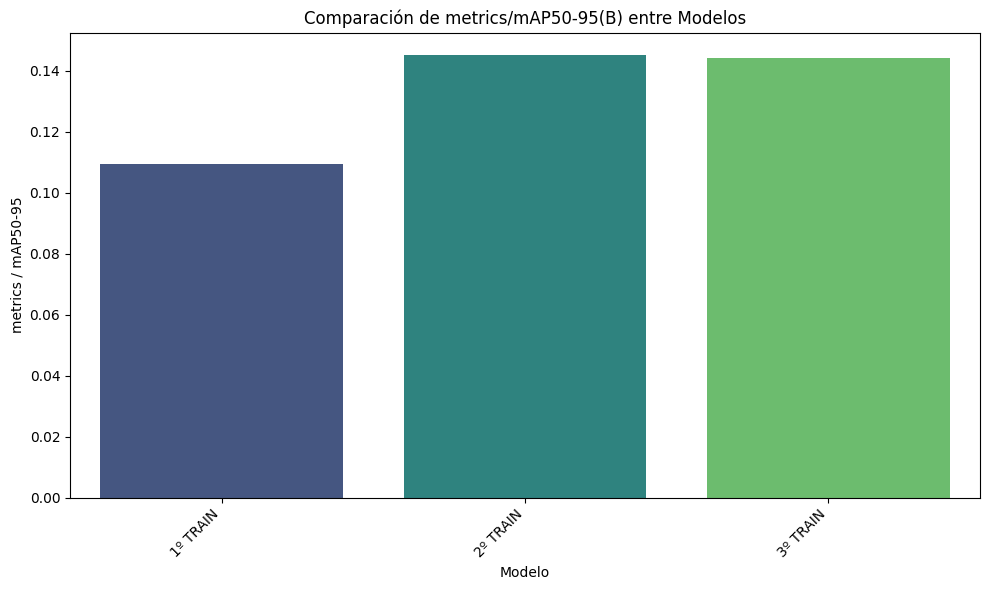

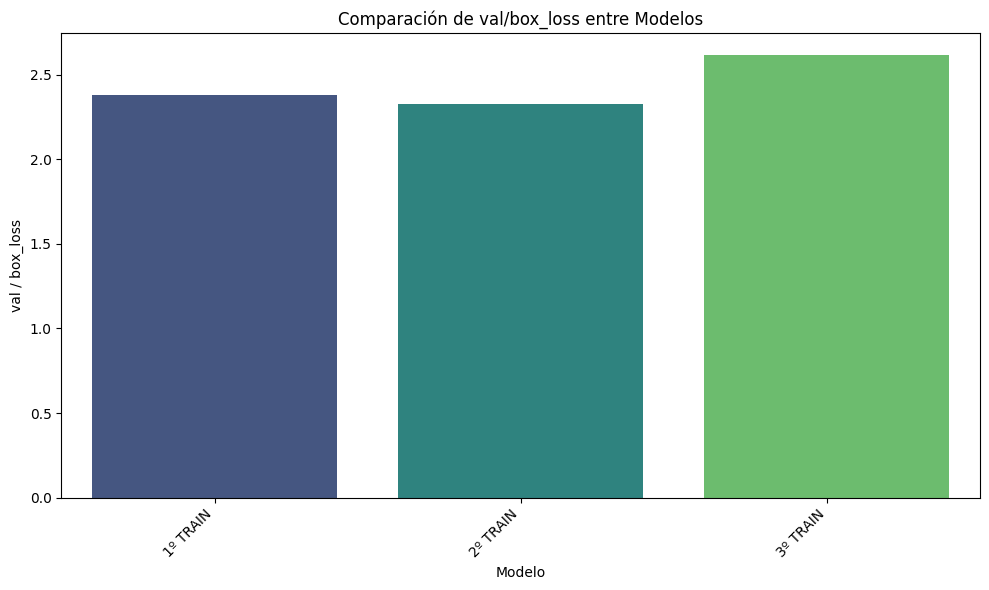

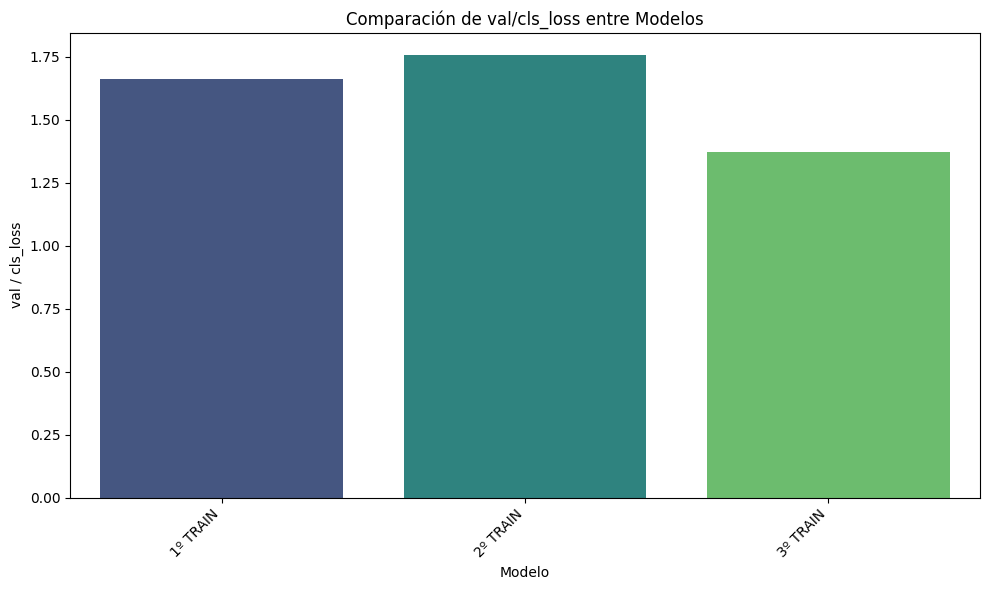

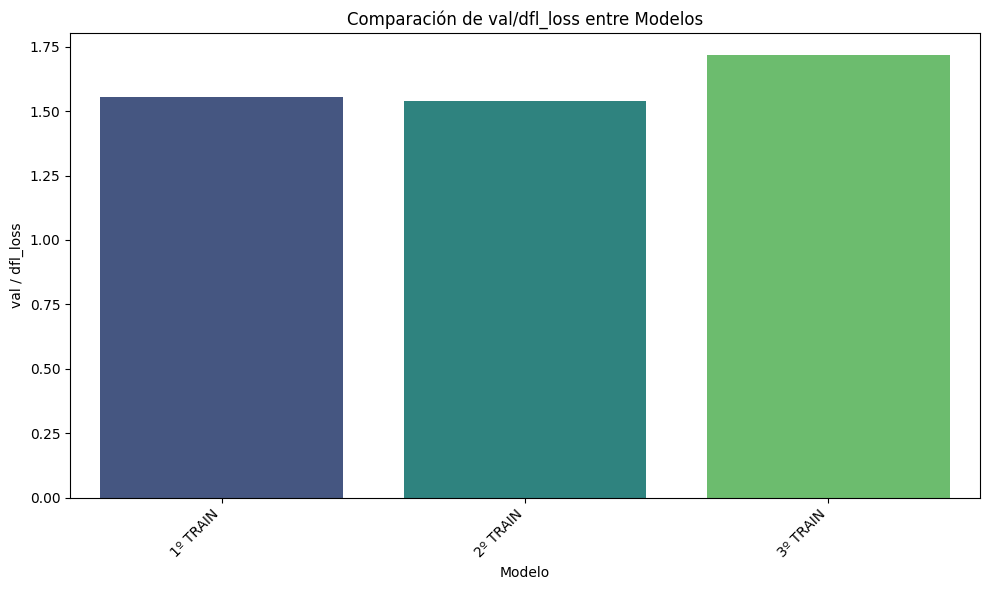

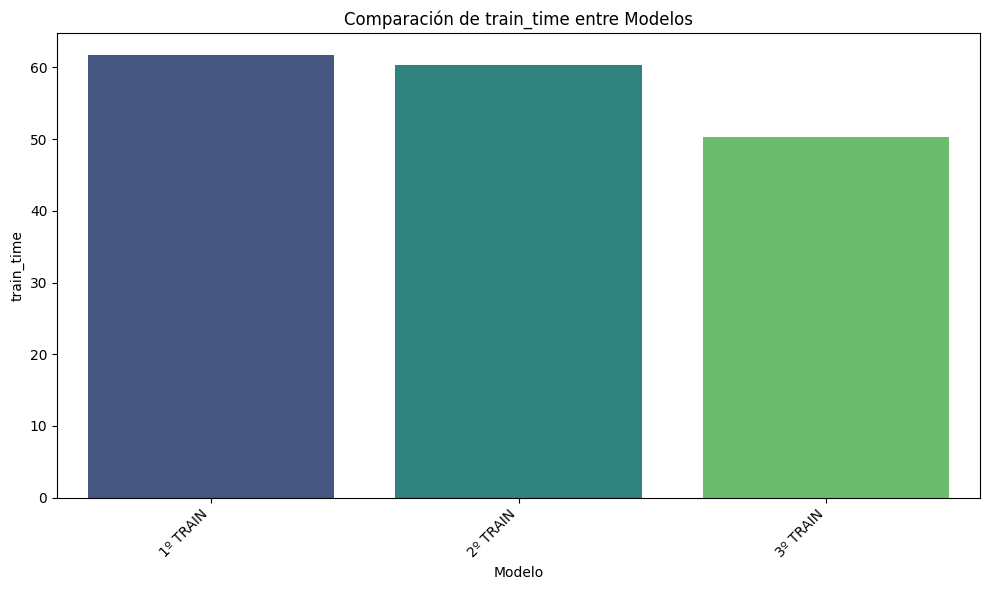

In [66]:
import seaborn as sns

metrics_to_plot = [
    'metrics/precision(B)',
    'metrics/recall(B)',
    'metrics/mAP50(B)',
    'metrics/mAP50-95(B)',
    'val/box_loss',
    'val/cls_loss',
    'val/dfl_loss',
    'train_time' # Tiempo de entrenamiento también puede ser interesante
]

# Filtramos las métricas que realmente existen en el DataFrame y no tienen todos los valores NaN
metrics_to_plot = [m for m in metrics_to_plot if m in best_models.columns and not best_models[m].isnull().all()]

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Preparamos el DataFrame para seaborn (opcional pero a veces útil)
# Usaremos el índice directamente en este caso.
df_plot = best_models.copy()
df_plot['Model'] = df_plot.index # Crea una columna 'Model' a partir del índice

# --- 3. Genera un gráfico de barras para cada métrica ---
# print(f"Generando gráficos para las métricas: {metrics_to_plot}")

for metric in metrics_to_plot:

    # Verificamos si la métrica tiene todos los valores NaN o cero
    if df_plot[metric].isnull().all() or (df_plot[metric] == 0).all():
        print(f"(*) Omitiendo gráfico para '{metric}' (todos los valores son NaN o cero).") # Warnings
        continue

    # Filtramos los modelos que tienen NaN o cero en la métrica actual
    omitted_rows = best_models[best_models[metric].isnull() | (best_models[metric] == 0)].index.tolist()
    df_plot = best_models[~best_models.index.isin(omitted_rows)].copy()
    df_plot['Model'] = df_plot.index  # Ensure the 'Model' column is preserved

    plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
    sns.barplot(x='Model', y=metric, data=df_plot, hue='Model', palette='viridis', dodge=False, legend=False)

    plt.yscale('log') if log_scale else None 
    plt.title(f'Comparación de {metric} entre Modelos')
    plt.xlabel('Modelo')
    plt.ylabel(metric.replace('(B)', '').replace('/', ' / '))  # Clean up the y-axis label
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if they are long
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

    if omitted_rows:
        print(f"- El modelo {', '.join(omitted_rows)} fue omitido para la métrica '{metric}' (tiene valores NaN o 0).")  # Warnings
    print("\n")

## Lollipop Graphs

In [67]:
#SETUP:
horizontal = False # Set to True for horizontal lollipop chart
log_scale = False # Apply log scale to the y-axis
sort = True # Sort values for better visual flow
sort_type = 'ascending' # Options: 'ascending', 'descending'

Orenamiento: ascending


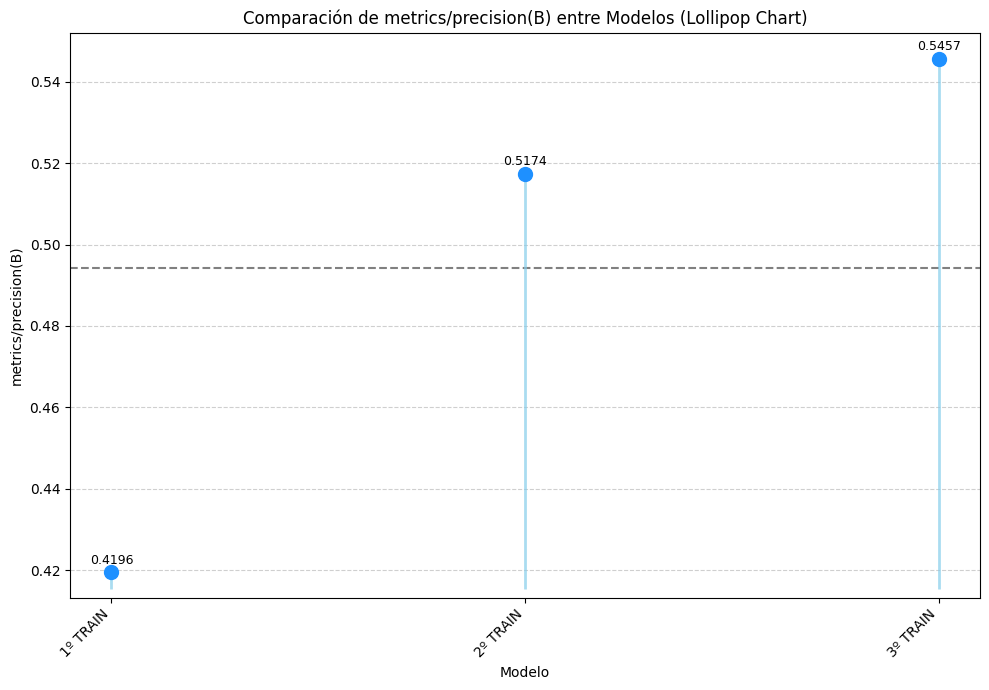

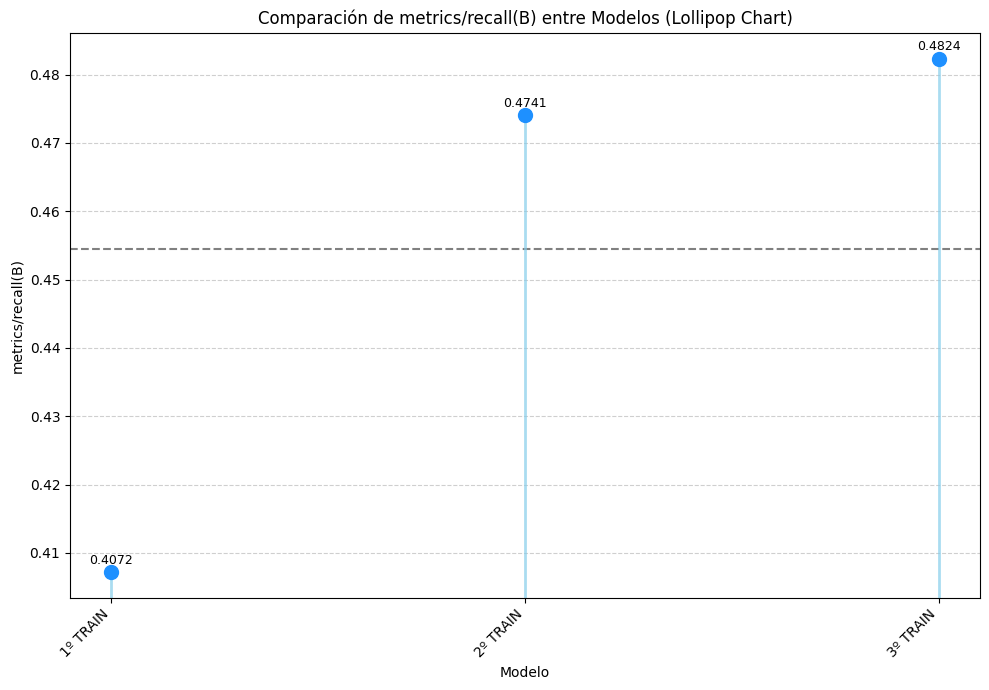

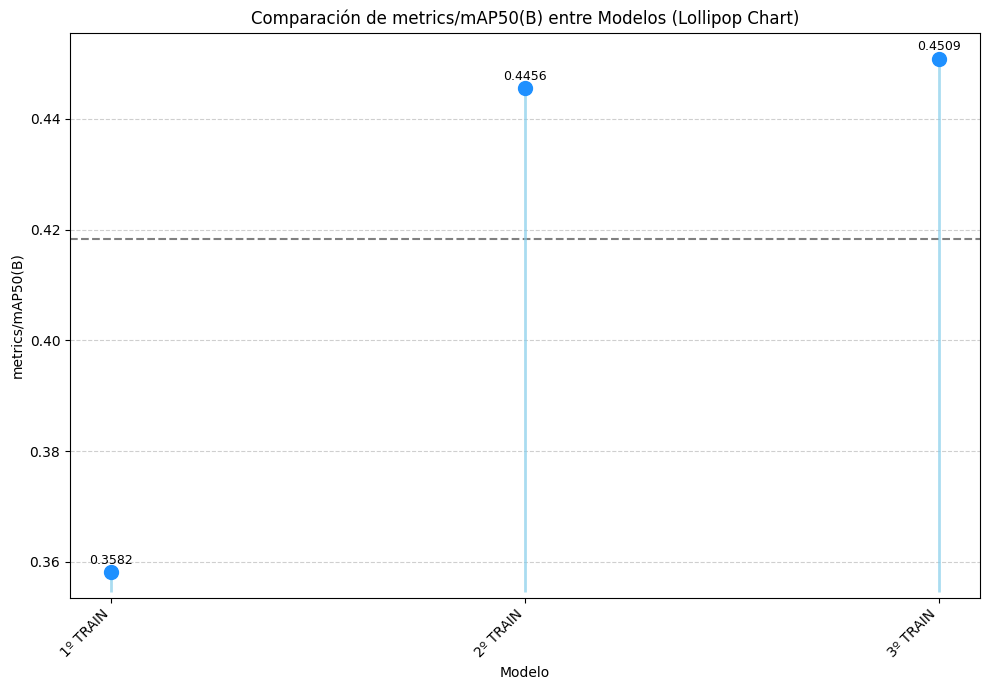

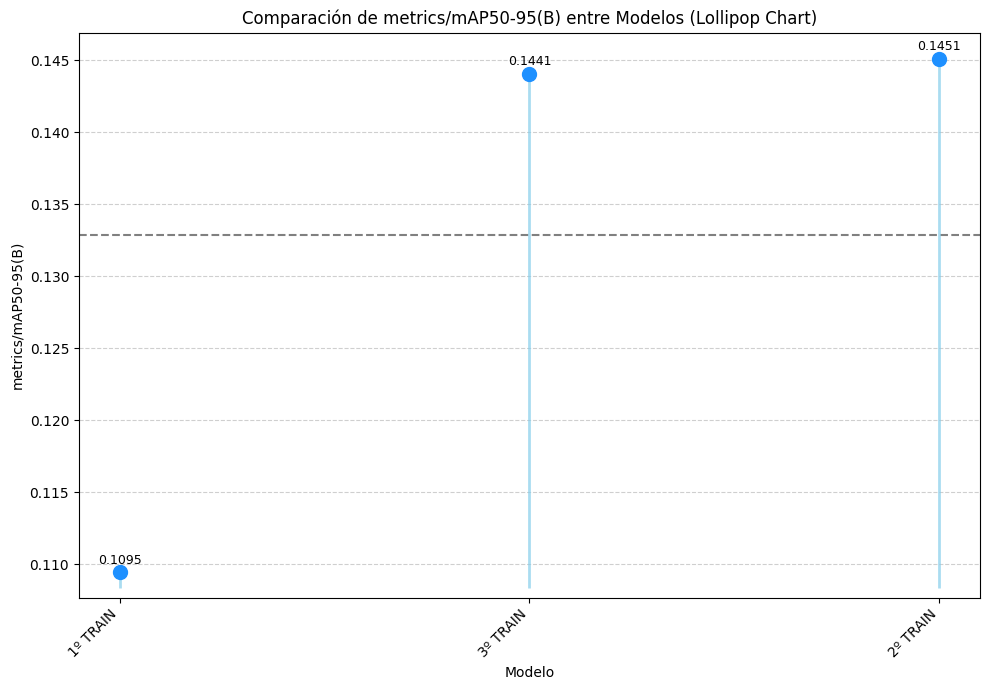

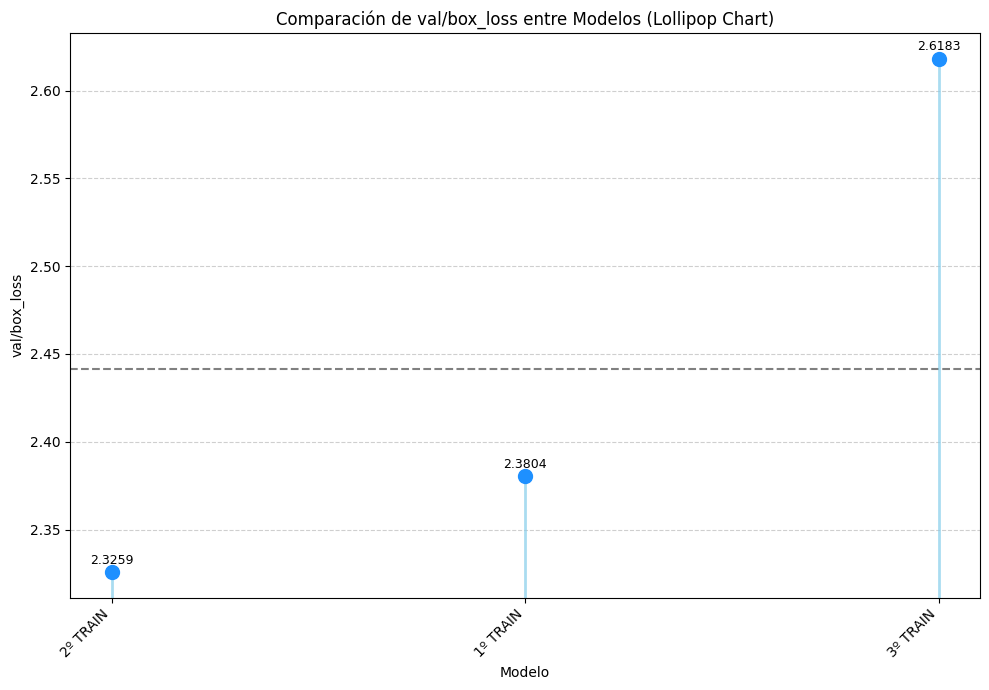

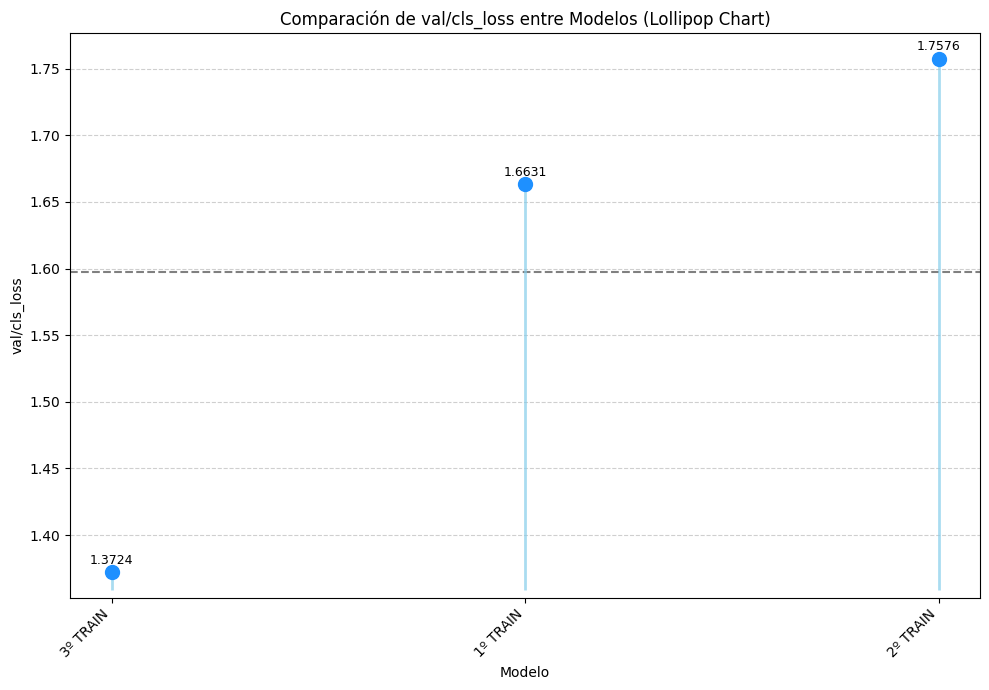

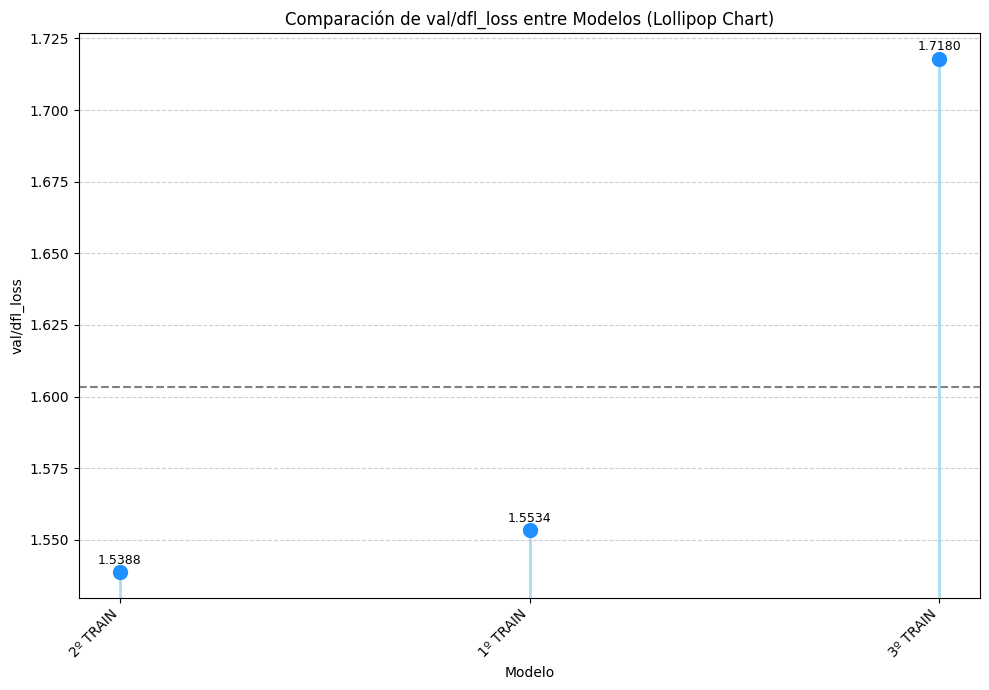

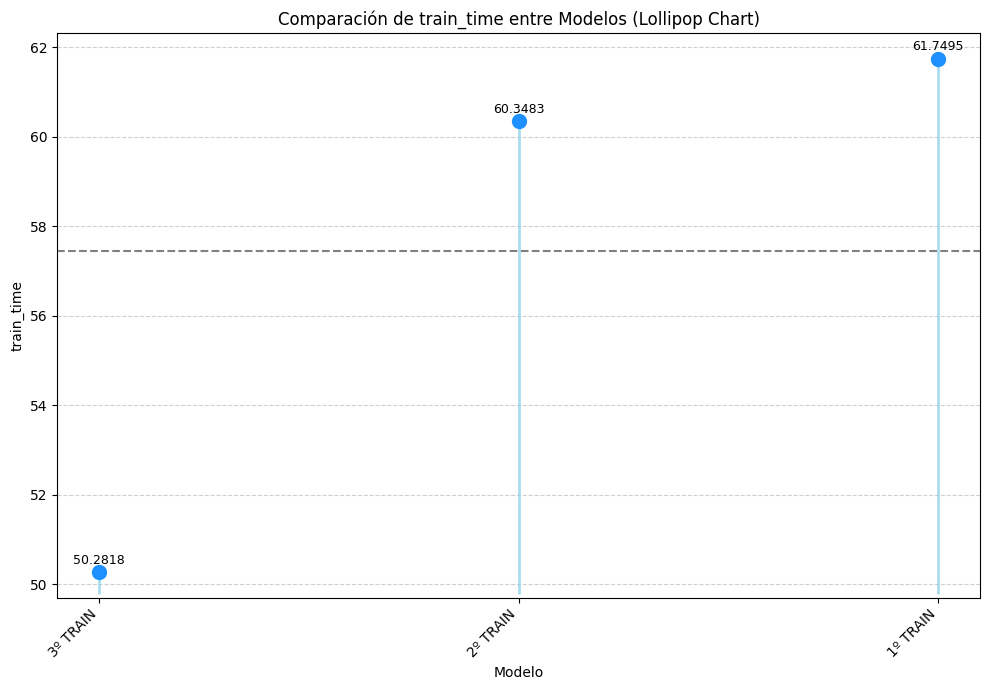

In [68]:
metrics_to_plot = [
    'metrics/precision(B)',
    'metrics/recall(B)',
    'metrics/mAP50(B)',
    'metrics/mAP50-95(B)',
    'val/box_loss',
    'val/cls_loss',
    'val/dfl_loss',
    'train_time' # Tiempo de entrenamiento también puede ser interesante
]

# Filtramos las métricas que realmente existen en el DataFrame y no tienen todos los valores NaN
metrics_to_plot = [m for m in metrics_to_plot if m in best_models.columns and not best_models[m].isnull().all()]

# Preparamos el DataFrame para seaborn (opcional pero a veces útil)
# Usaremos el índice directamente en este caso.
df_plot = best_models.copy()
df_plot['Model'] = df_plot.index # Crea una columna 'Model' a partir del índice

# --- 3. Genera un gráfico de barras para cada métrica ---
#print(f"Generando gráficos para las métricas: {metrics_to_plot}")
print(f"Orenamiento: {sort_type}") if sort else None

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

for  metric in metrics_to_plot:

    # Preparamos el DataFrame para seaborn (opcional pero a veces útil)
    # Usaremos el índice directamente en este caso.
    df_plot = best_models.dropna(subset=[metric]).copy()
    df_plot['Model'] = df_plot.index

    # Verificamos si la métrica tiene todos los valores NaN o cero
    if df_plot[metric].isnull().all() or (df_plot[metric] == 0).all():
        print(f"(*) Omitiendo gráfico para '{metric}' (todos los valores son NaN o cero).") # Warnings
        continue

    # Filtramos los modelos que tienen NaN o cero en la métrica actual
    omitted_rows = best_models[best_models[metric].isnull() | (best_models[metric] == 0)].index.tolist()
    df_plot = best_models[~best_models.index.isin(omitted_rows)].copy()
    df_plot['Model'] = df_plot.index  # Ensure the 'Model' column is preserved

    # Calculate the average value
    average_value = df_plot[metric].mean()

    # Sort values for potentially better visual flow (optional)
    if sort:
        match sort_type:
            case 'ascending':
                df_plot = df_plot.sort_values(by=metric, ascending=True)
            case 'descending':
                df_plot = df_plot.sort_values(by=metric, ascending=False)
            case _:
                print(f"Invalid sort type '{sort_type}'. No sorting applied.")

    plt.figure(figsize=(10, 7)) # Slightly taller figure might be nice

    # Define the y-values (the metric) and x-values (numerical index for models)
    values = df_plot[metric]
    axis = np.arange(len(df_plot)) # 0, 1, 2, ...

    # Determine the baseline for the stems (lines)
    # Start from slightly below the minimum value to emphasize differences
    plot_min_val = values.min()
    plot_max_val = values.max()
    stem_baseline = plot_min_val * 0.99 # Start stems just below the minimum point
    margin = (plot_max_val - plot_min_val) * 0.05 # Adjust y-axis limits for zoom, adding a margin

    if not horizontal:
        # --- Create the Lollipop Plot ---
        plt.yscale('log') if log_scale else None # Apply log scale to y-axis for vertical plot
        plt.ylim(max(0, plot_min_val - margin), plot_max_val + margin) # Ensure y_min not negative if data positive
    
        # Add average line
        plt.axhline(y=average_value, color='gray', linestyle='--', label=f'Promedio: {average_value:.4f}')

        # Create the 'stems' (vertical lines)
        plt.vlines(x=axis, ymin=stem_baseline, ymax=values, color='skyblue', alpha=0.7, linewidth=2)

        # Create the 'lollipops' (the dots at the top)
        plt.scatter(x=axis, y=values, color='dodgerblue', s=100, alpha=1, zorder=3) # zorder=3 makes dots appear on top

        # Add value labels next to the dots
        for i, txt in enumerate(values):
            plt.text(axis[i], values.iloc[i] + (plot_max_val - plot_min_val) * 0.01, # Position label slightly above dot
                    f'{txt:.4f}', # Format the number
                    ha='center', # Horizontal alignment
                    va='bottom', # Vertical alignment
                    fontsize=9)

        # Customize the plot
        plt.xlabel('Modelo')
        plt.ylabel(metric)

        # Set the x-axis ticks to be the model names
        plt.xticks(axis, df_plot['Model'], rotation=45, ha='right')

        # Add a light grid for easier comparison
        plt.grid(axis='y', linestyle='--', alpha=0.6)


    if horizontal:
        # --- Horizontal Lollipop (Alternative) ---
        plt.xscale('log') if log_scale else None # Apply log scale to x-axis for horizontal plot
        plt.xlim(max(0, plot_min_val - margin), plot_max_val + margin)

        # Add average line
        plt.axvline(x=average_value, color='gray', linestyle='--', label=f'Promedio: {average_value:.4f}')

        # Create horizontal lines (stems)
        plt.hlines(y=axis, xmin=stem_baseline, xmax=values, color='lightcoral', alpha=0.7, linewidth=2)

        # Create the dots
        plt.scatter(x=values, y=axis, color='firebrick', s=100, alpha=1, zorder=3)

        # Add value labels next to dots
        for i, txt in enumerate(values):
            plt.text(values.iloc[i] + (plot_max_val - plot_min_val) * 0.01, # Position label slightly right of dot
                    axis[i],
                    f'{txt:.4f}',
                    ha='left',
                    va='center',
                    fontsize=9)

        # Customize
        plt.xlabel(metric)
        plt.ylabel('Modelo')

        # Set the y-axis ticks to be the model names
        plt.yticks(axis, df_plot['Model']) # Set model names on y-axis ticks
        # Add a light grid for easier comparison
        plt.grid(axis='x', linestyle='--', alpha=0.6) # Grid on x-axis now
        

    plt.title(f'Comparación de {metric} entre Modelos (Lollipop Chart)')
    plt.tight_layout()
    plt.show()

    if omitted_rows:
        print(f"- El modelo {', '.join(omitted_rows)} fue omitido para la métrica '{metric}' (tiene valores NaN o 0).")  # Warnings
    print("\n")
    

# Resumen de los Experimentos

| Experiment | Dataset (Size) | Images | Tiles | Tags | Train/Valid (%) | Epochs | Train Time (min)  | Inf Time (ms) | Total detections | True Positives | False Positives | False Negatives | mAP@0.5 | F1 |
|------------|------|------|--------------|---------|------|------|------|----------------|---------------|---------------|---------------|---------------|--------|--------|
| **1º TRAIN (42)** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | 61/500 | 62 | **0** | 3354 | 30.83% | 28.18% | **41%** | **0.358** | |
| **2º TRAIN (43)** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | 54/500 | 60 | **0** | 5443 | 30.17% | **55.74%** | 14.09% | **0.446** | |
| |
| **3º TRAIN (19)** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | 361/389 | *50* | **25,7** | 3593 | **38,24%** | 32,95% | 28,81% | **0.451** | |

1. exGreen masked
1. 2 PCA + exGreen + BurnBlend
1. YOLO default, Albumentations **(Reference)**

## Comparación de los Entrenamientos

### Análisis del Dataset
- **Cantidad de imágenes y etiquetas**:  
  -  

- **Distribución de Train/Valid**:  
  -  

- **Tamaño de imágenes (small vs mid)**:  
  -  

### Análisis de los Hiperparámetros
- **Modelo (yolov8n)**: Se mantuvo constante en todos los entrenamientos, lo que permite una comparación justa.  
- **Epochs (100)**: En los tres experimentos, el modelo parece alcanzar su rendimiento máximo antes de completar todas las épocas, lo que podría indicar que no se necesita entrenar tantas iteraciones.  
- **Batch Size (64)**: Se mantiene igual en todos los experimentos.  
- **Freeze (10)**: Congelar los primeros 10 capas del modelo en los tres entrenamientos podría estar limitando la capacidad de ajuste en las primeras etapas.  

### Análisis de Resultados
#### Métricas Generales
- **Precisión (Precision) y Recall**:  
  -  

- **mAP50**:  
  - 
  
- **Confusión entre clases (False Positives y False Negatives)**:  
  - 
  
### Conclusiones Generales
1. 

# Conclusión Final


## Estrategias para Próximos Entrenamientos
1. **Dataset**
- 

2. **Hiperparámetros**
-  

3. **Optimización del Modelo**
- 

4. **Evaluación y Métricas**
-  